# Experiments 4-6


### Dataset:
- **Dataset:** 3m | 60º
- **Sizes:** small & mid
- **Split:** 240 px
- **Tags:**  `plant-weed`
- **Train/Valid dist:** 66,6% / 33,3%

### Model:
- **Model:** `yolov8n` *(Nano)*
- **Epochs:** 100
- **Batch:** 64
- **Freeze:** 10

### Experiments:
1. small + mid
2. small
3. mid

In [ ]:
# CONFIG FOLDER PATH

# Get the project root directory (replace with your actual path)
project_root = "../../"
experiment_number = 2

# The folder you want to navigate to (relative to the root)
target_folder = f"docs/Experimentos/2 Dataset/{experiment_number} set/runs/detect/"

### Init

In [303]:
scale: int = 500 # size for graphs (in pixels)

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image
import plotly.graph_objects as go

In [305]:
# Construct the full path
target_path = os.path.join(project_root, target_folder)

# Change the current working directory
try:
    os.chdir(target_path)
    print(f"Current working directory: {os.getcwd()}")  # Verify
except FileNotFoundError:
    print(f"Error: Folder '{target_path}' not found. Check the path.")
except NotADirectoryError:
    print(f"Error: '{target_path}' is not a directory.")
except Exception as e:
    print(f"An error occurred: {e}")

Error: Folder '../../docs/Experimentos/2 Finetuning/2 set/runs/detect/' not found. Check the path.


In [306]:
# Reset to the root path
# os.chdir(project_root)
# print(f"Current working directory: {os.getcwd()}") #Verify

In [307]:
best_models = pd.DataFrame(
    columns=['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2', 'train_time'],
       data = None
       )

#### Functions

In [308]:
def graph_training_metrics(df: pd.DataFrame, epoch: np.int64, graph: str="tight"):
    """
    Plots training and validation metrics from a training log DataFrame.

    Args:
        df (pd.DataFrame): DataFrame containing training metrics, including columns
                           'epoch', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
                           'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
                           'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
                           'metrics/mAP50-95(B)', and optionally 'lr/pg0' for the 'lr' graph.
        graph (str, optional): Type of graph to display. Options are:
            - "tight": Displays loss and metrics in a single row.
            - "full": Displays loss and metrics in two rows.
            - "lr": Displays loss, metrics, and learning rate in three rows.
            Defaults to "tight".

    Raises:
        ValueError: If the 'graph' parameter is not one of "tight", "full", or "lr".
    """
    graph = graph.lower()

    # Tight view (one row)
    if graph == "tight":
        # Configurar el tamaño de las figuras
        plt.figure(figsize=(15, 6))

        # Graficar pérdidas de entrenamiento y validación
        plt.subplot(1, 2, 1)
        plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
        plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")
        plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss", linestyle="dashed")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--', label=f"Best Epoch: {epoch}")
        plt.legend()

        # Graficar métricas de validación
        plt.subplot(1, 2, 2)
        plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
        plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
        plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
        plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Score")
        plt.title("Validation Metrics")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--', label=f"Best Epoch: {epoch}")
        plt.plot(epoch, df.loc[df["epoch"] == epoch, "metrics/mAP50(B)"].values[0], 'rx', markersize=10) # add red X
        plt.legend()


    # Full view (two rows)
    elif graph == "full":
        # Configurar el tamaño de las figuras
        plt.figure(figsize=(15, 12))

        # Graficar pérdidas de entrenamiento y validación
        plt.subplot(2, 1, 1)
        plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
        plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")
        plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss", linestyle="dashed")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--', label=f"Best Epoch: {epoch}")
        plt.legend()

        # Graficar métricas de validación
        plt.subplot(2, 1, 2)
        plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
        plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
        plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
        plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Score")
        plt.title("Validation Metrics")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')
        plt.plot(epoch, df.loc[df["epoch"] == epoch, "metrics/mAP50(B)"].values[0], 'rx', markersize=10) # add red X

    # Shows also Lr graph (three rows)
    elif graph == "lr":
        # Configurar el tamaño de las figuras
        plt.figure(figsize=(15, 15))

        # Graficar pérdidas de entrenamiento y validación
        plt.subplot(3, 1, 1)
        plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
        plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")
        plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss", linestyle="dashed")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--', label=f"Best Epoch: {epoch}")
        plt.legend()

        # Graficar métricas de validación
        plt.subplot(3, 1, 2)
        plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
        plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
        plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
        plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Score")
        plt.title("Validation Metrics")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--', label=f"Best Epoch: {epoch}")
        plt.plot(epoch, df.loc[df["epoch"] == epoch, "metrics/mAP50(B)"].values[0], 'rx', markersize=10) # add red X
        plt.legend()

        # Gráfico de evolución del learning rate
        plt.subplot(3, 1, 3)
        plt.plot(df["epoch"], df["lr/pg0"], label="Learning Rate (pg0)", color="cadetblue", marker='.', linestyle='-')
        plt.xlabel("Epoch")
        plt.ylabel("Learning Rate")
        plt.title("Learning Rate Evolution")
        plt.grid(True)

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--', label=f"Best Epoch: {epoch}")
        plt.legend()

    else:
        raise ValueError(f"Invalid graph parameter: '{graph}'. Must be one of 'tight', 'full', or 'lr'.")

    plt.tight_layout()
    plt.show()

In [309]:
def graph_LrLoss(df):
    """Generates a 3D plot of Learning Rate vs. Loss vs. Epoch."""

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Data
    epochs = df['epoch']
    losses = df['val/cls_loss']  # or df['train/cls_loss'], or combined as needed.
    lrs = df['lr/pg0']

    # Scatter plot
    ax.scatter(lrs, losses, epochs, c=losses, cmap='viridis', marker='o')

    # Labels
    ax.set_xlabel('Learning Rate (lr/pg0)')
    ax.set_ylabel('Classification Loss (val/cls_loss)')
    ax.set_zlabel('Epoch')
    ax.set_title('3D Plot: Learning Rate vs. Loss vs. Epoch')

    # Color bar
    fig.colorbar(ax.scatter(lrs, losses, epochs, c=losses, cmap='viridis'), label='Loss Value')

    plt.show()

In [310]:
def graph_LrLoss_3D(df, set: str='val'):
    """Generates an interactive 3D plot of Learning Rate vs. Loss vs. Epoch."""

    if set.lower() == 'val':
        print("Validation set")
        loss_set = 'val/cls_loss'
        title_set = 'Validation'
    elif set.lower() == 'train':
        print("Training set")
        loss_set = 'train/cls_loss'
        title_set = 'Train'
    else:
        print("Debe indicarse el set de entrenamiento: set debe ser igual 'val' o 'train'")
        return  

    fig = go.Figure(data=[go.Scatter3d(
        x=df['lr/pg0'],
        y=df[loss_set],
        z=df['epoch'],
        mode='markers',
        marker=dict(
            size=5,
            color=df[loss_set], # color based on loss value
            colorscale='Viridis',
            opacity=0.8,
            colorbar=dict(title='Loss Value')  # Add colorbar
        )
    )])

    fig.update_layout(
        margin=dict(l=0, r=0, b=0, t=0),
        scene=dict(
            xaxis=dict(title='Learning Rate (lr/pg0)'),
            yaxis=dict(title=f'Classification Loss ({loss_set})'),
            zaxis=dict(title='Epoch'),
        ),
        title=f'Learning Rate vs. {title_set} Loss vs. Epoch'
    )

    fig.show()

----

# Experimentos

## Experiment 4 *(full dataset)*
### *3m | 60º | small + mid*

In [311]:
folder = "train/"

In [312]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df1 = pd.read_csv(file_path)
df = df1.copy()
df1.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
95,96,675.534,1.83843,1.33453,1.37074,0.41209,0.33924,0.29084,0.09404,2.61510,1.77982,1.67887,0.000119,0.000119,0.000119
96,97,682.871,1.81782,1.32551,1.34566,0.42720,0.33940,0.29832,0.09662,2.59056,1.77491,1.66405,0.000099,0.000099,0.000099
97,98,688.807,1.79991,1.32942,1.35591,0.41389,0.33411,0.28886,0.09318,2.62092,1.78625,1.68176,0.000079,0.000079,0.000079
98,99,696.119,1.81299,1.31321,1.34892,0.42446,0.33613,0.29413,0.09500,2.60383,1.77663,1.66463,0.000060,0.000060,0.000060
99,100,702.098,1.80786,1.29337,1.33602,0.42700,0.33985,0.29699,0.09578,2.59915,1.77664,1.66437,0.000040,0.000040,0.000040


***NOTE:***
- `lr/pg0` typically refers to the learning rate for the backbone weights.
- `lr/pg1` is usually associated with the learning rate for the YOLO layers' weights.
- `lr/pg2` often represents the learning rate for any additional parameters, such as biases.

In [313]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 11.702 min


#### Best epoch

In [314]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
85,86,605.921,1.97979,1.40062,1.37308,0.41873,0.35573,0.31889,0.10399,2.54386,1.74818,1.61663,0.000317,0.000317,0.000317,11.701633


In [315]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Mejor época de entrenamiento 86 con mAP50 de 0.319


In [316]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [317]:
TP = 2348
FP = 2128
FN = 4081
base = TP+FP+FN
print("Total de objetos detectados:", base)

Total de objetos detectados: 8557


In [318]:
# Cálculo de porcentajes
TP/base, FP/base, FN/base

(0.2743952319738226, 0.24868528689961436, 0.47691948112656307)

### Graphs

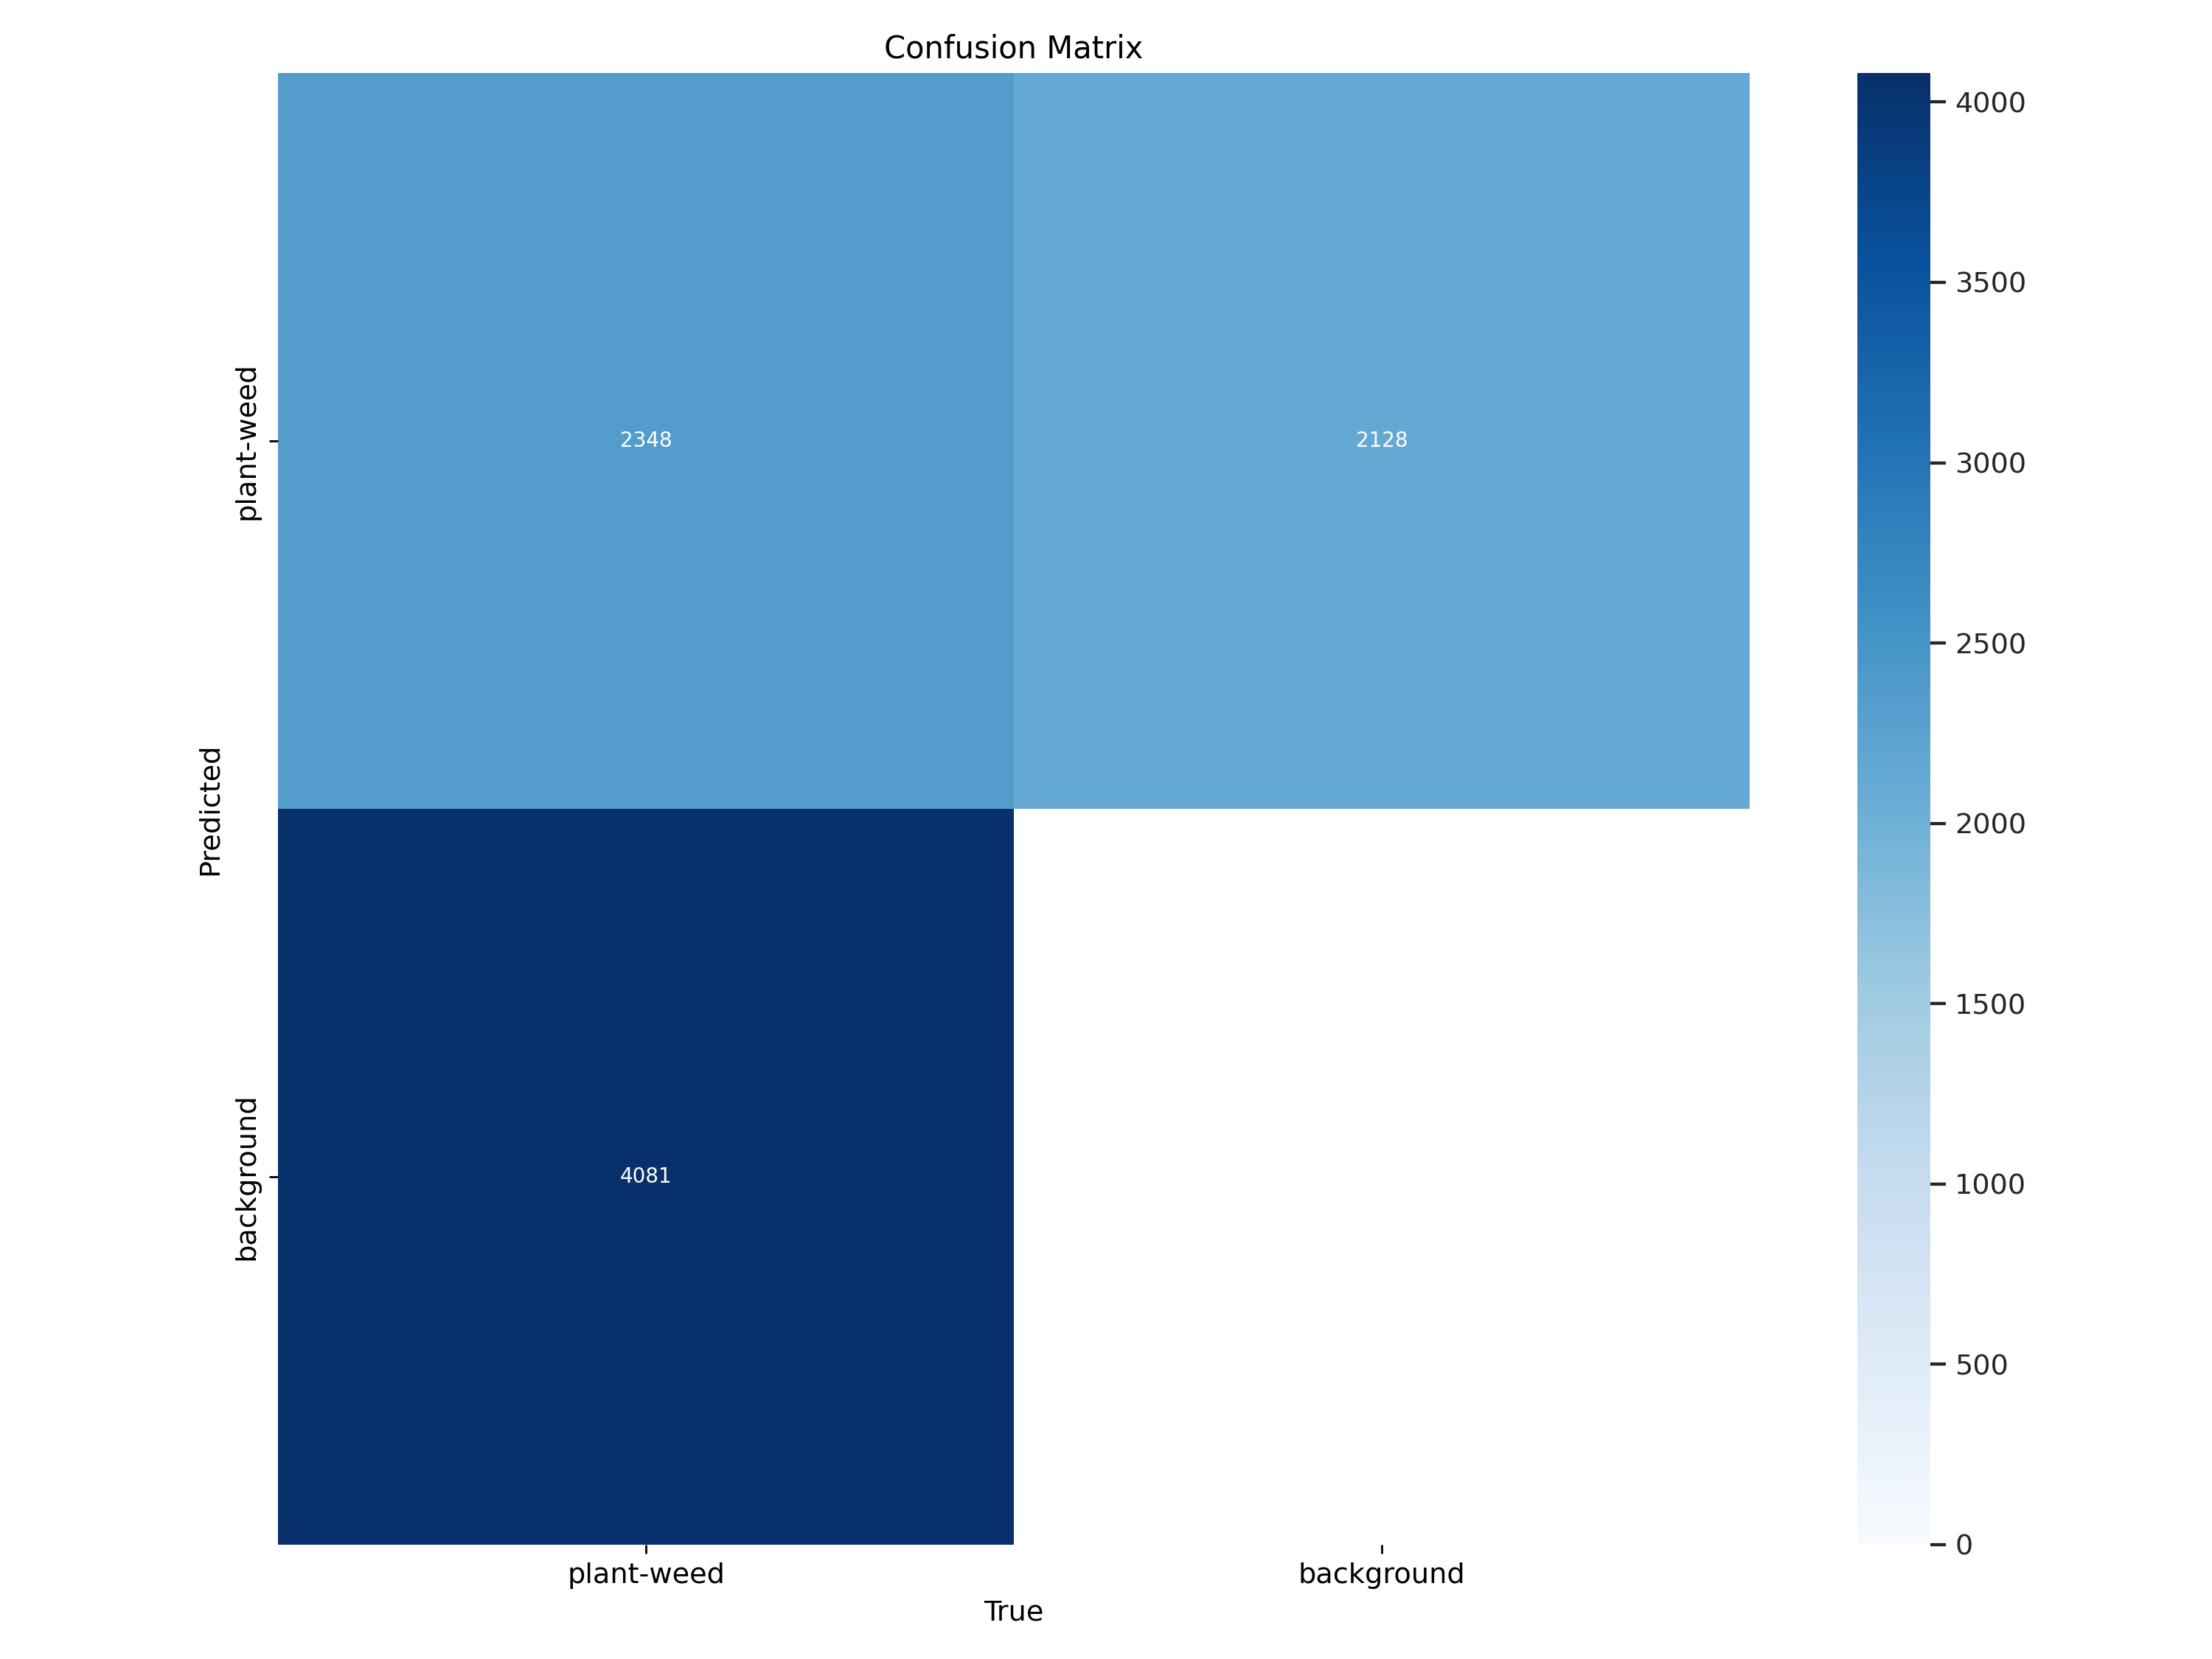

In [319]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

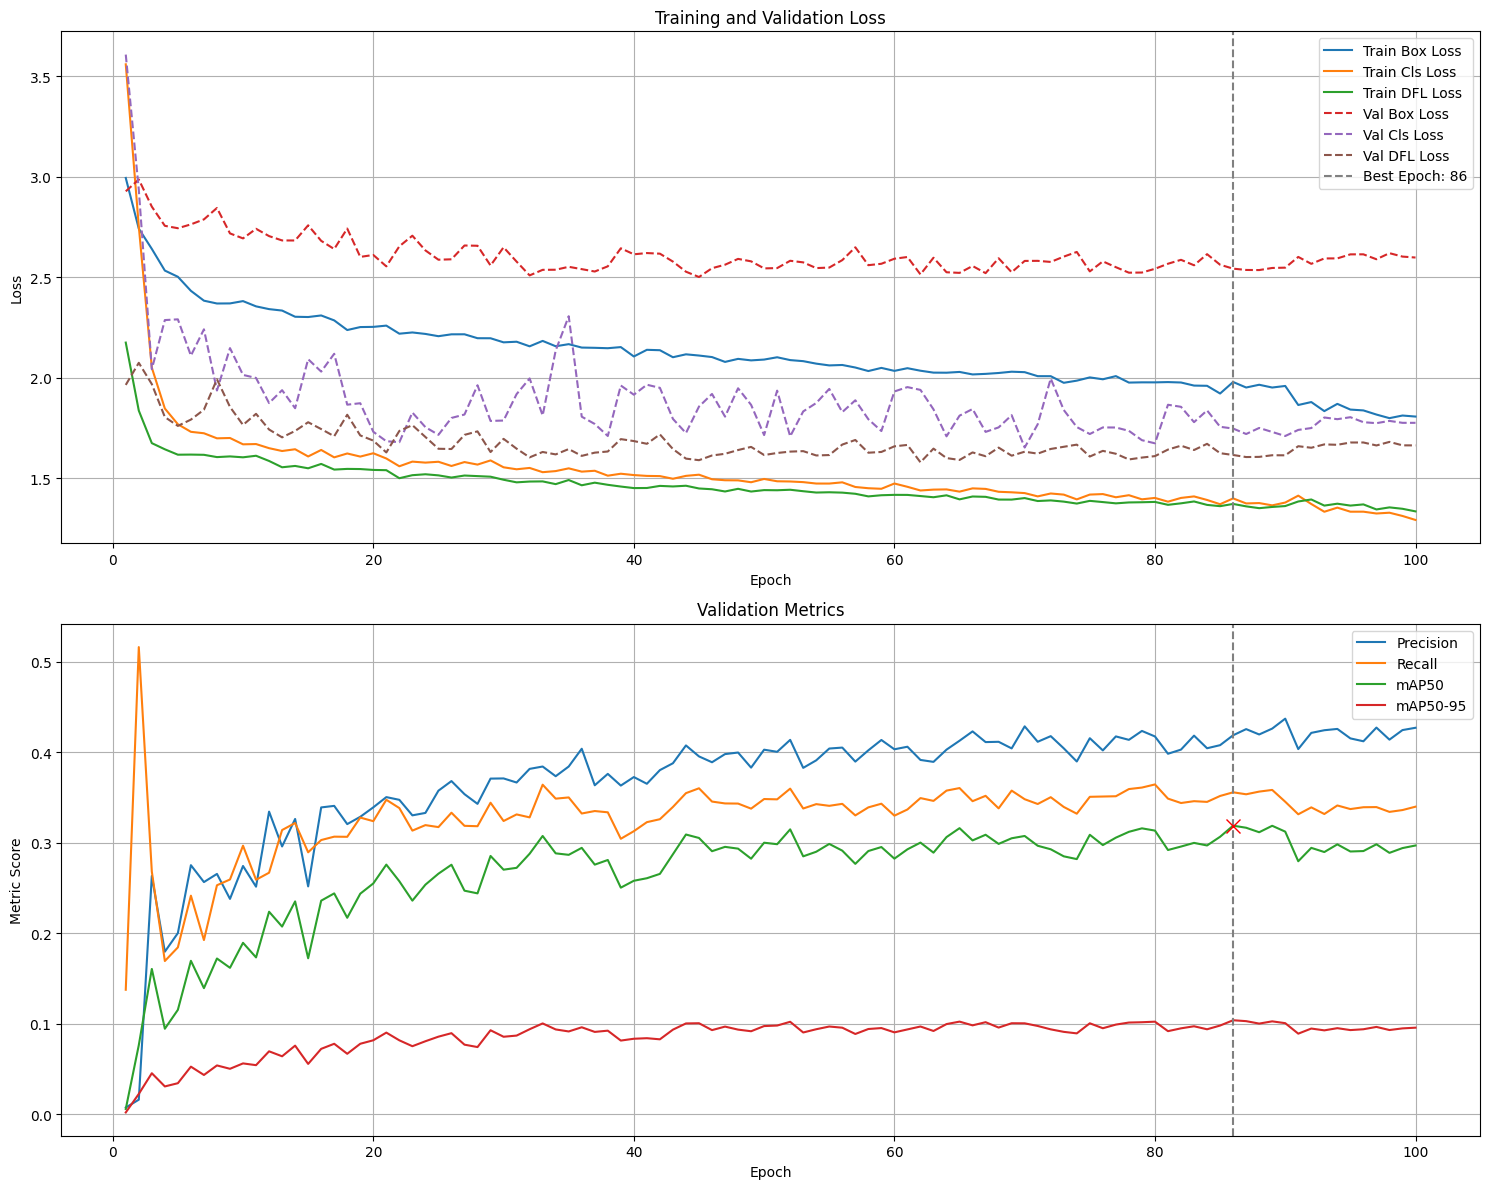

In [320]:
graph_training_metrics(df1, epoch, graph="full")

In [321]:
graph_LrLoss_3D(df1)

Validation set


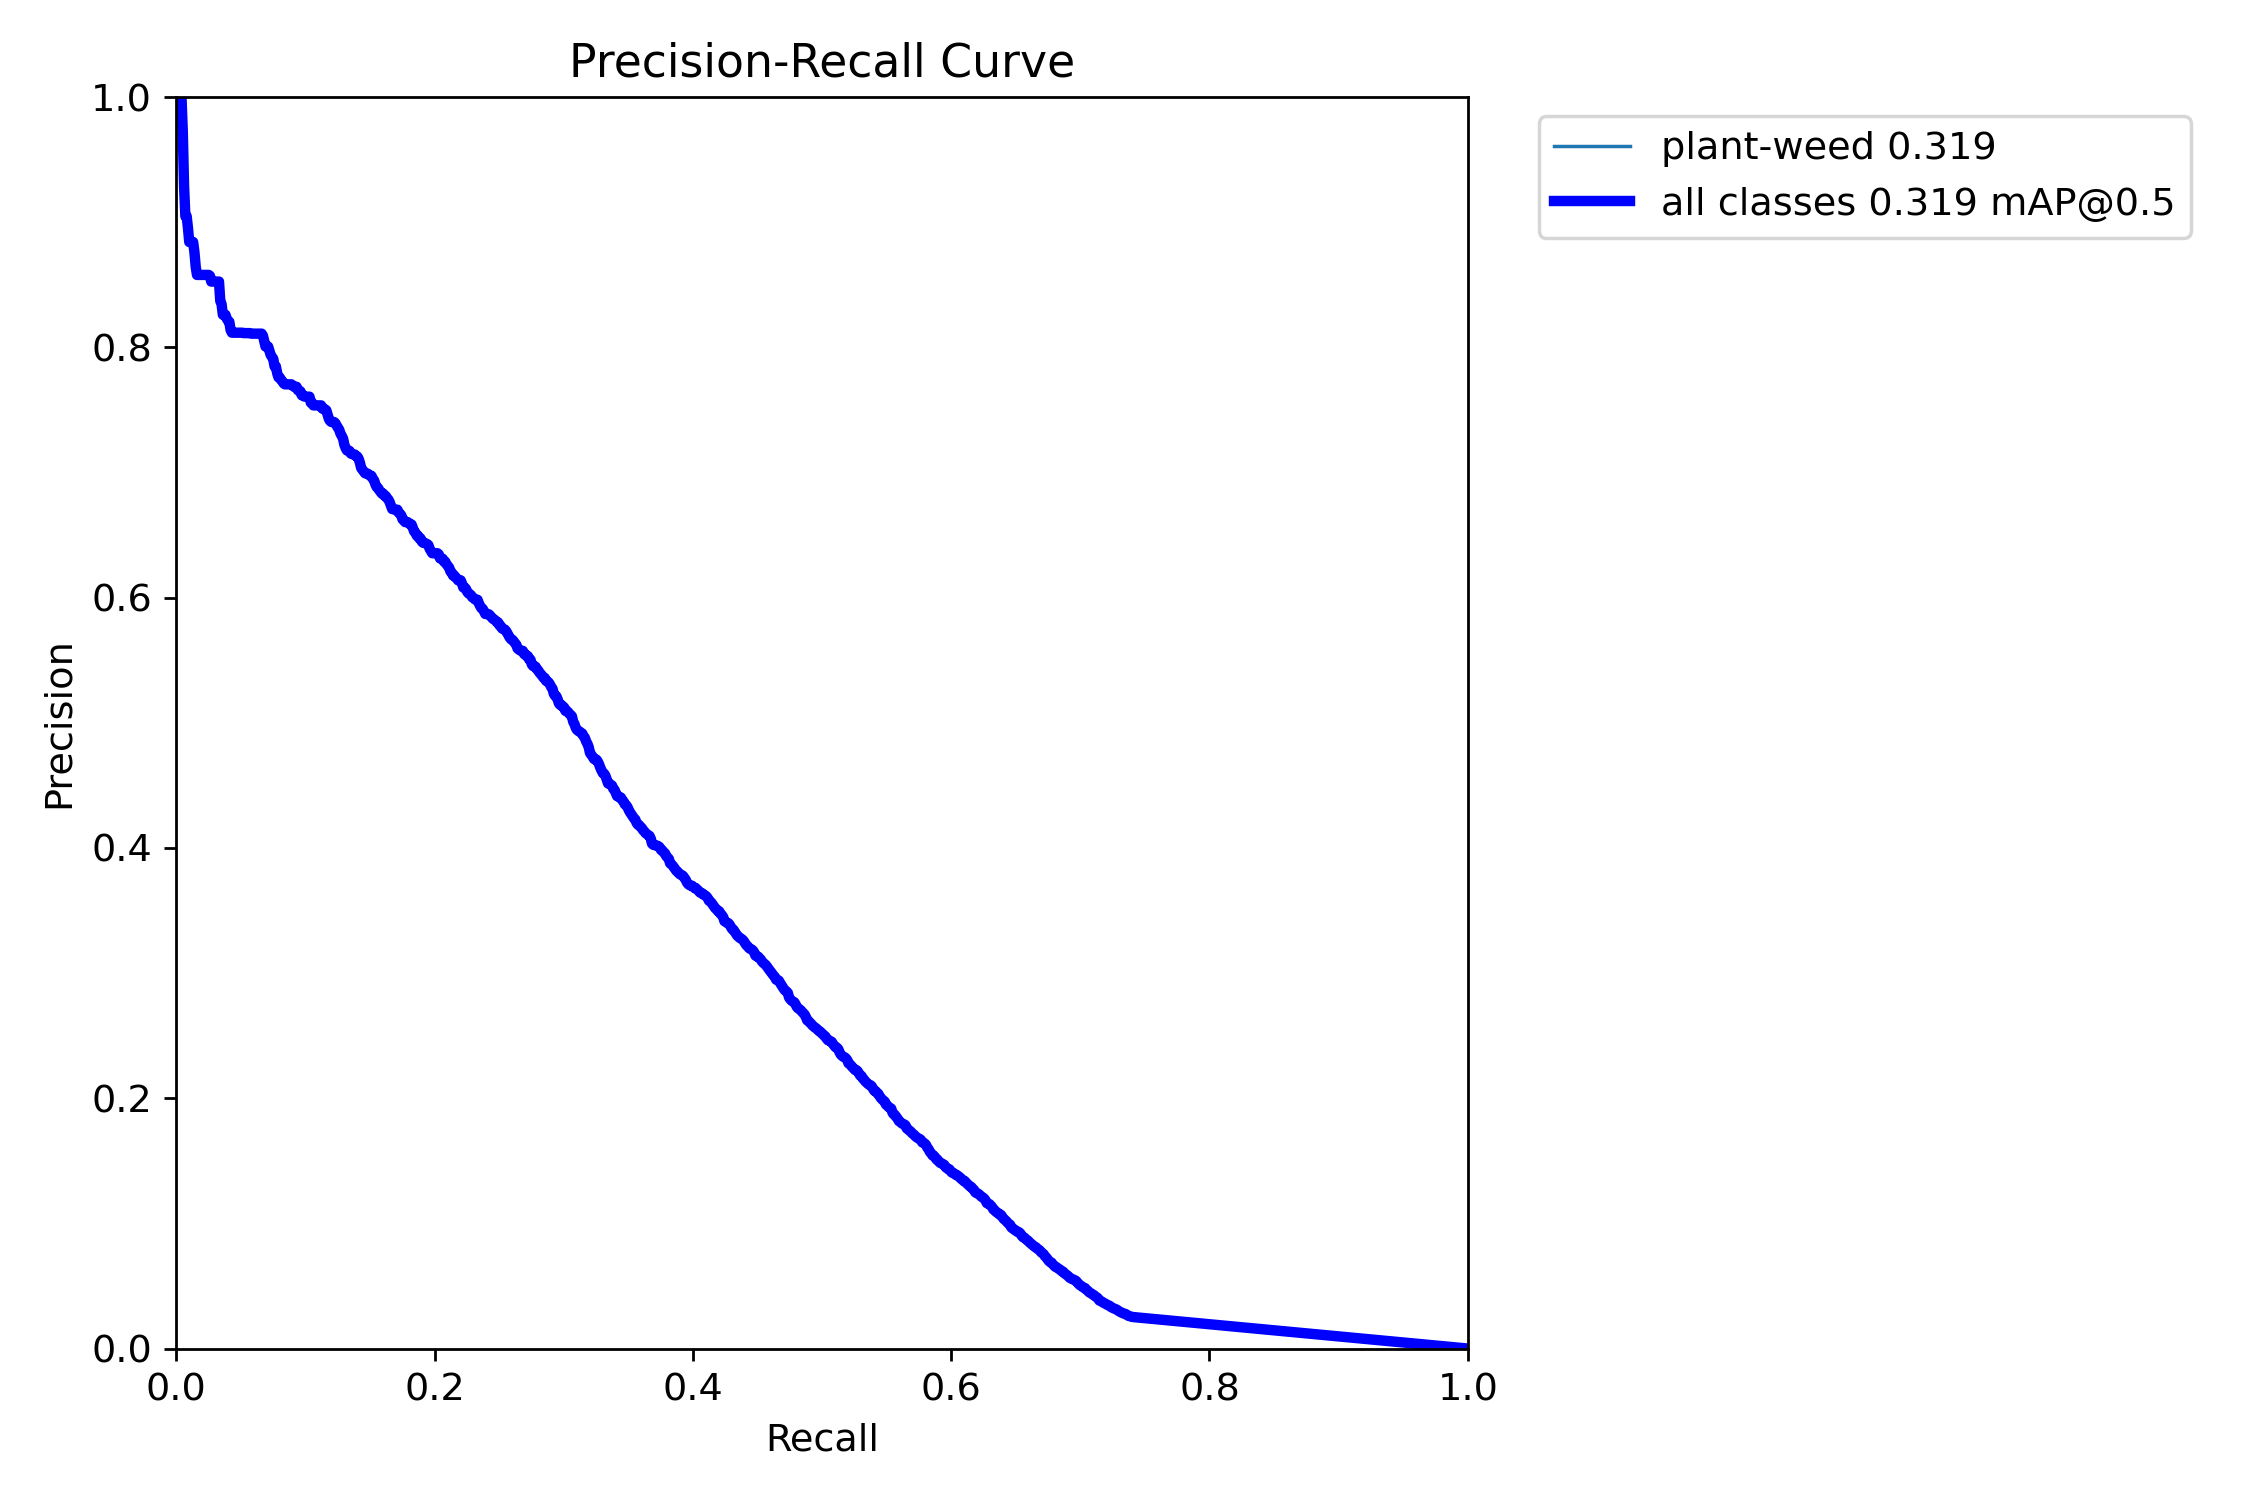

In [322]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

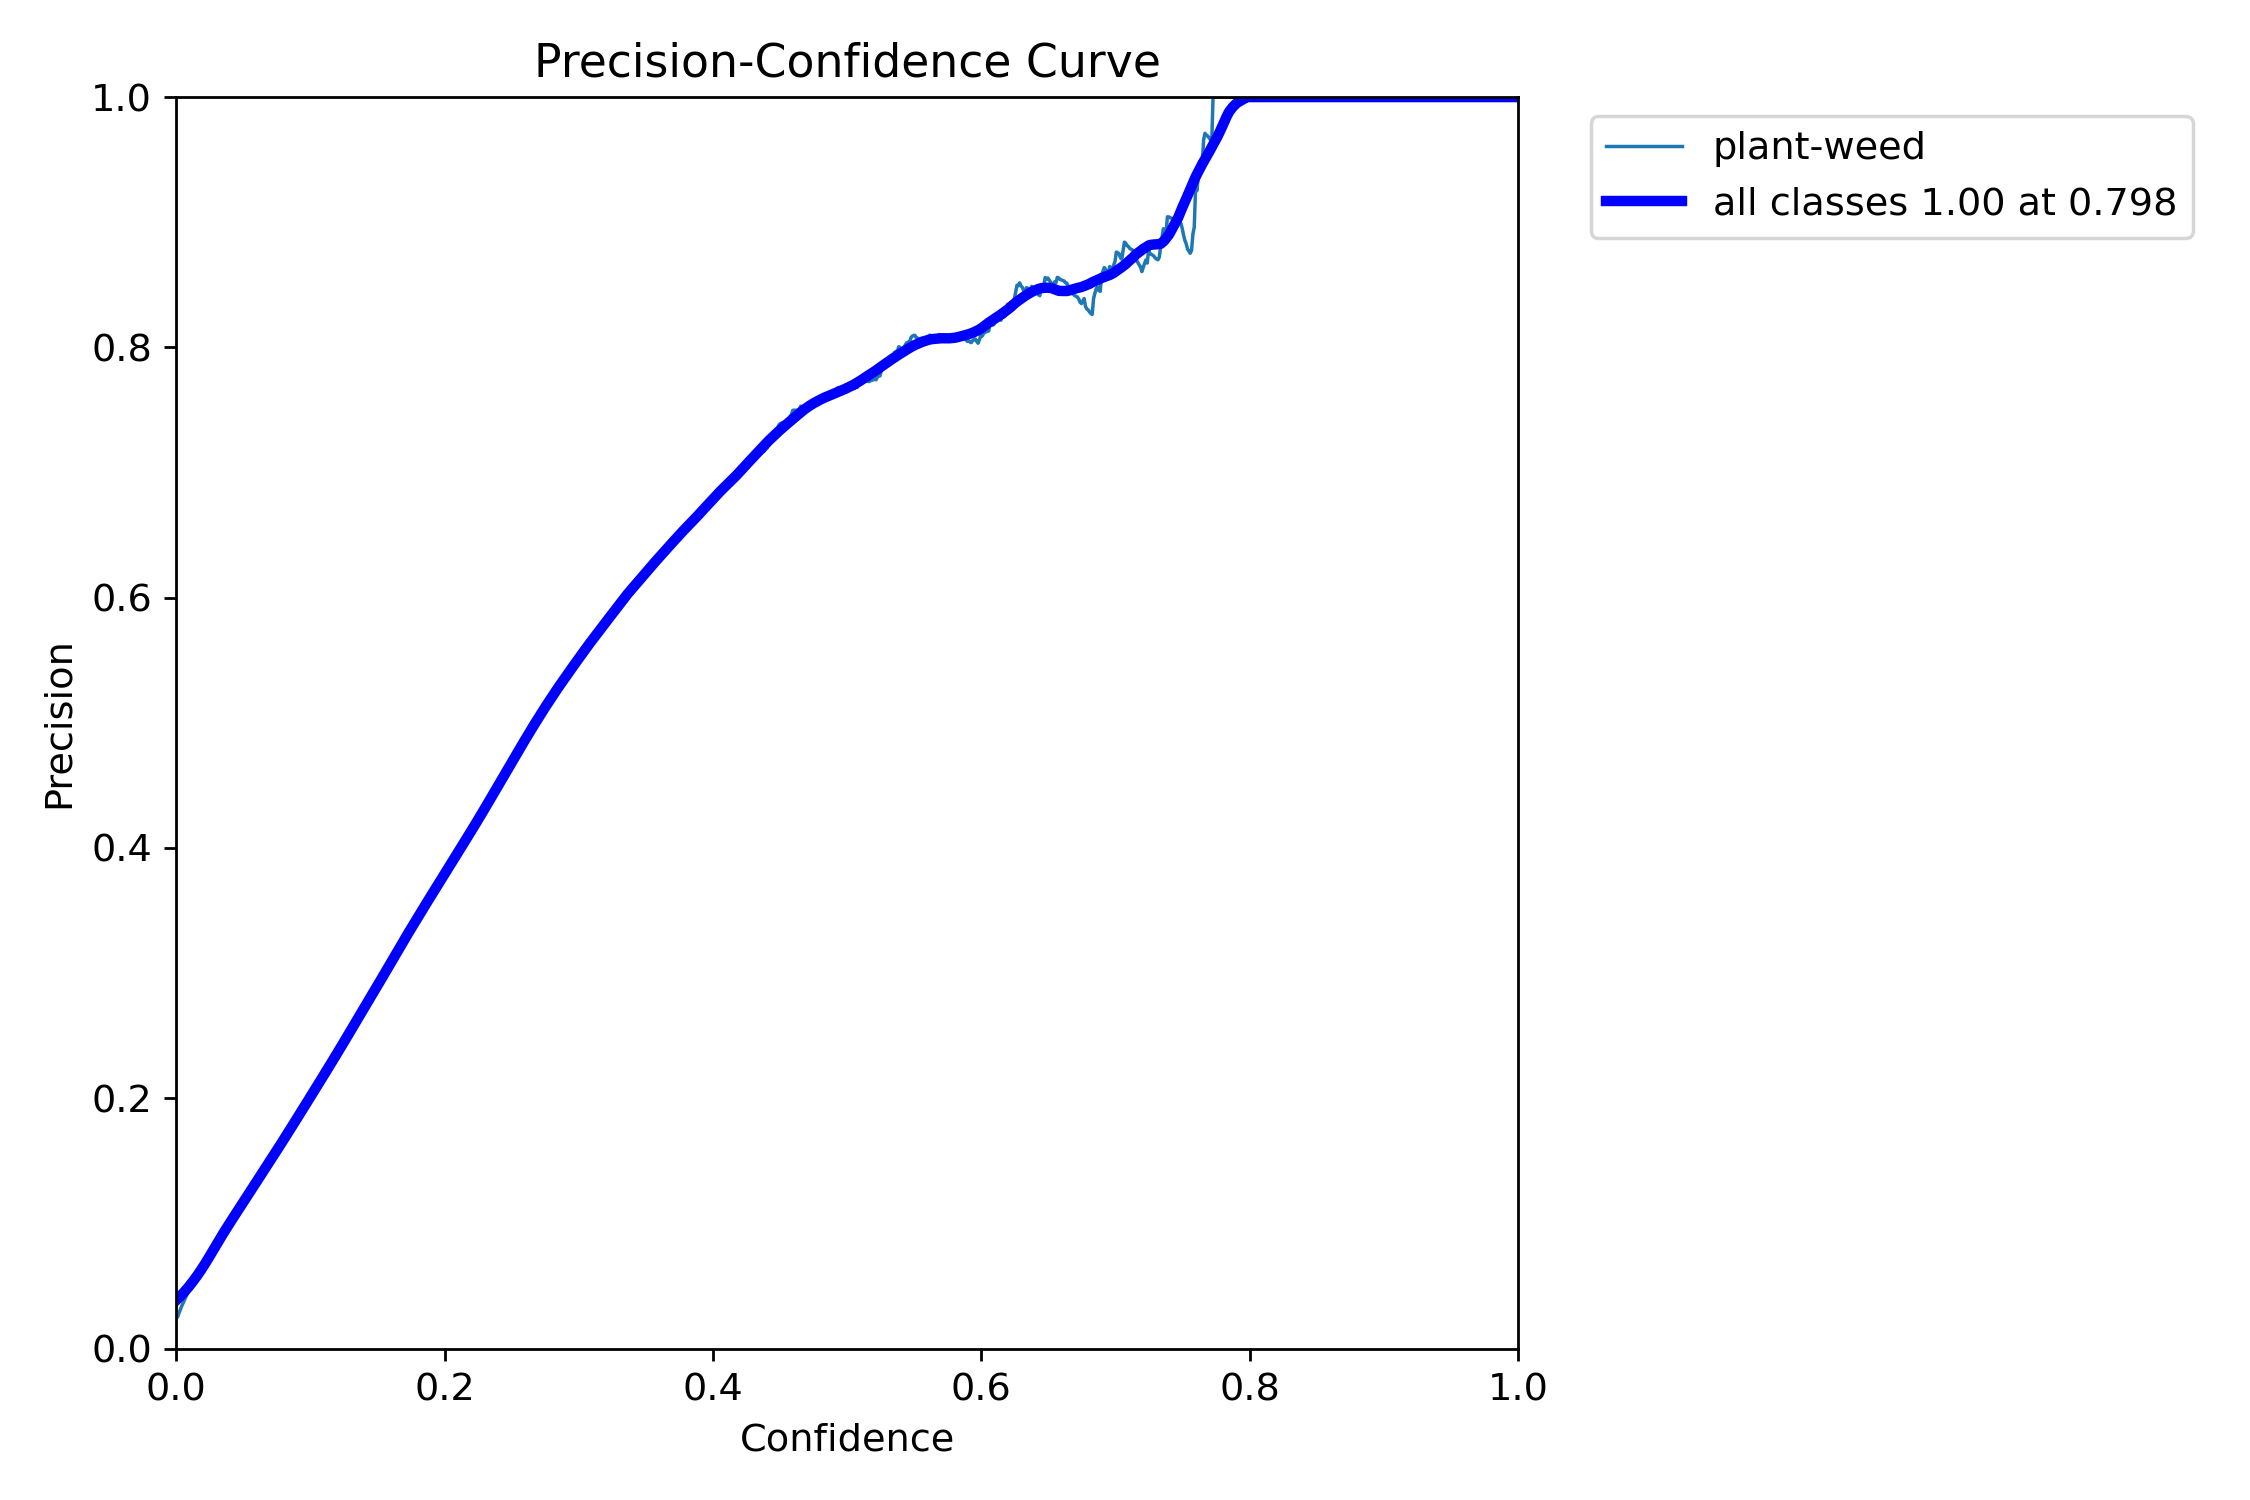

In [323]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

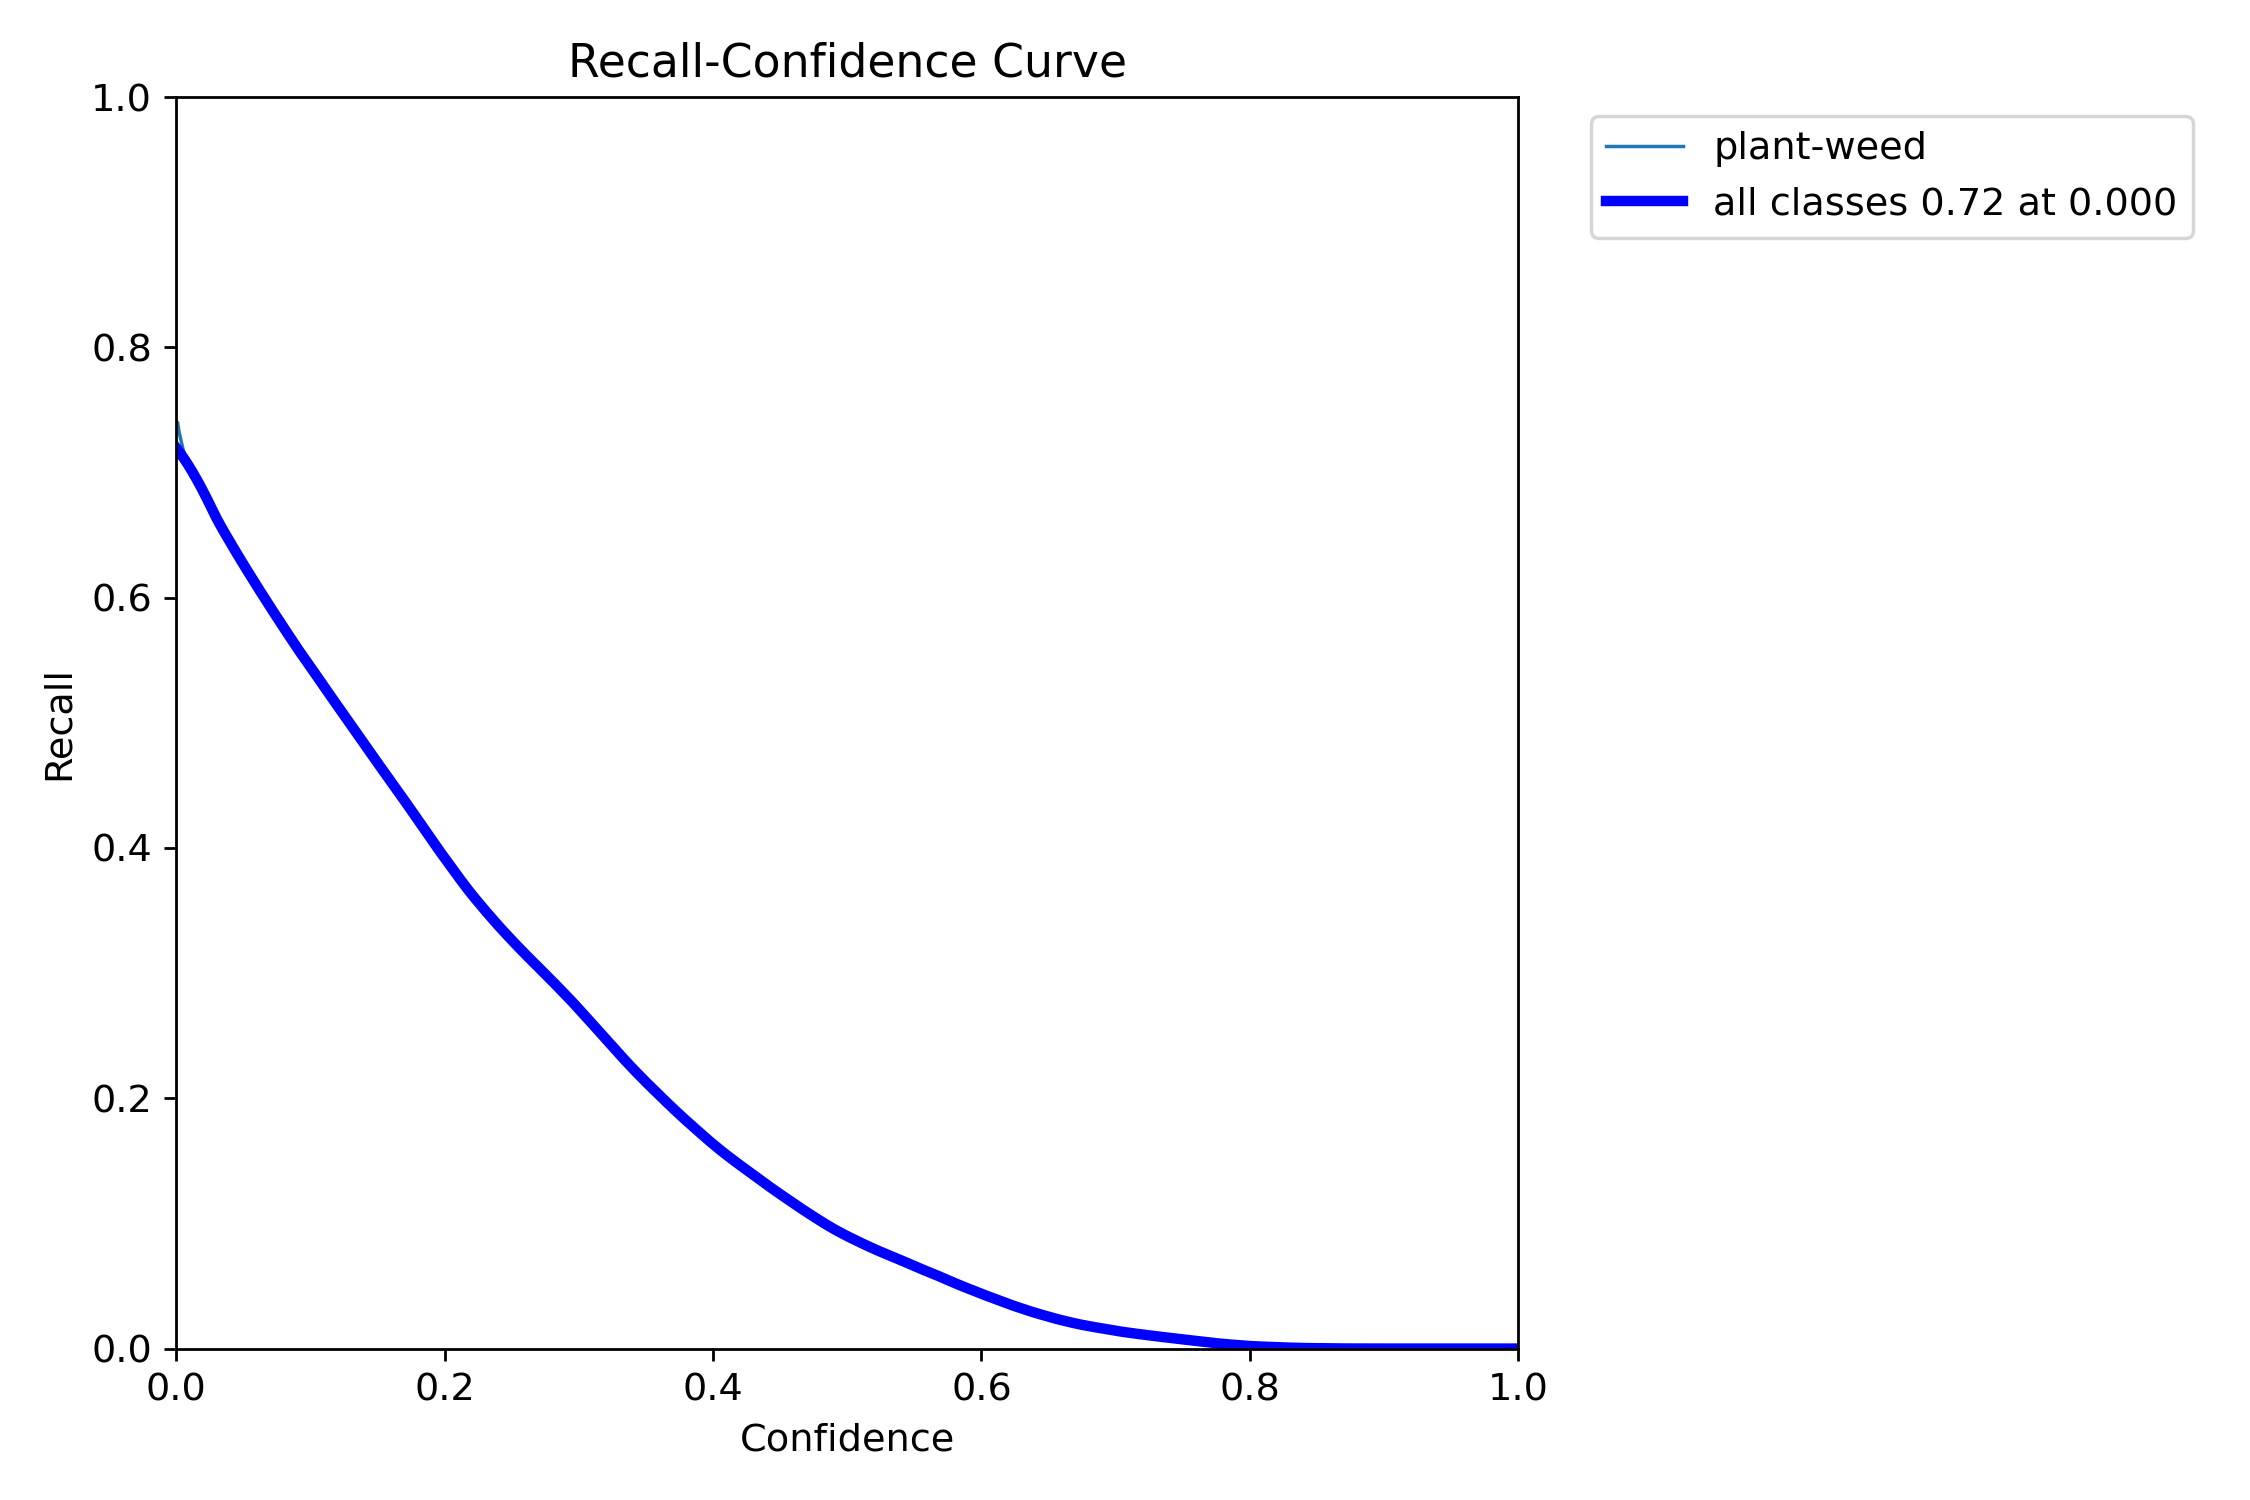

In [324]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

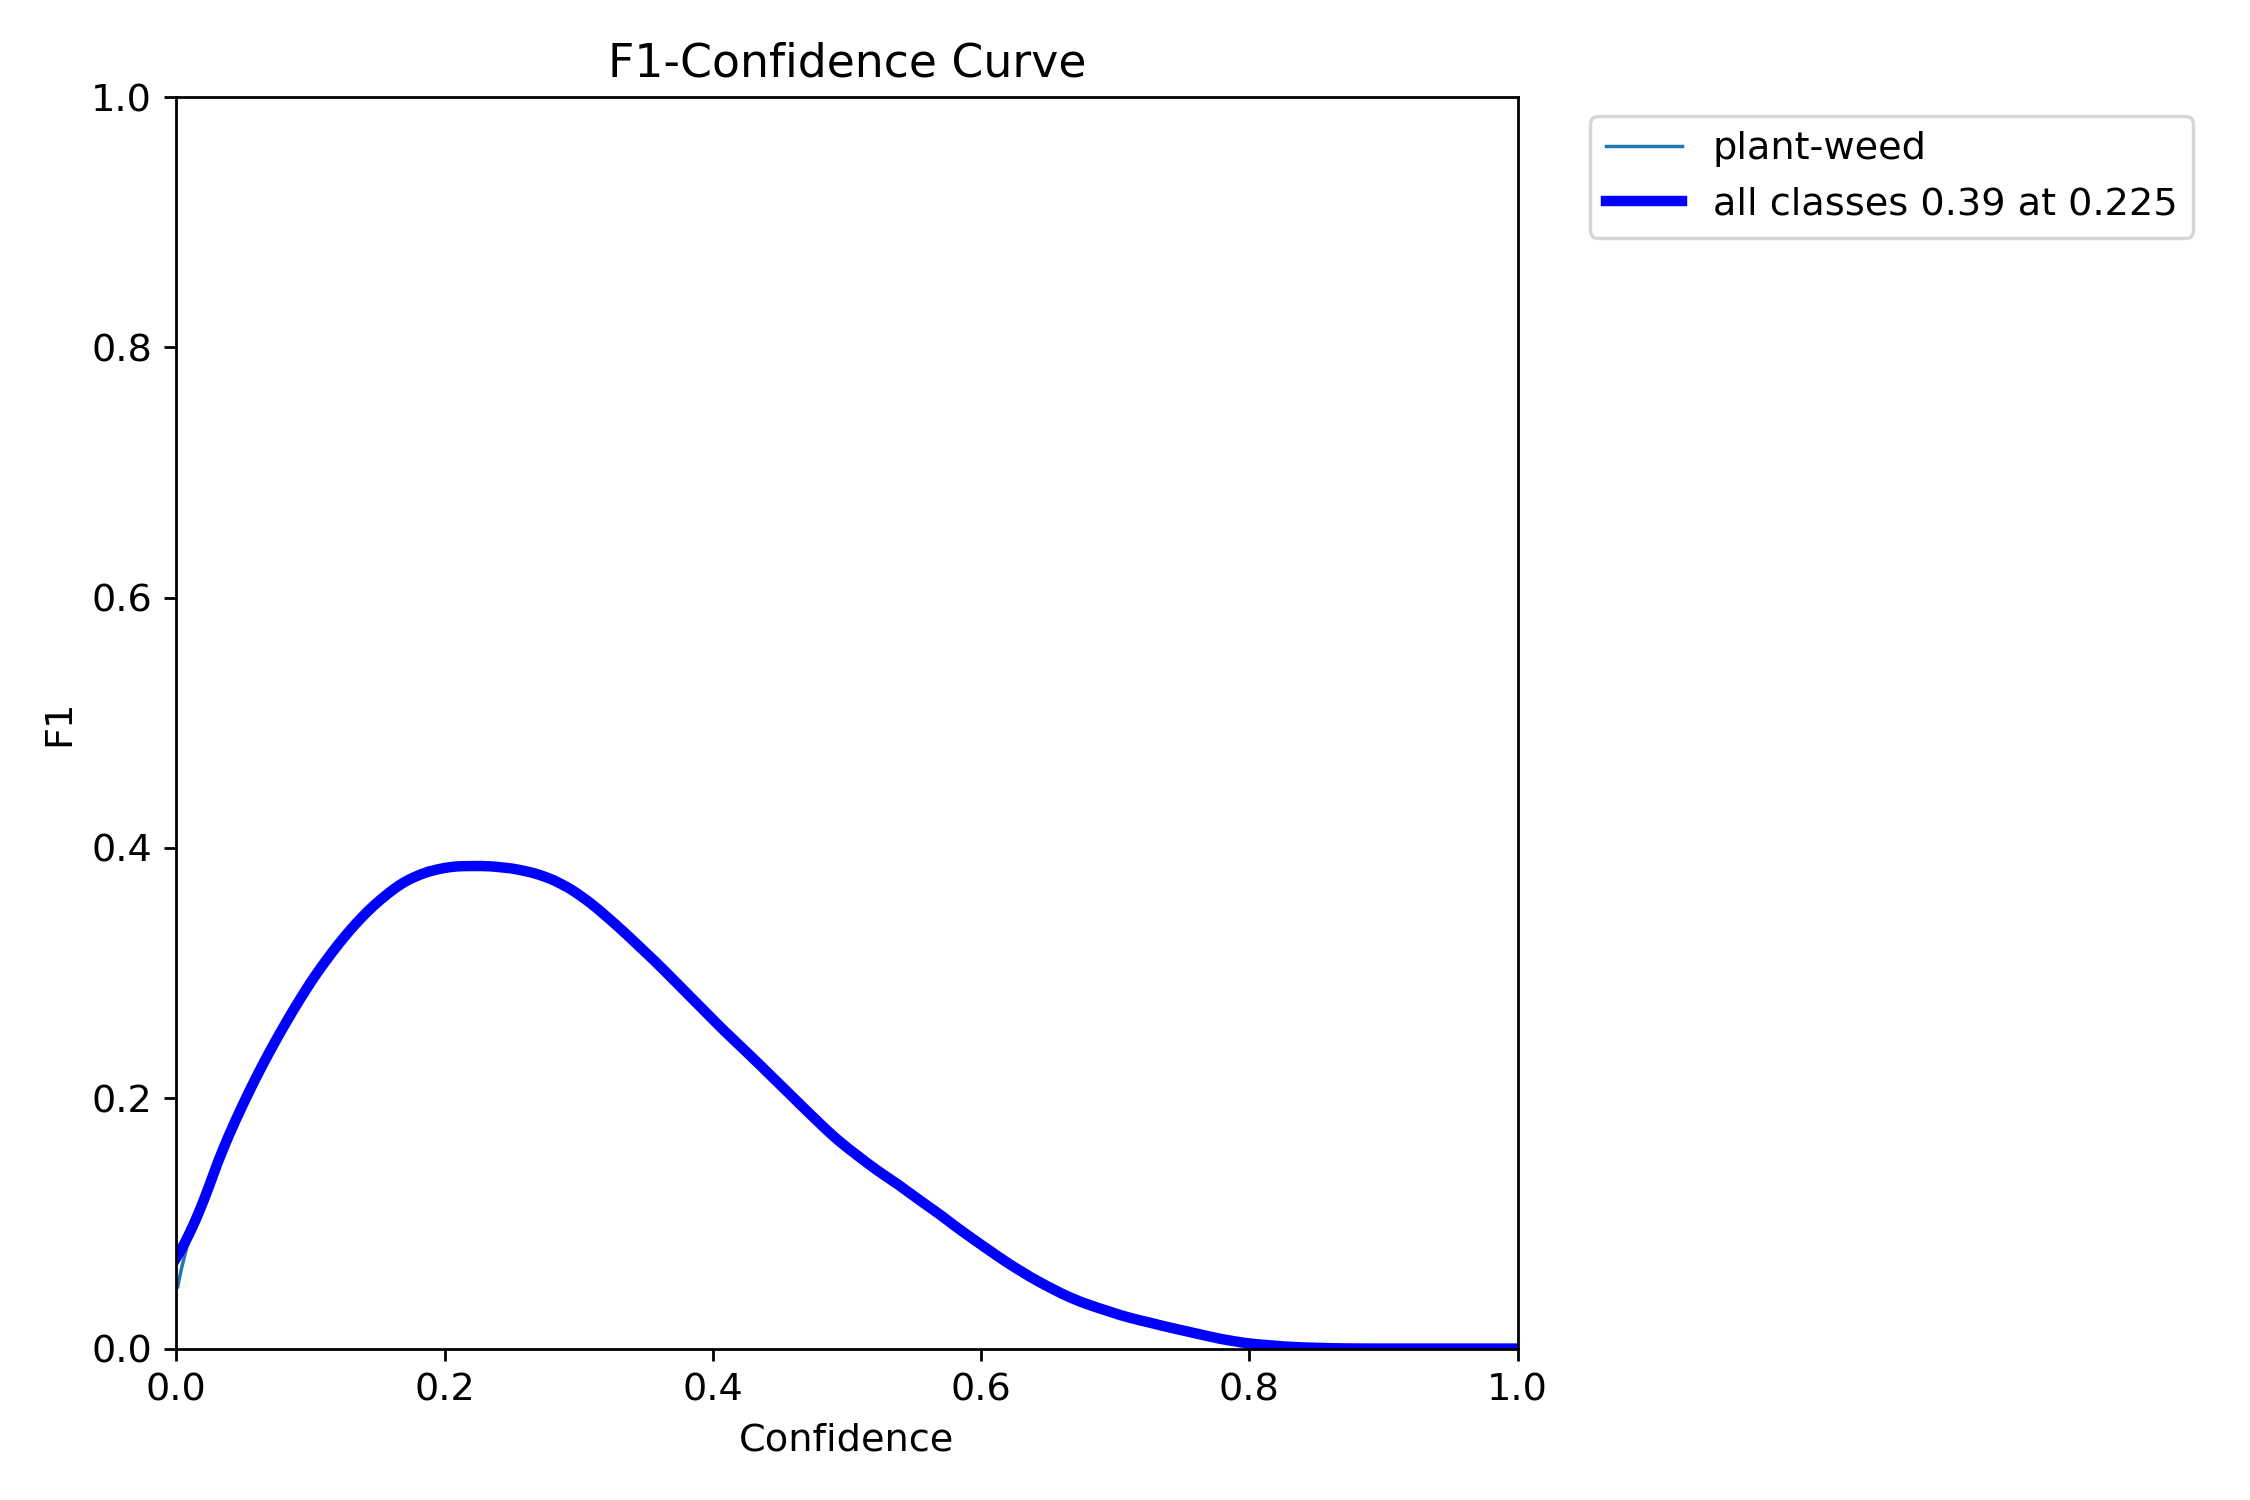

In [325]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

### Conclusiones

1. **Pérdidas de entrenamiento y validación (Losses)**

- Se observa una tendencia decreciente en las pérdidas de entrenamiento y validación, aunque siguen siendo relativamente altas.
- La diferencia entre la pérdida de entrenamiento y validación no parece excesiva, lo que sugiere que el modelo no está sobreajustando de manera significativa.
- La pérdida de distribución focal (DFL loss) también disminuye, pero sigue presente en ambas fases (entrenamiento y validación).
- No hay signos de sobreajuste obvios, pero la diferencia entre las pérdidas de entrenamiento y validación indica que el modelo aún no está bien ajustado (_underfitting_).

2. **Métricas de validación (Precisión, Recall, mAP)**

- La precisión es baja en general y no muestra una mejora significativa con las épocas.
- La precisión y el recall fluctúan, pero el recall es relativamente alto en comparación con la precisión, lo que indica que el modelo detecta muchos objetos, aunque con bastantes falsos positivos.
- El mAP@0.5 (Media de precisión a IoU 0.5) muestra mejoras iniciales pero se estabiliza en un nivel bajo (~0.16).
- El mAP@0.5-0.95, que mide precisión en diferentes umbrales de IoU, es aún menor (~0.04), lo que sugiere que el modelo tiene dificultades con detecciones precisas.

3. **Evolución de la Tasa de Aprendizaje (Learning Rate, LR)** 

- Se observa un crecimiento progresivo, lo que sugiere que se está usando una estrategia de warm-up antes de estabilizarse o reducirse.
- El learning rate sigue una tendencia creciente en las primeras épocas.
- Puede que un LR alto esté dificultando la convergencia y generando fluctuaciones en las métricas.

----

## Experiment 5 *(small weed)*
### *3m | 60º | small*

In [326]:
folder = "train2/"

In [327]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df2 = pd.read_csv(file_path)
df = df2.copy()
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
95,96,360.341,1.76656,1.27556,1.33661,0.33850,0.30638,0.21604,0.05936,2.78132,2.04146,1.62064,0.000119,0.000119,0.000119
96,97,363.470,1.74257,1.24931,1.31357,0.33448,0.29607,0.21000,0.05658,2.80701,2.04054,1.63403,0.000099,0.000099,0.000099
97,98,366.616,1.78616,1.25406,1.32971,0.33708,0.30901,0.21508,0.05900,2.78923,2.03379,1.61732,0.000079,0.000079,0.000079
98,99,369.700,1.80088,1.26535,1.32537,0.34492,0.31225,0.21911,0.06076,2.77873,2.03002,1.60795,0.000060,0.000060,0.000060
99,100,374.147,1.75346,1.23725,1.31018,0.34166,0.30966,0.21831,0.06050,2.77632,2.03878,1.60498,0.000040,0.000040,0.000040


***NOTE:***
- `lr/pg0` typically refers to the learning rate for the backbone weights.
- `lr/pg1` is usually associated with the learning rate for the YOLO layers' weights.
- `lr/pg2` often represents the learning rate for any additional parameters, such as biases.

In [328]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 6.236 min


#### Best epoch

In [329]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
67,68,256.94,1.92384,1.35116,1.34173,0.3798,0.33399,0.26369,0.07458,2.66382,1.97159,1.51733,0.000673,0.000673,0.000673,6.235783


In [330]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Mejor época de entrenamiento 68 con mAP50 de 0.264


In [331]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [332]:
TP = 503
FP = 561
FN = 1018
base = TP+FP+FN
print("Total de objetos detectados:", base)

Total de objetos detectados: 2082


In [333]:
# Cálculo de porcentajes
TP/base, FP/base, FN/base

(0.24159462055715658, 0.26945244956772335, 0.48895292987512007)

### Graphs

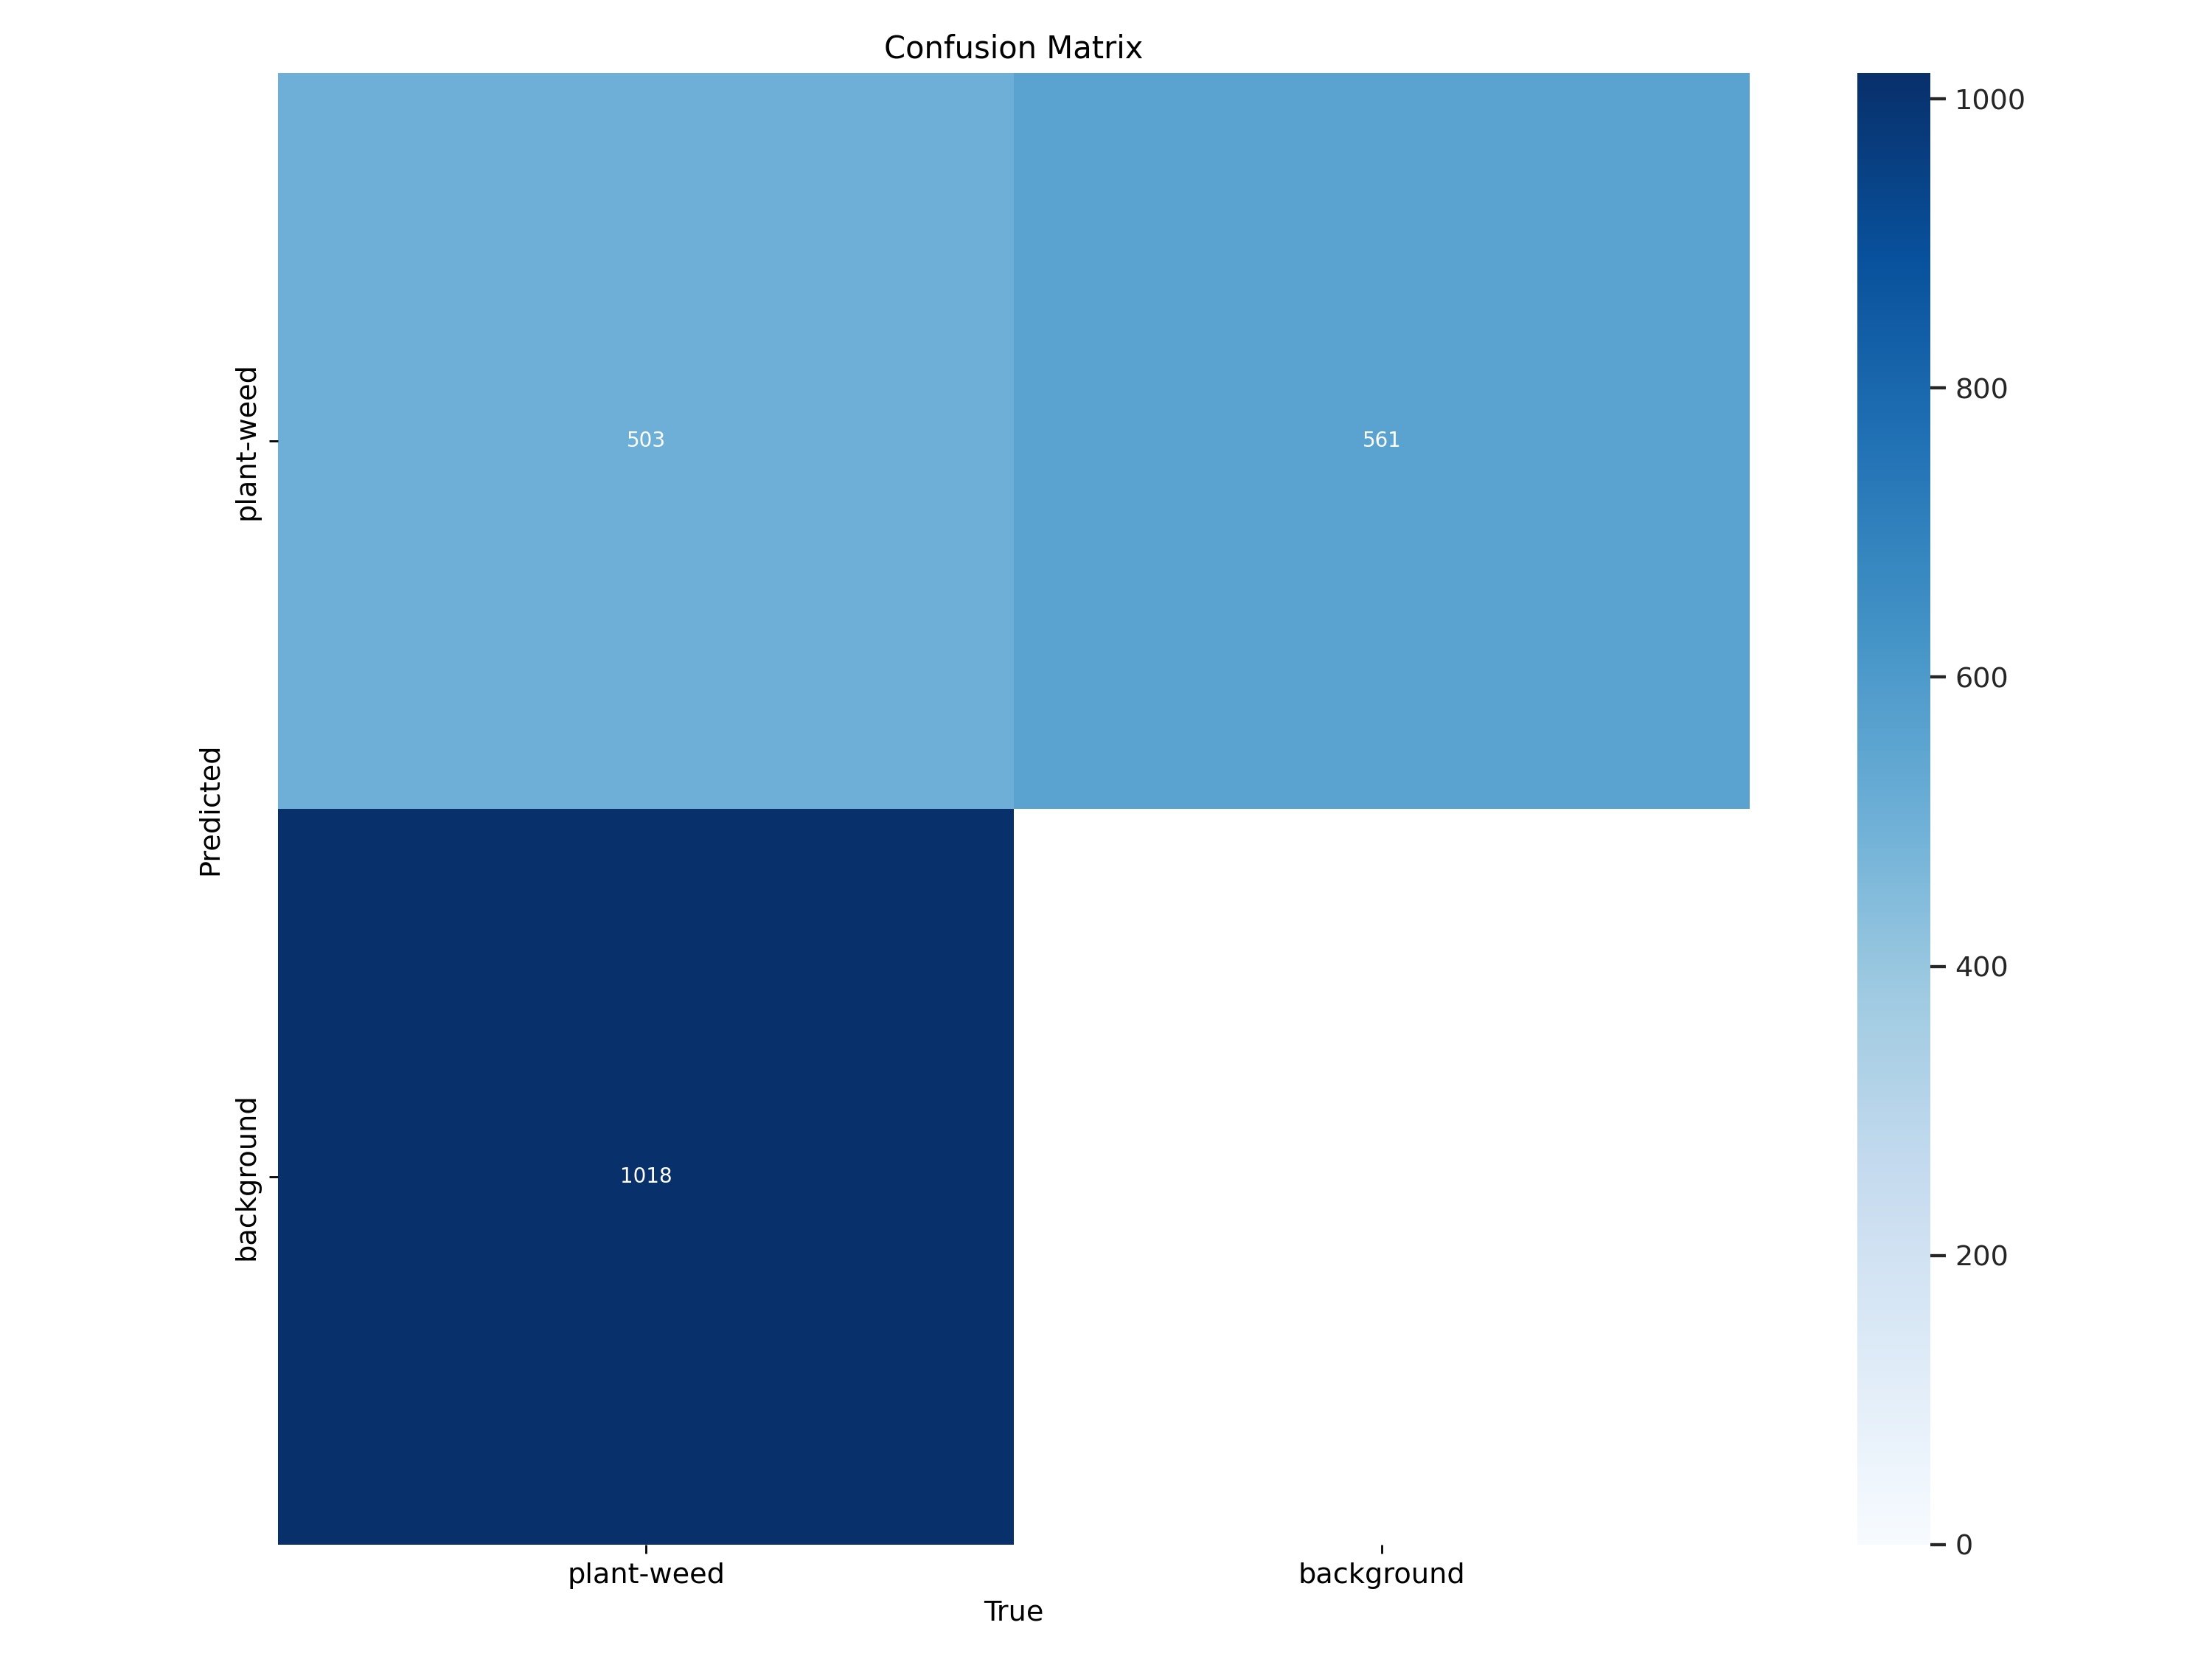

In [334]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

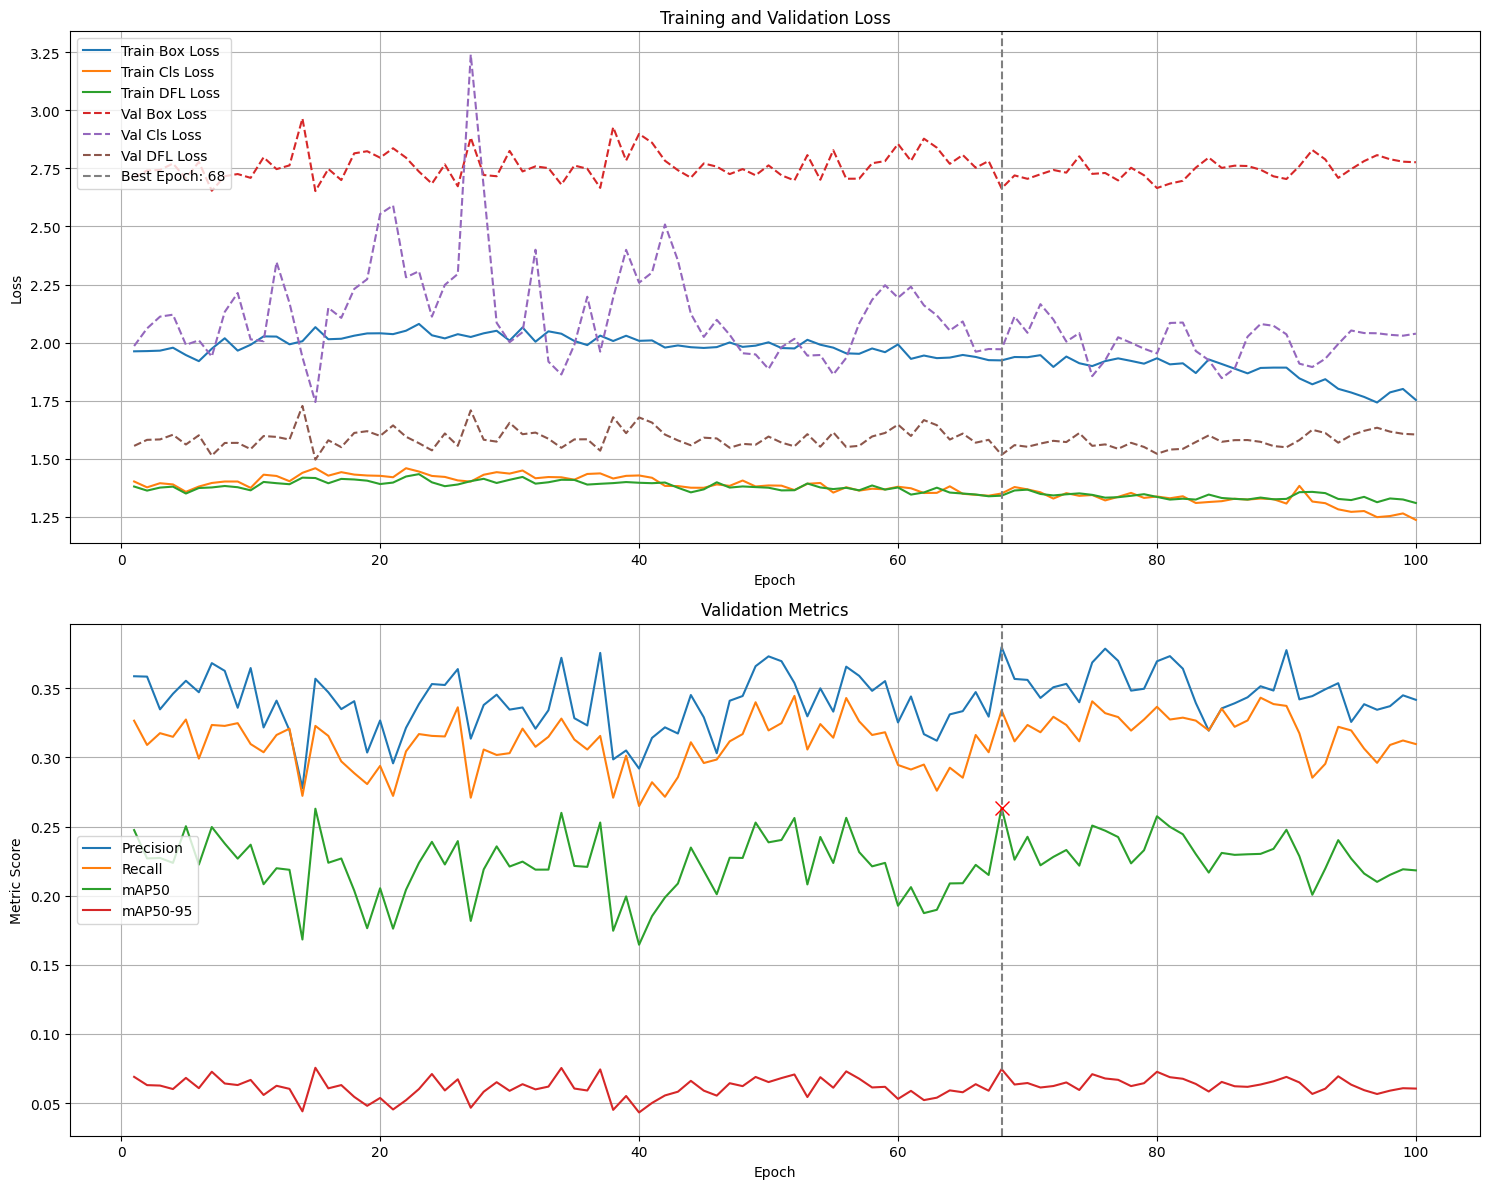

In [335]:
graph_training_metrics(df2, epoch, graph="full")

In [336]:
graph_LrLoss_3D(df2)

Validation set


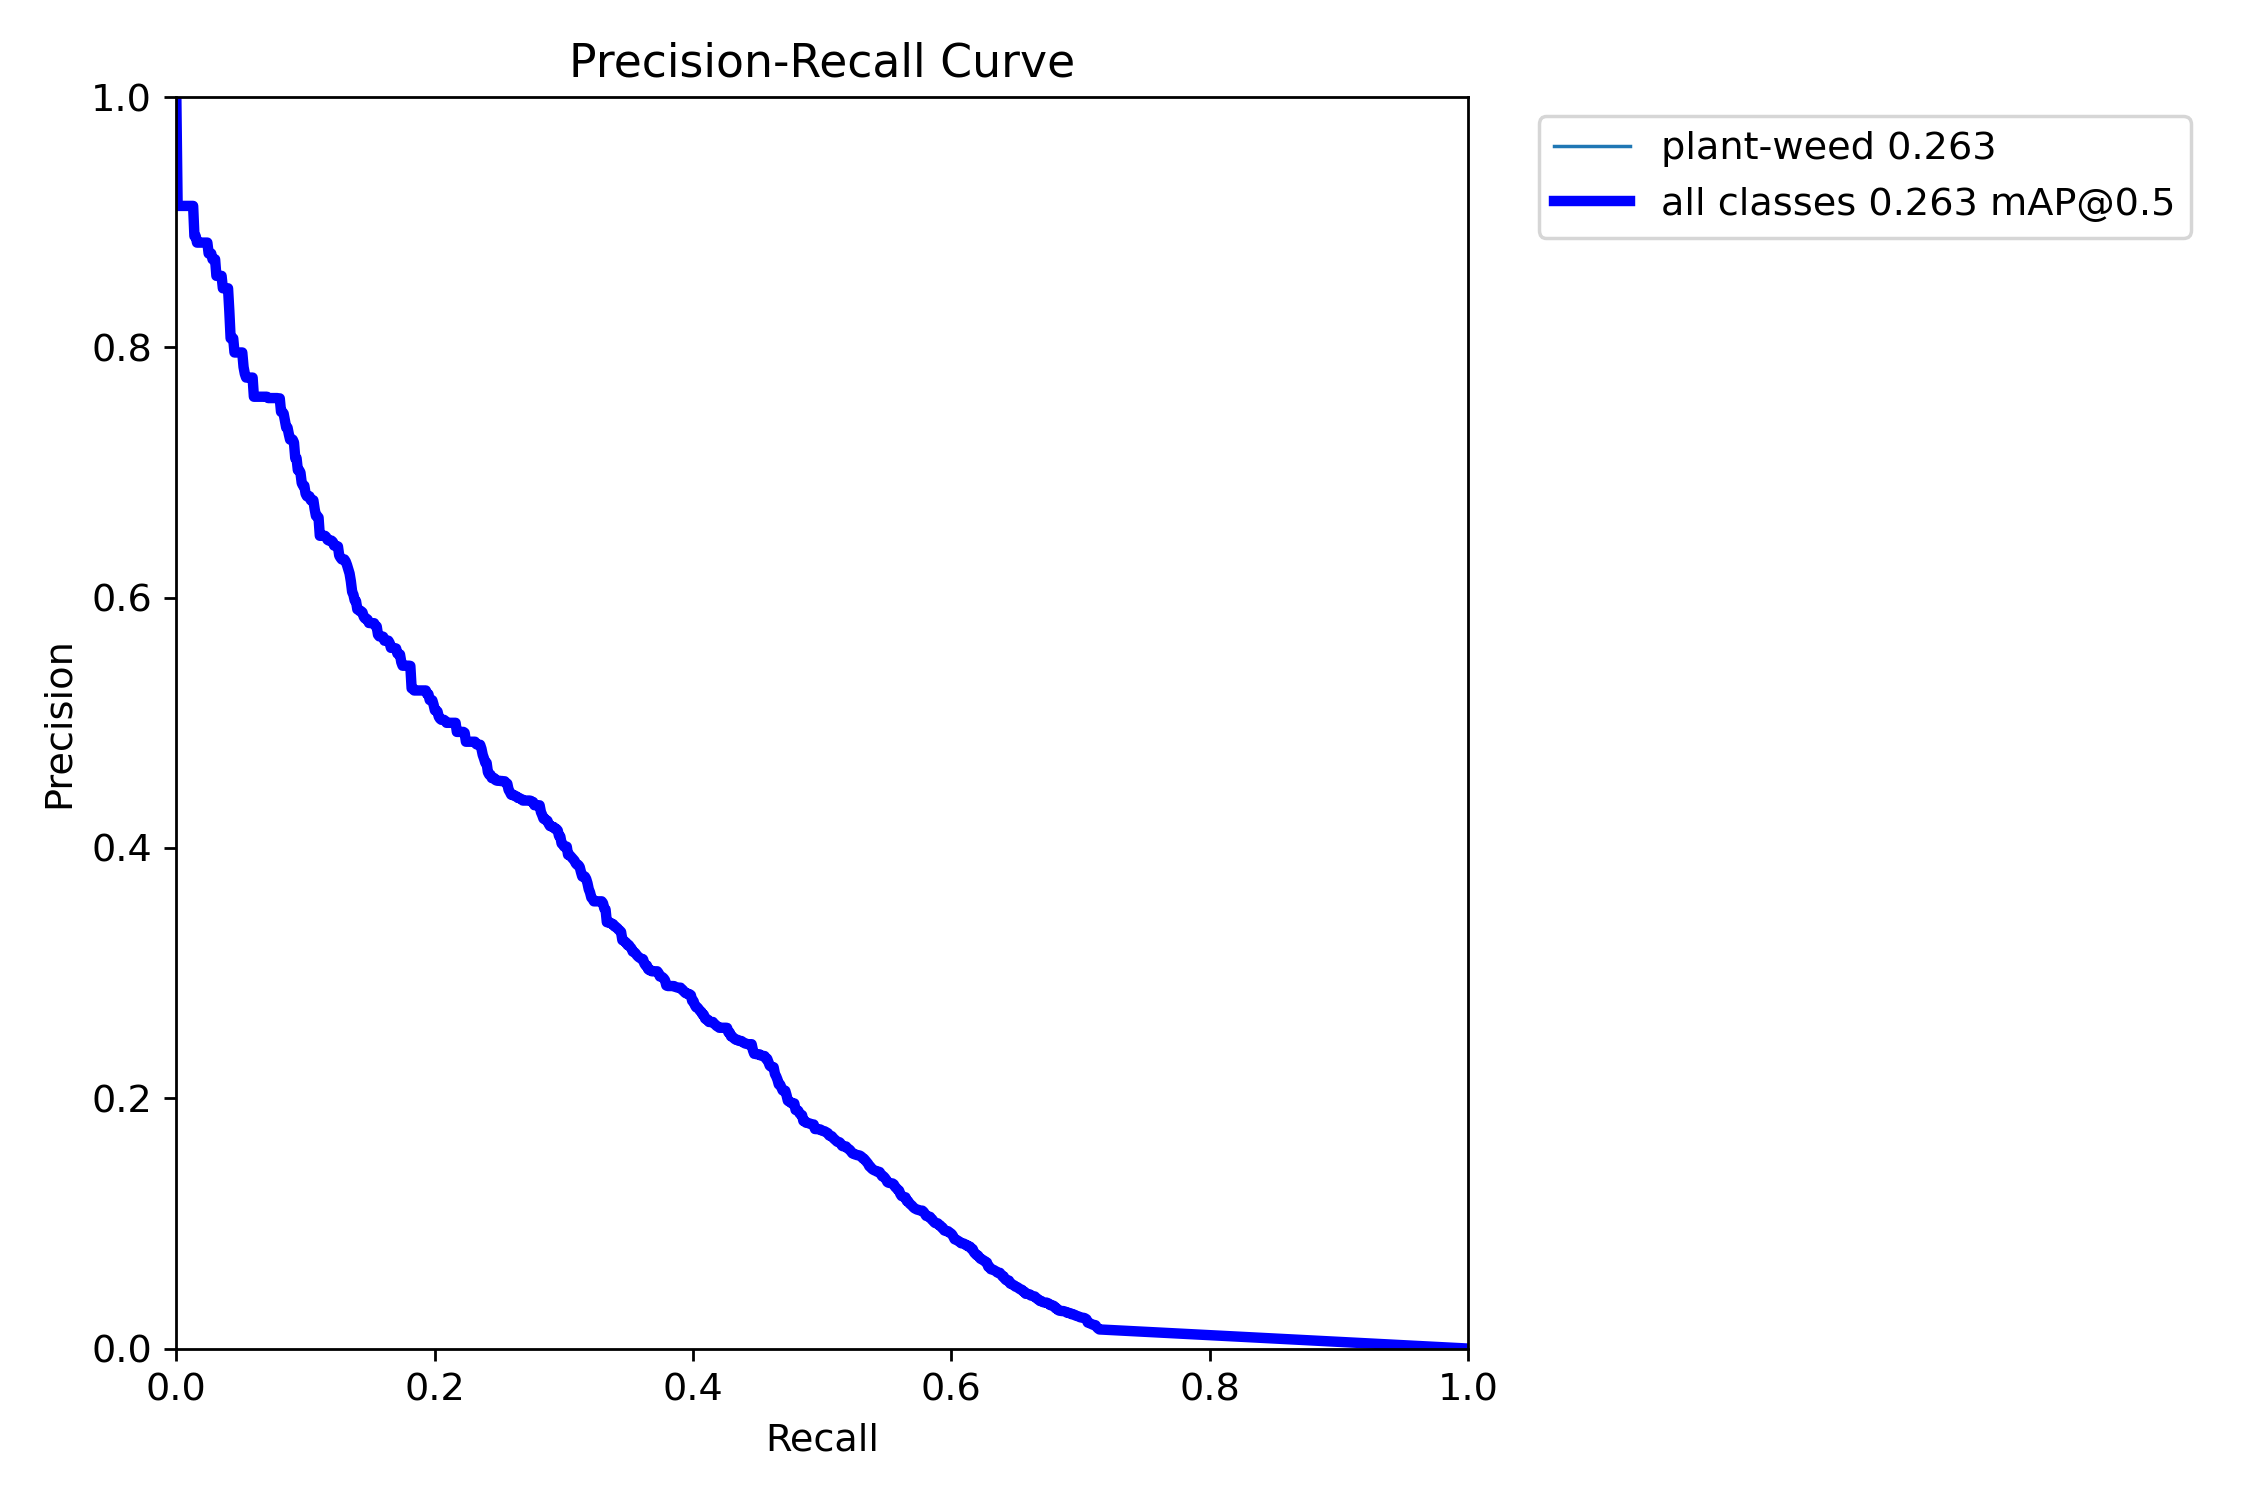

In [337]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

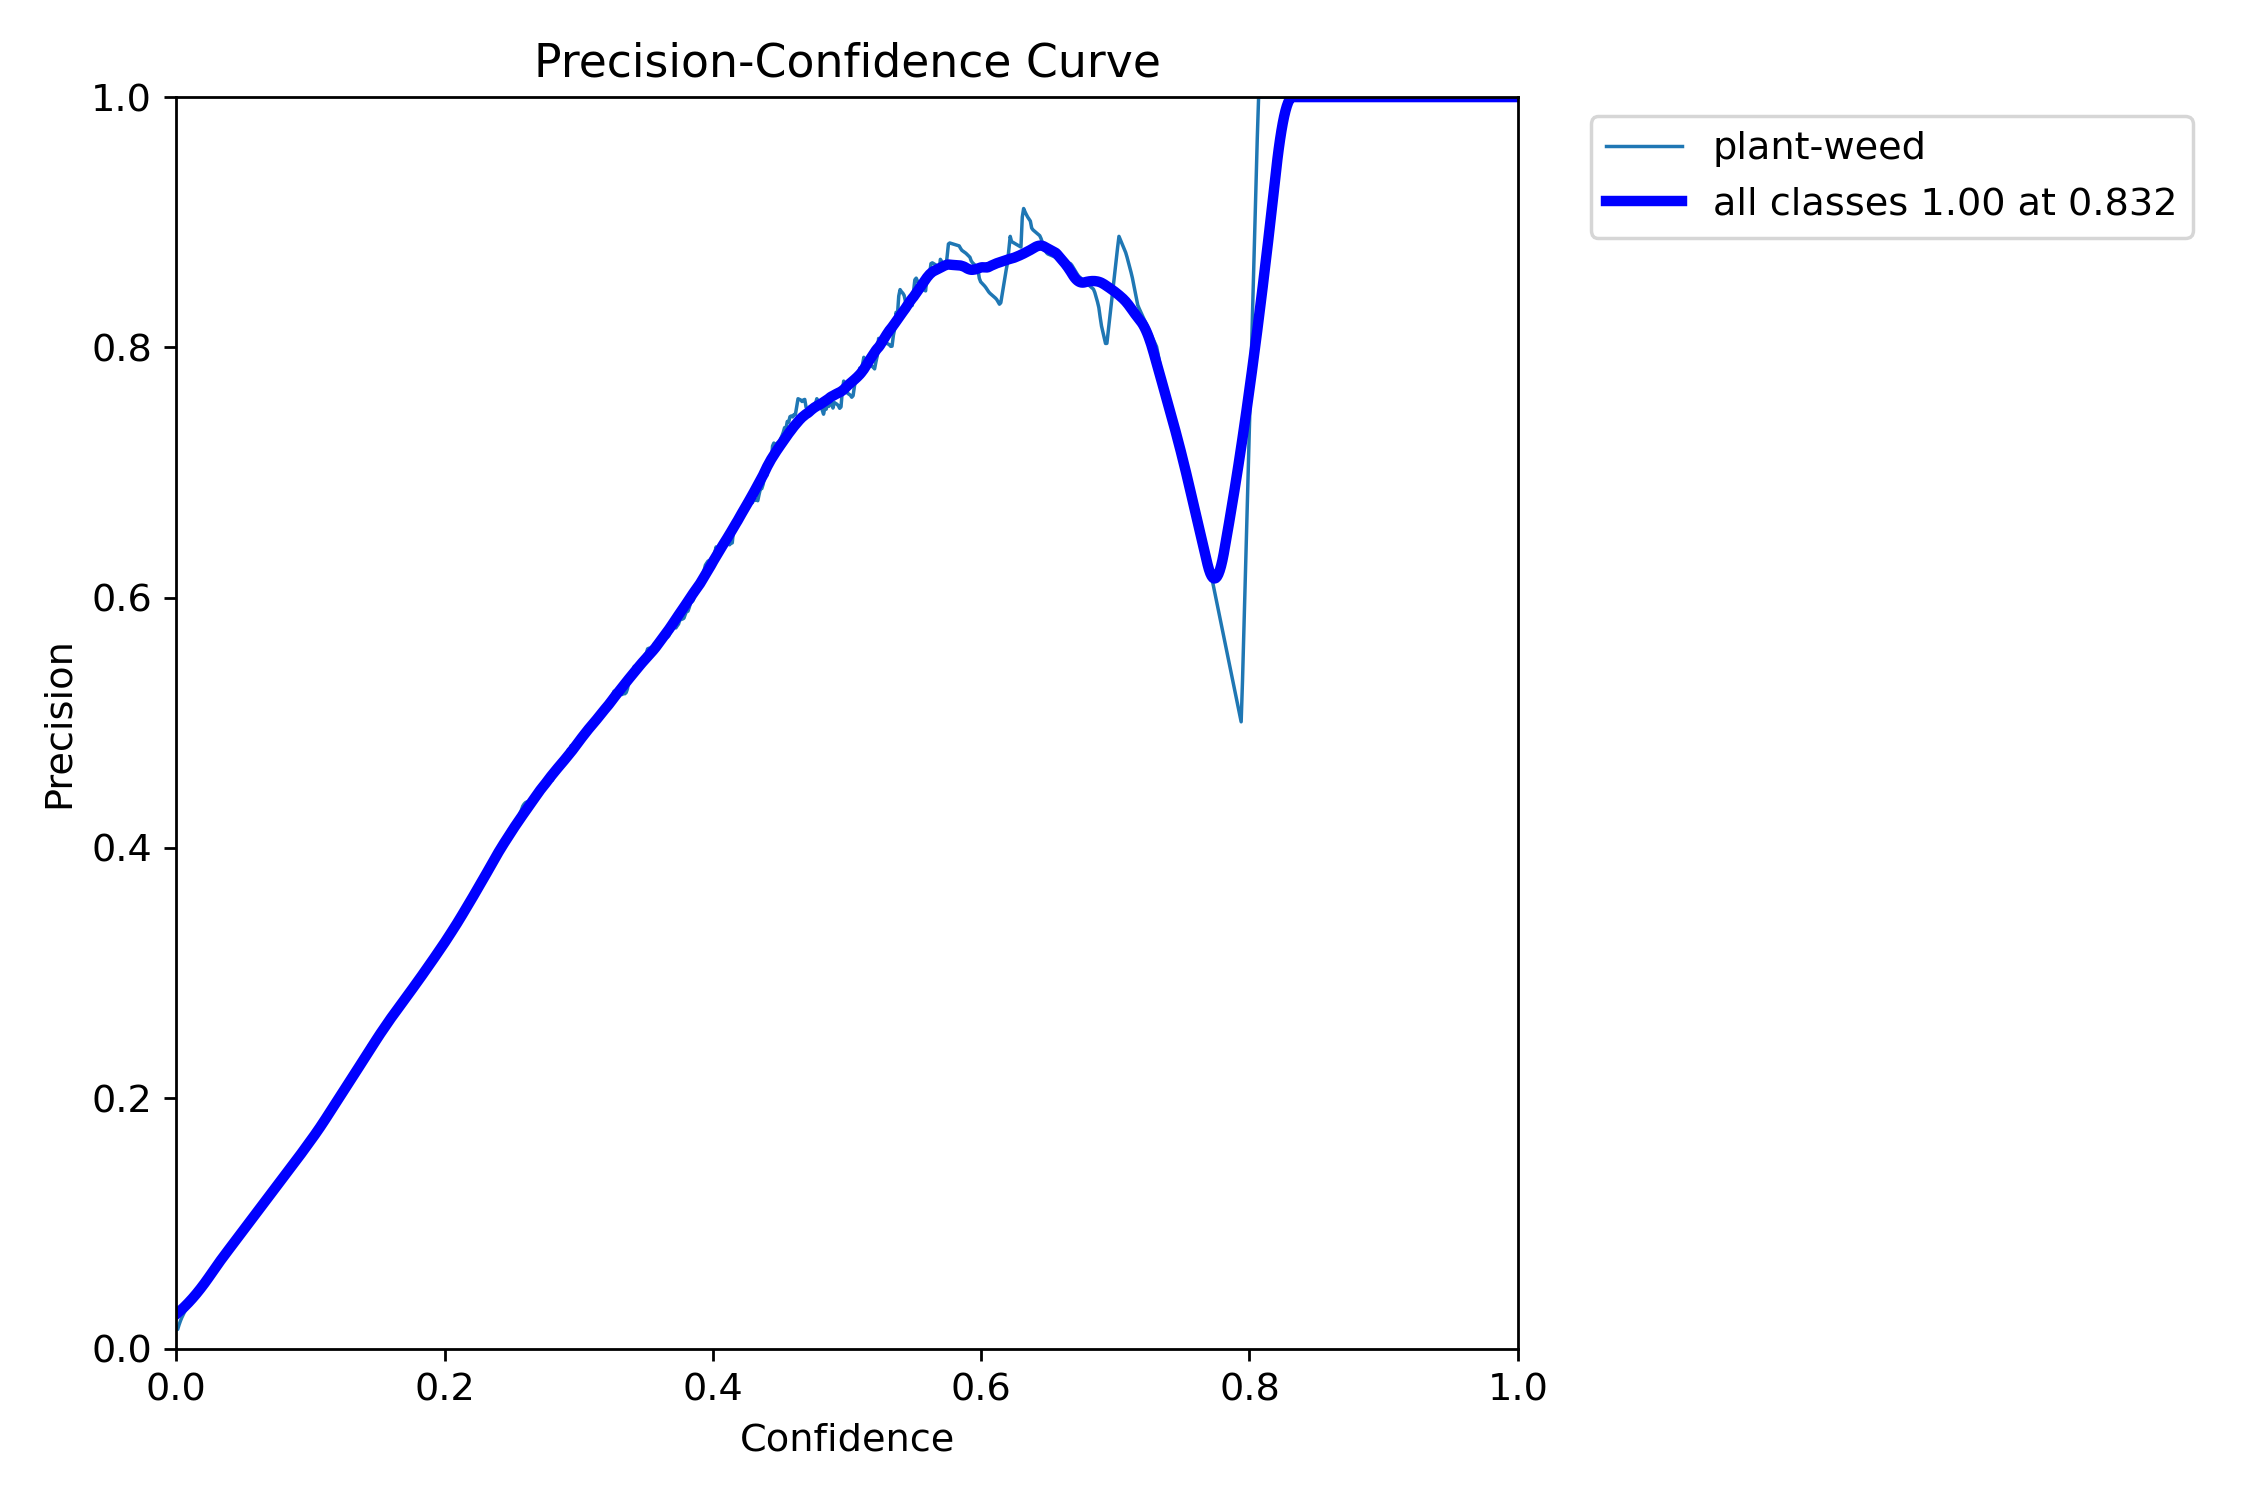

In [338]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

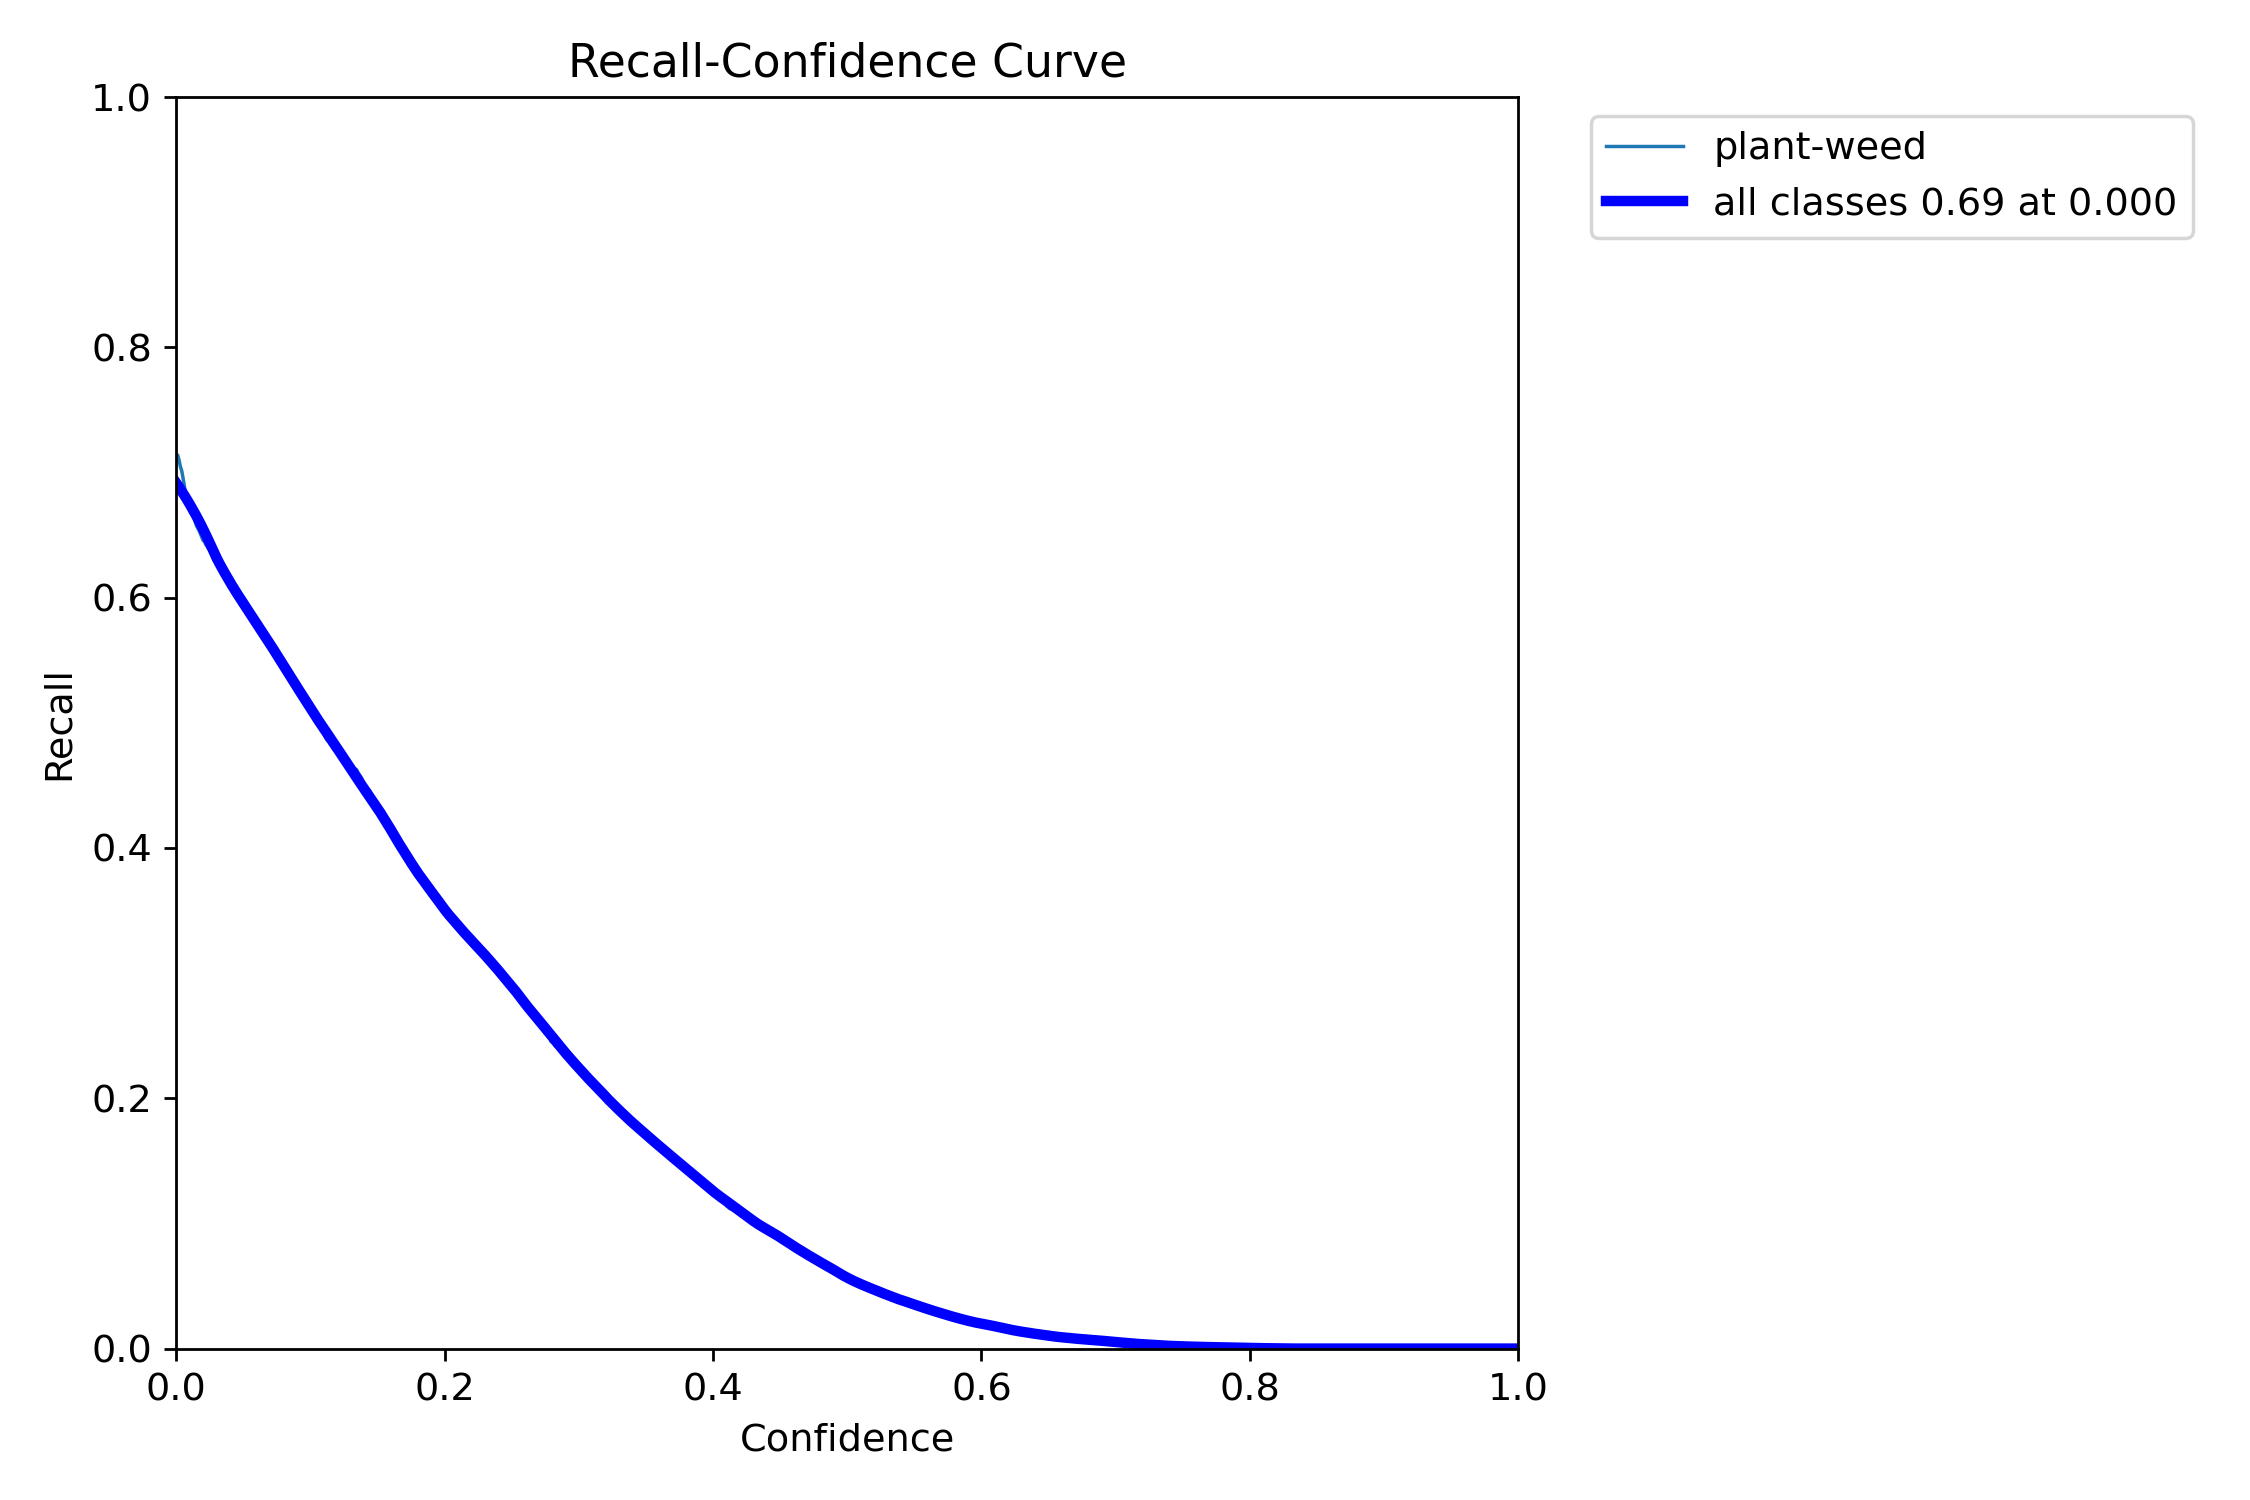

In [339]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

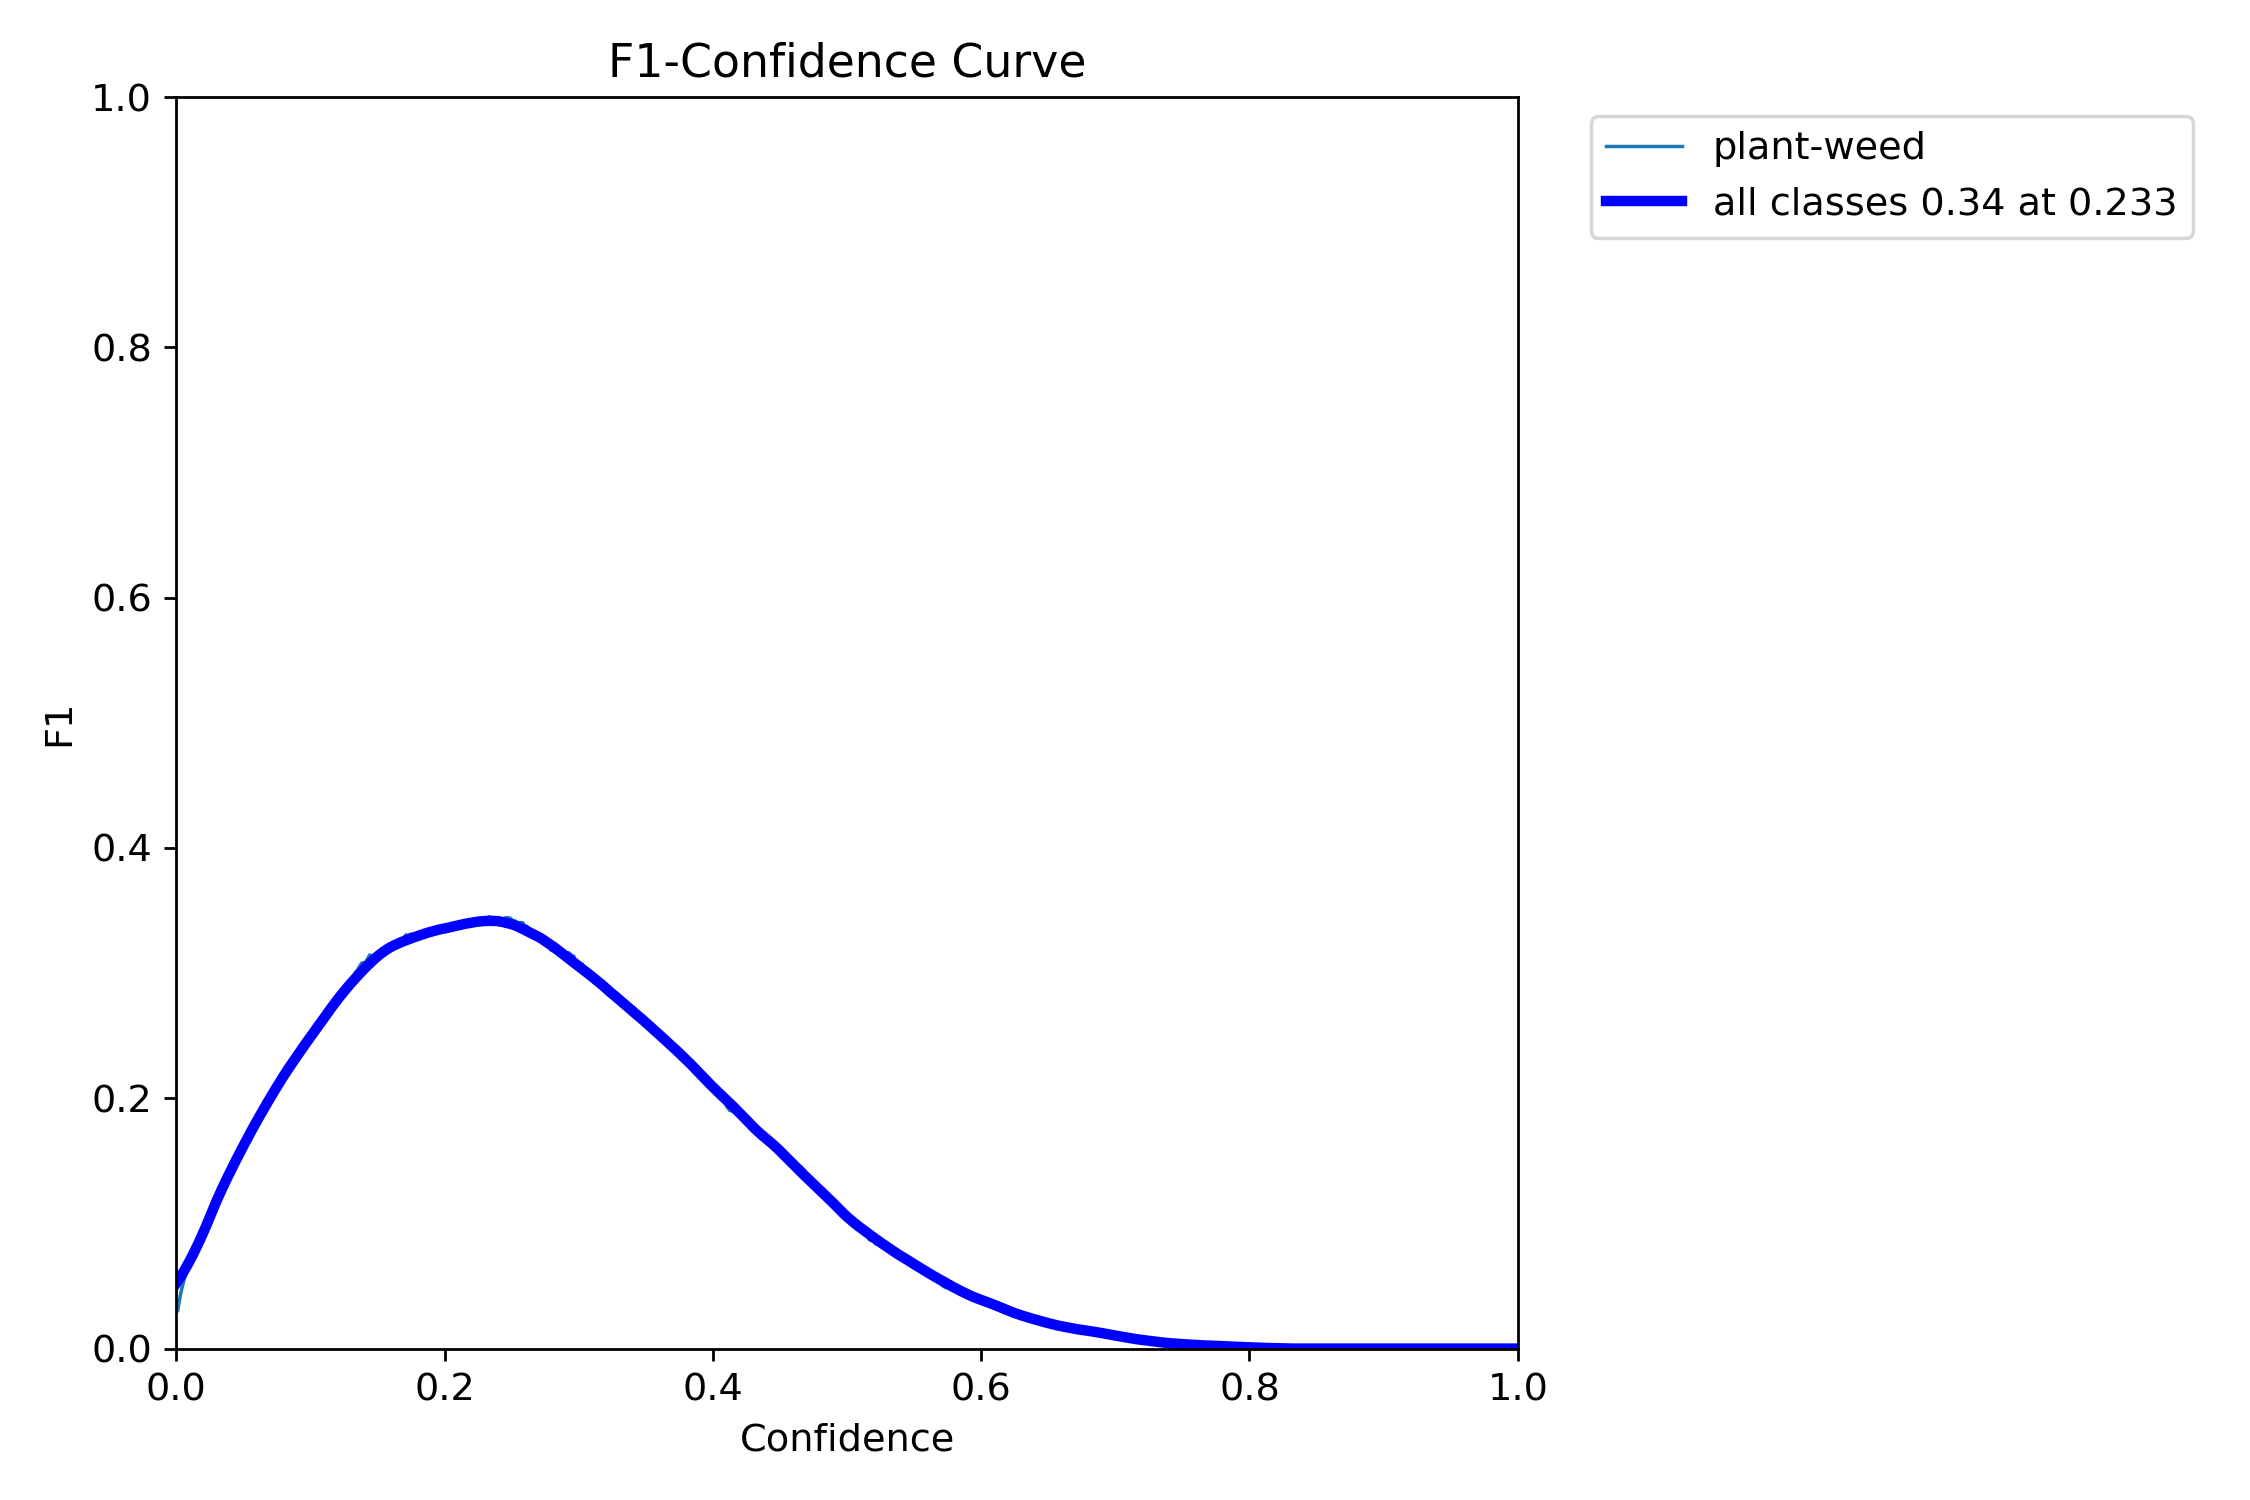

In [340]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

### Conclusiones

1. **Pérdidas de entrenamiento y validación (Losses)**

- Leve mejora de las métricas de pérdida hacia el final del entrenamiento.
- La reducción es modesta, aproximadamente 10-15%
- Para el set de validation no se observa una mejora significativa, incluso hay un ligero deterioro.
- El gap entre train y validation losses aumenta en las últimas epochs, indicando overfitting.

2. **Métricas de validación (Precisión, Recall, mAP)**

- La Precision (B) fluctúa entre 0.27-0.37 durante todo el entrenamiento, no muestra una tendencia clara de mejora.
- El Recall (B) es también muy volátil sin mejora consistente.
- Valores finales para mAP50 y mAP50-95 bajos.

3. **Evolución de la Tasa de Aprendizaje (Learning Rate, LR)** 

- Sigue un schedule de warmup seguido de decay
- Alcanza un máximo de ~0.0016 en epoch 17
- La estrategia de learning rate parece adecuada pero no logró mejorar significativamente el rendimiento

----

## Experiment 6 *(medium weed)*
### *3m | 60º | mid*

In [341]:
folder = "train3/"

In [342]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df3 = pd.read_csv(file_path)
df = df3.copy()
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
95,96,365.111,1.75143,1.27127,1.33133,0.41616,0.36675,0.31112,0.10607,2.43411,1.56370,1.74931,0.000119,0.000119,0.000119
96,97,369.414,1.74814,1.24333,1.31370,0.42113,0.36491,0.31377,0.10712,2.43702,1.55823,1.74691,0.000099,0.000099,0.000099
97,98,372.680,1.76302,1.24645,1.32142,0.41815,0.36879,0.32322,0.11058,2.42739,1.54375,1.73380,0.000079,0.000079,0.000079
98,99,375.940,1.77293,1.25364,1.31736,0.42100,0.37143,0.32719,0.11110,2.42786,1.54079,1.73129,0.000060,0.000060,0.000060
99,100,379.832,1.73882,1.23113,1.30294,0.42395,0.37245,0.32803,0.11076,2.42969,1.54129,1.73093,0.000040,0.000040,0.000040


***NOTE:***
- `lr/pg0` typically refers to the learning rate for the backbone weights.
- `lr/pg1` is usually associated with the learning rate for the YOLO layers' weights.
- `lr/pg2` often represents the learning rate for any additional parameters, such as biases.

In [343]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 6.331 min


#### Best epoch

In [344]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
2,3,15.2867,1.94095,1.38623,1.37063,0.42149,0.37612,0.33795,0.11457,2.40982,1.533,1.69937,0.000333,0.000333,0.000333,6.330533


In [345]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Mejor época de entrenamiento 3 con mAP50 de 0.338


In [346]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [347]:
TP = 1740
FP = 1569
FN = 3168
base = TP+FP+FN
print("Total de objetos detectados:", base)

Total de objetos detectados: 6477


In [348]:
# Cálculo de porcentajes
TP/base, FP/base, FN/base

(0.2686428902269569, 0.24224177860120427, 0.4891153311718388)

### Graphs

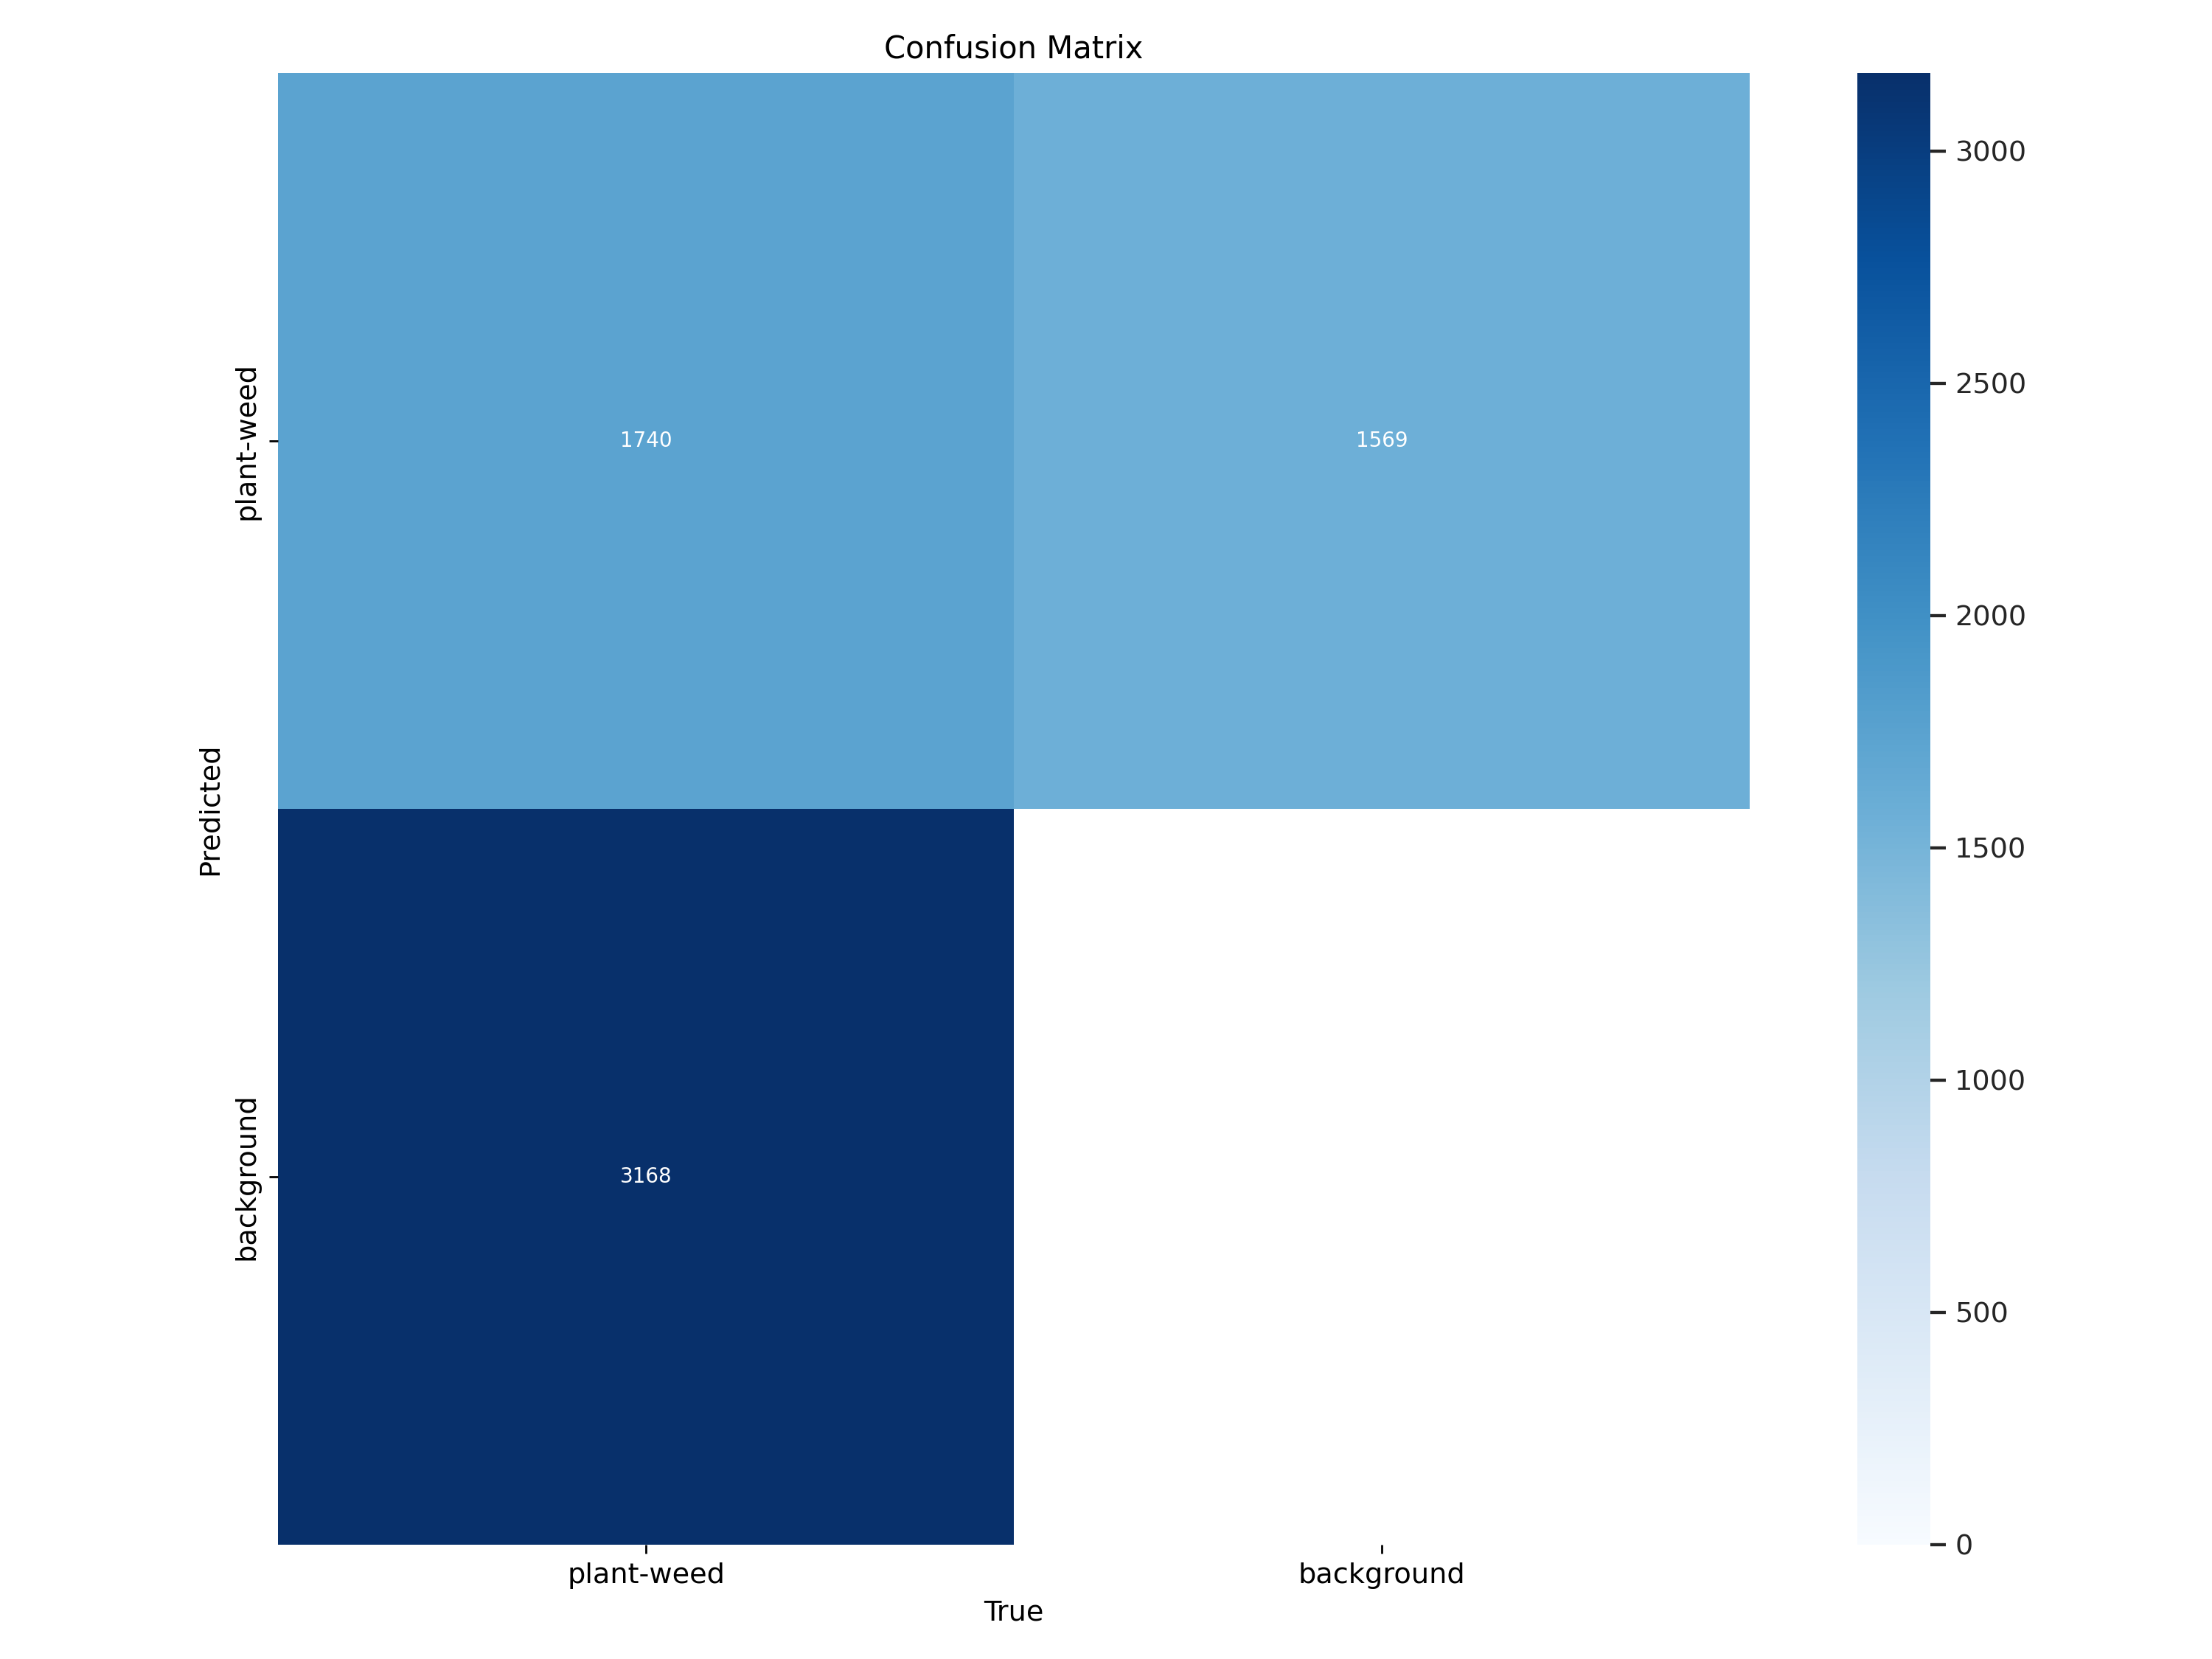

In [349]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

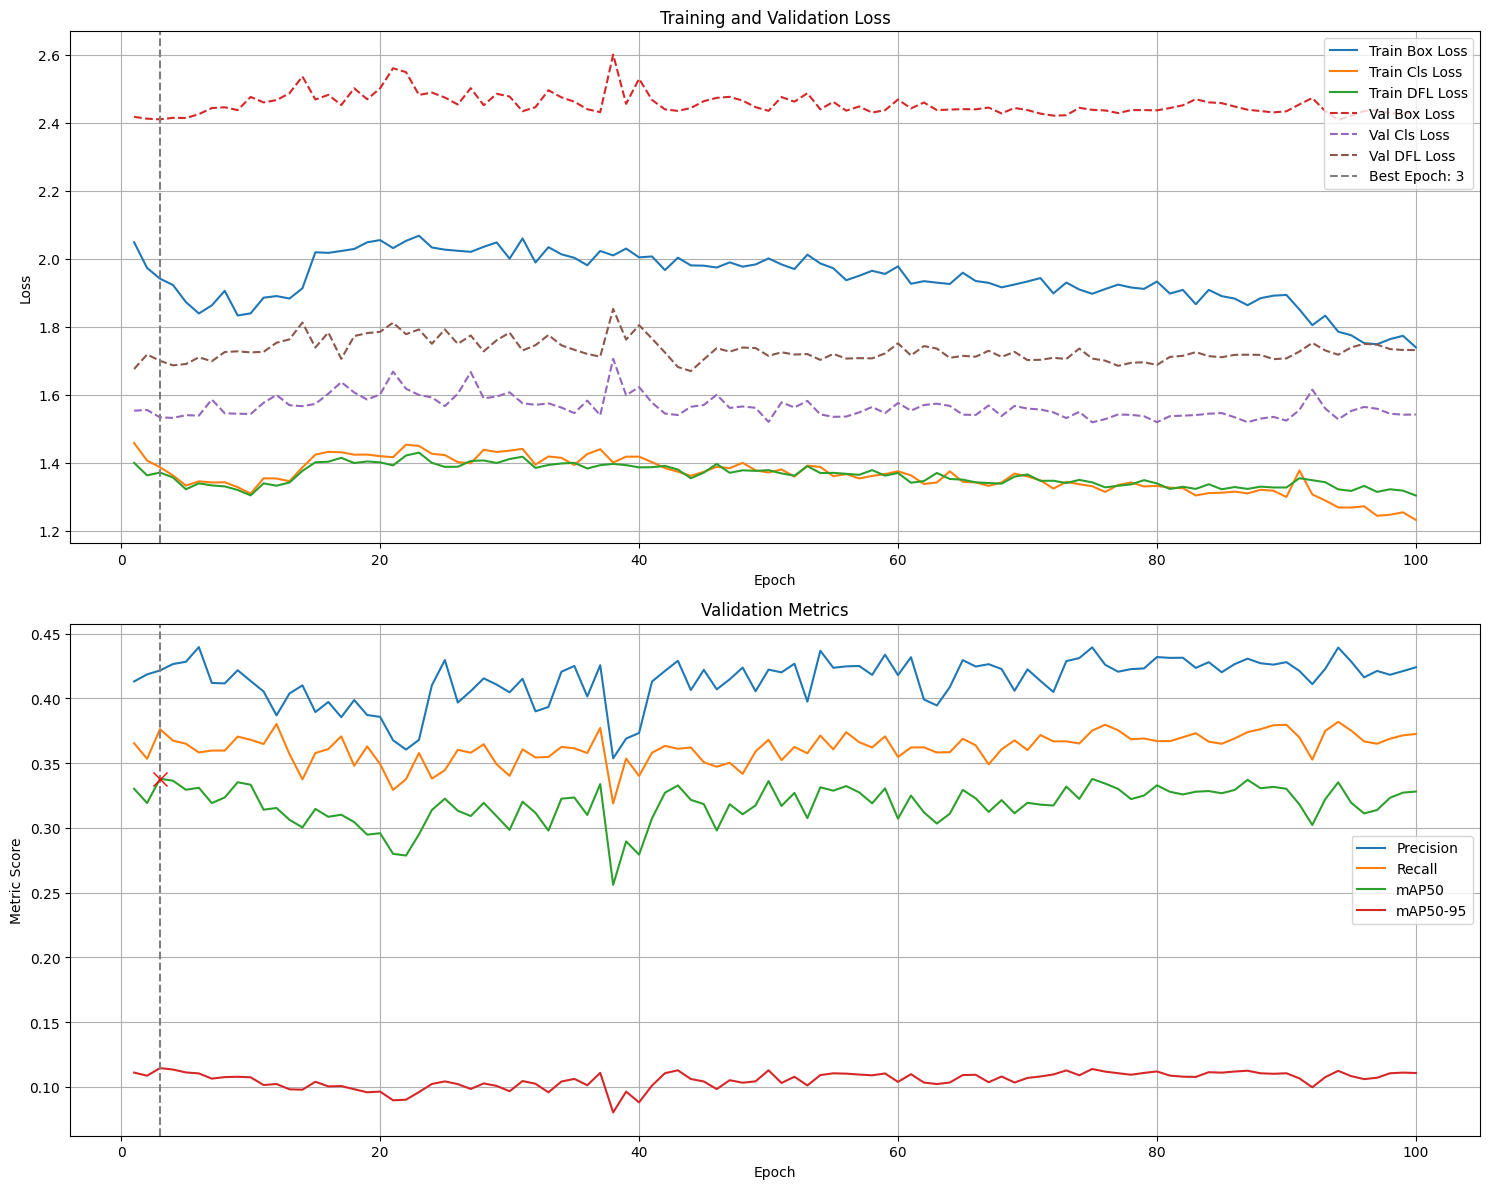

In [350]:
graph_training_metrics(df3, epoch, graph="full")

In [351]:
graph_LrLoss_3D(df3)

Validation set


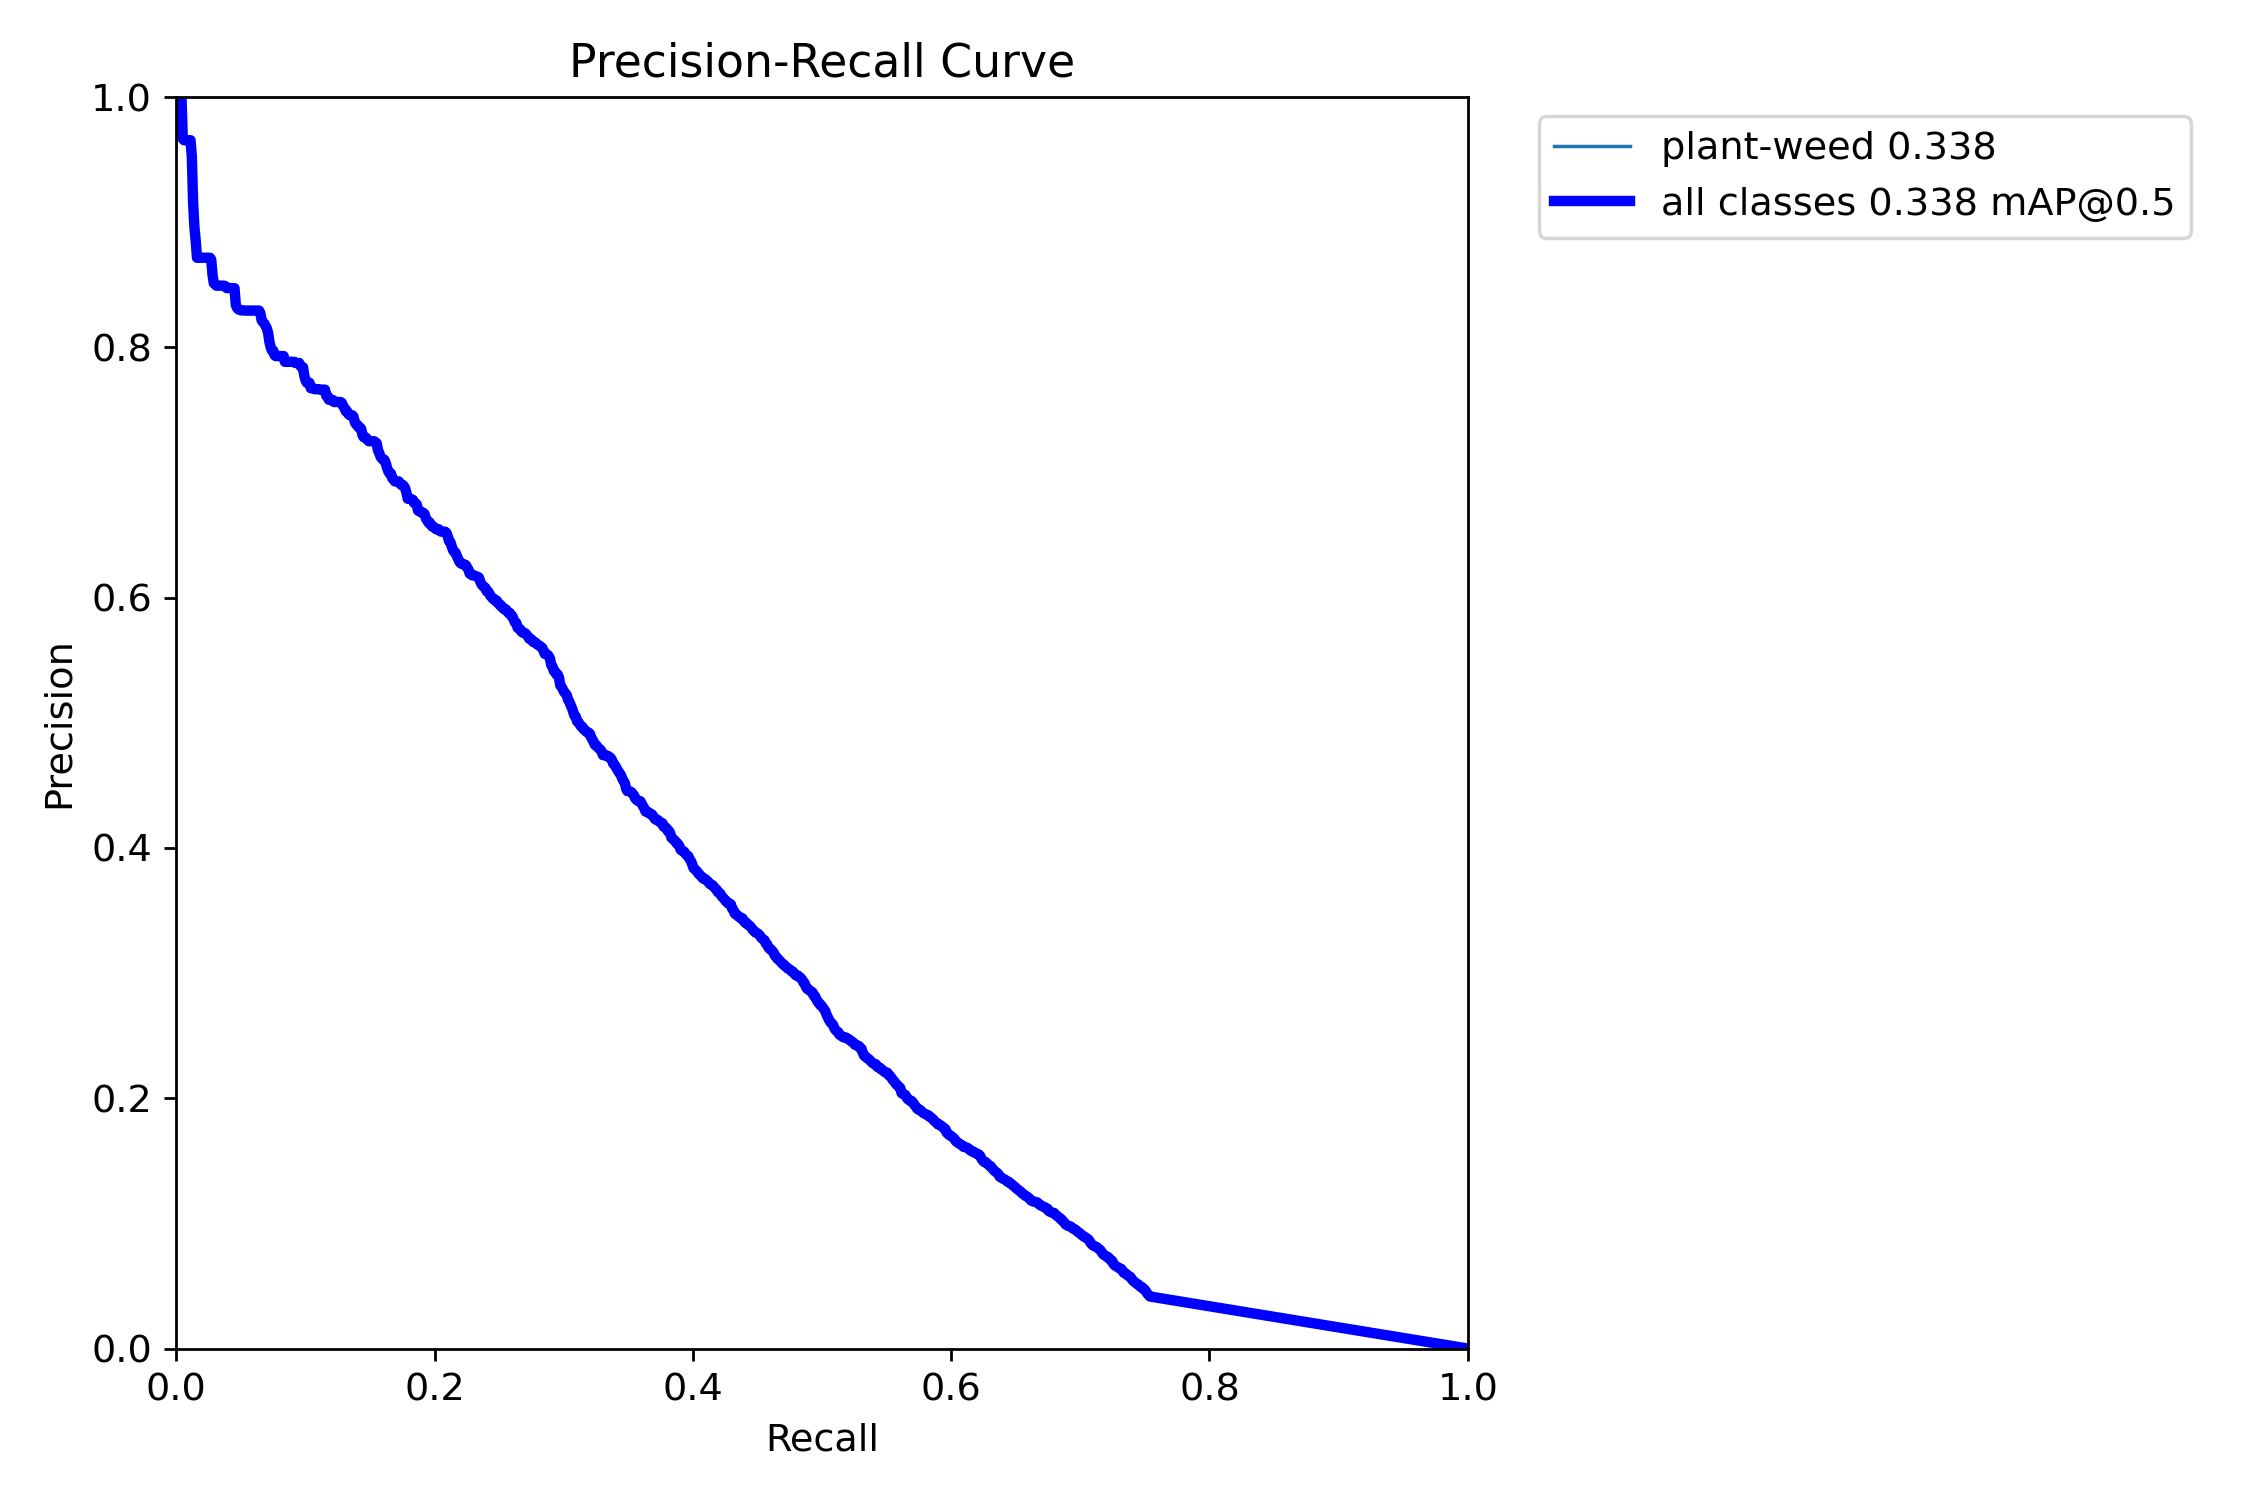

In [352]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

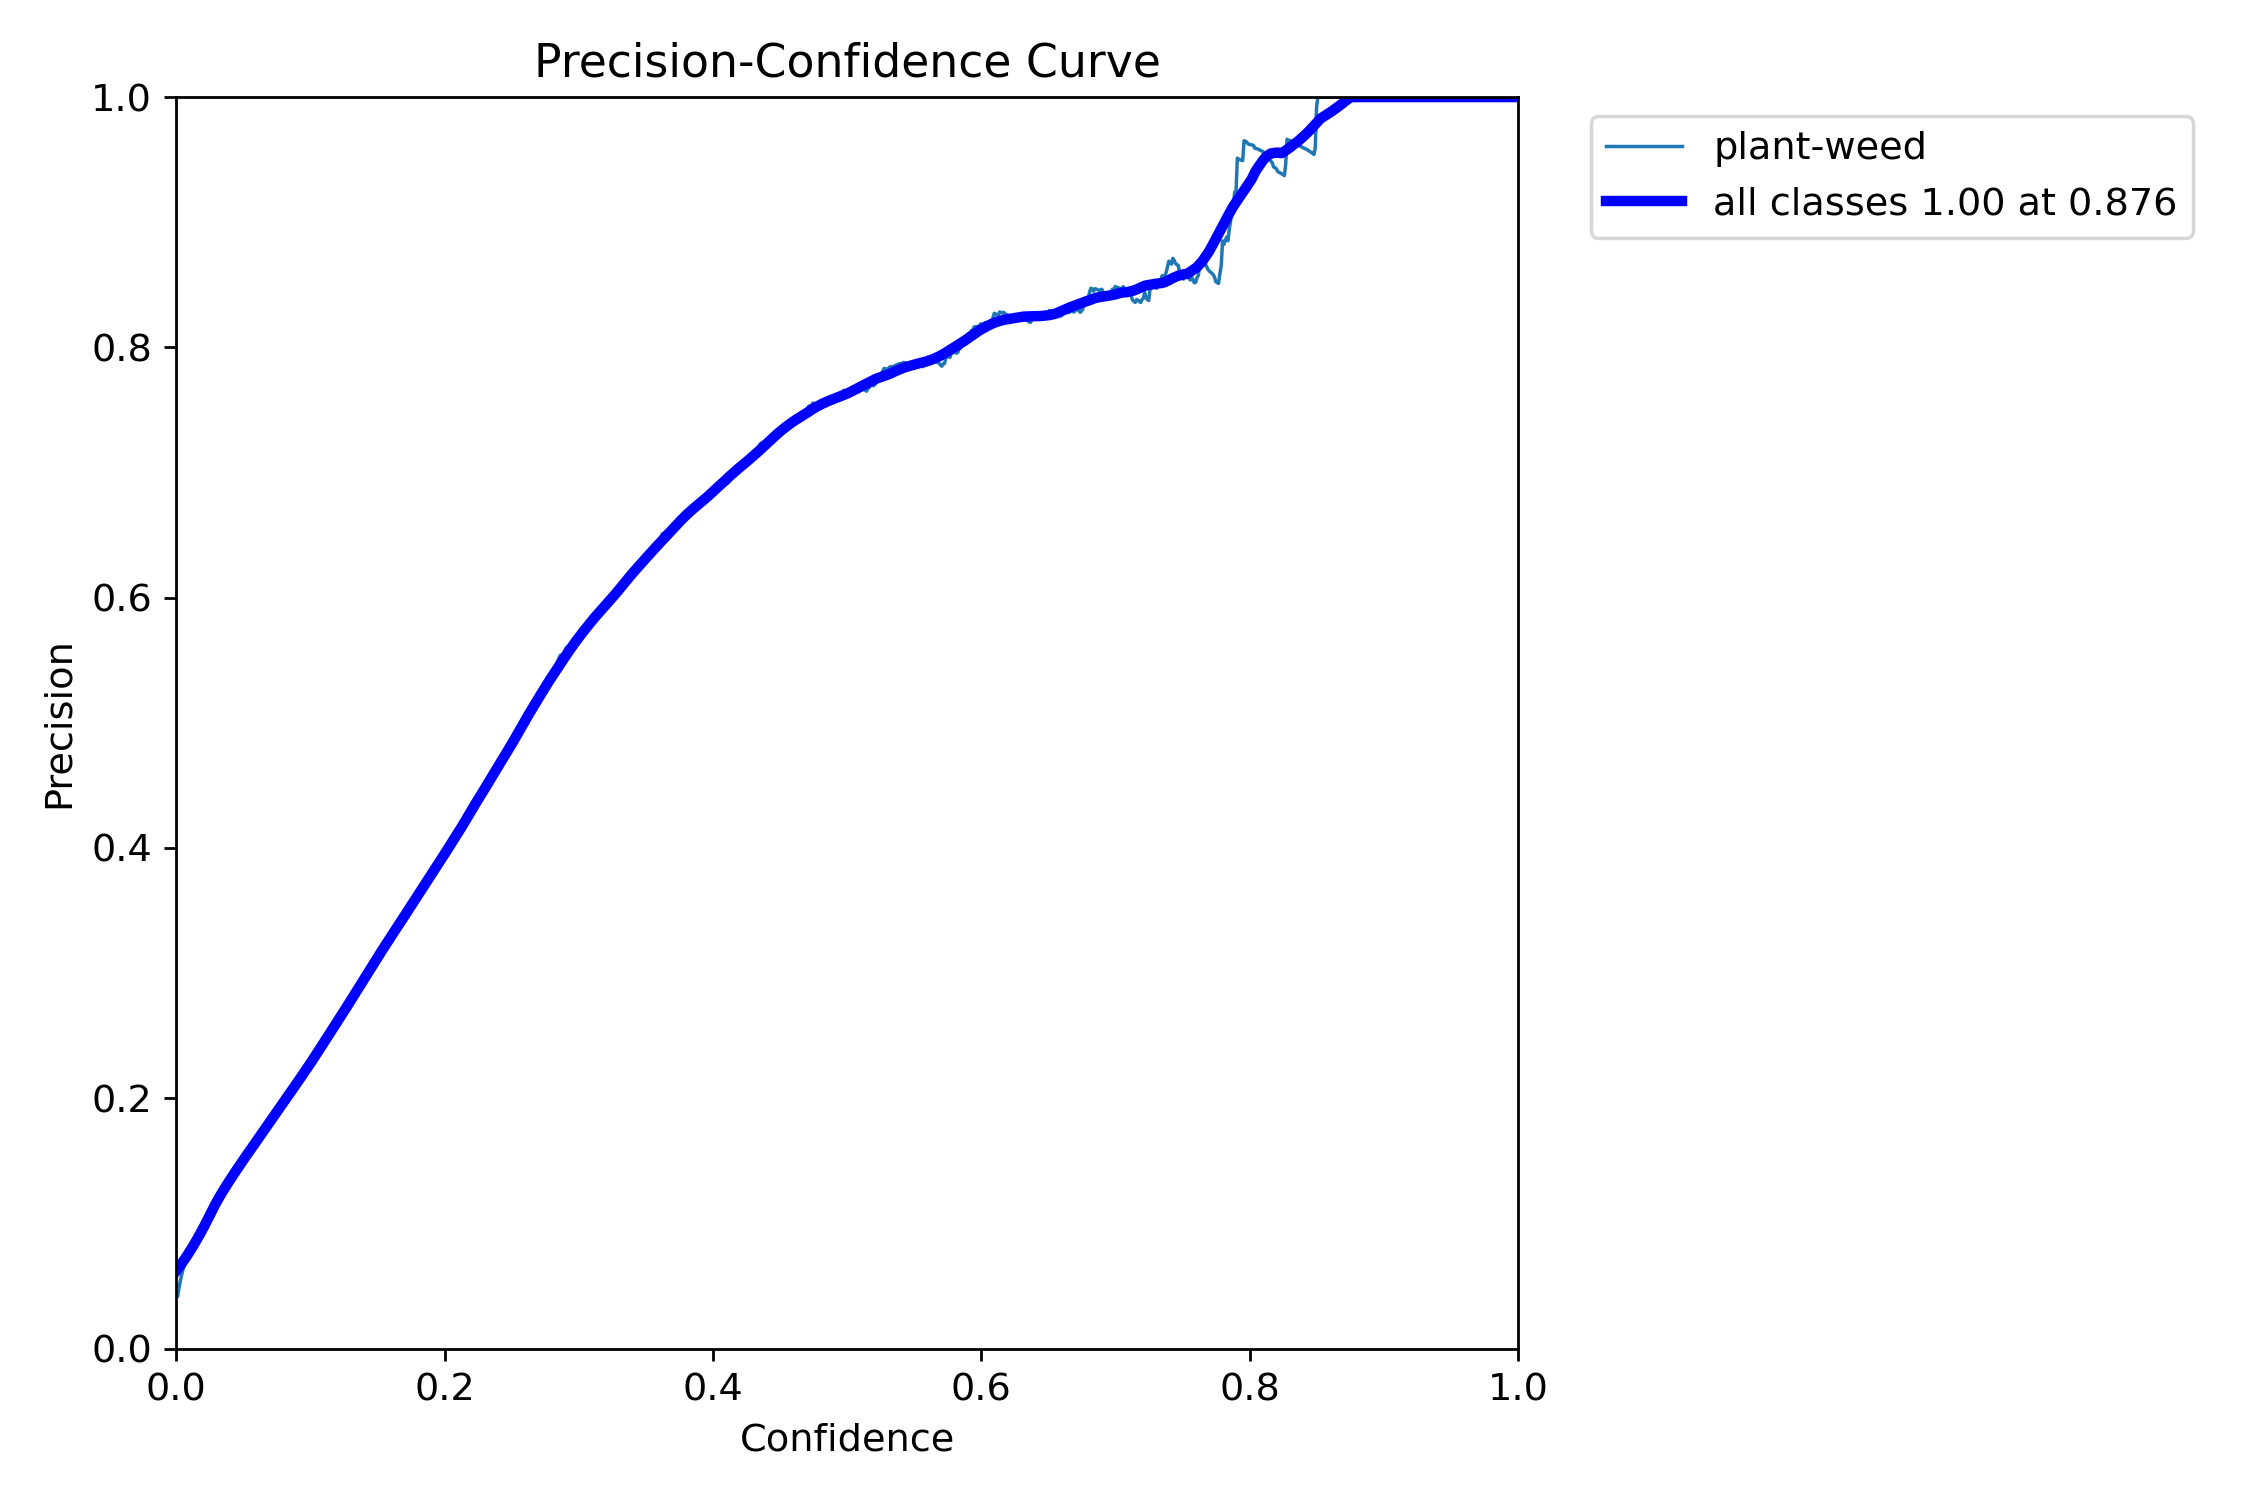

In [353]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

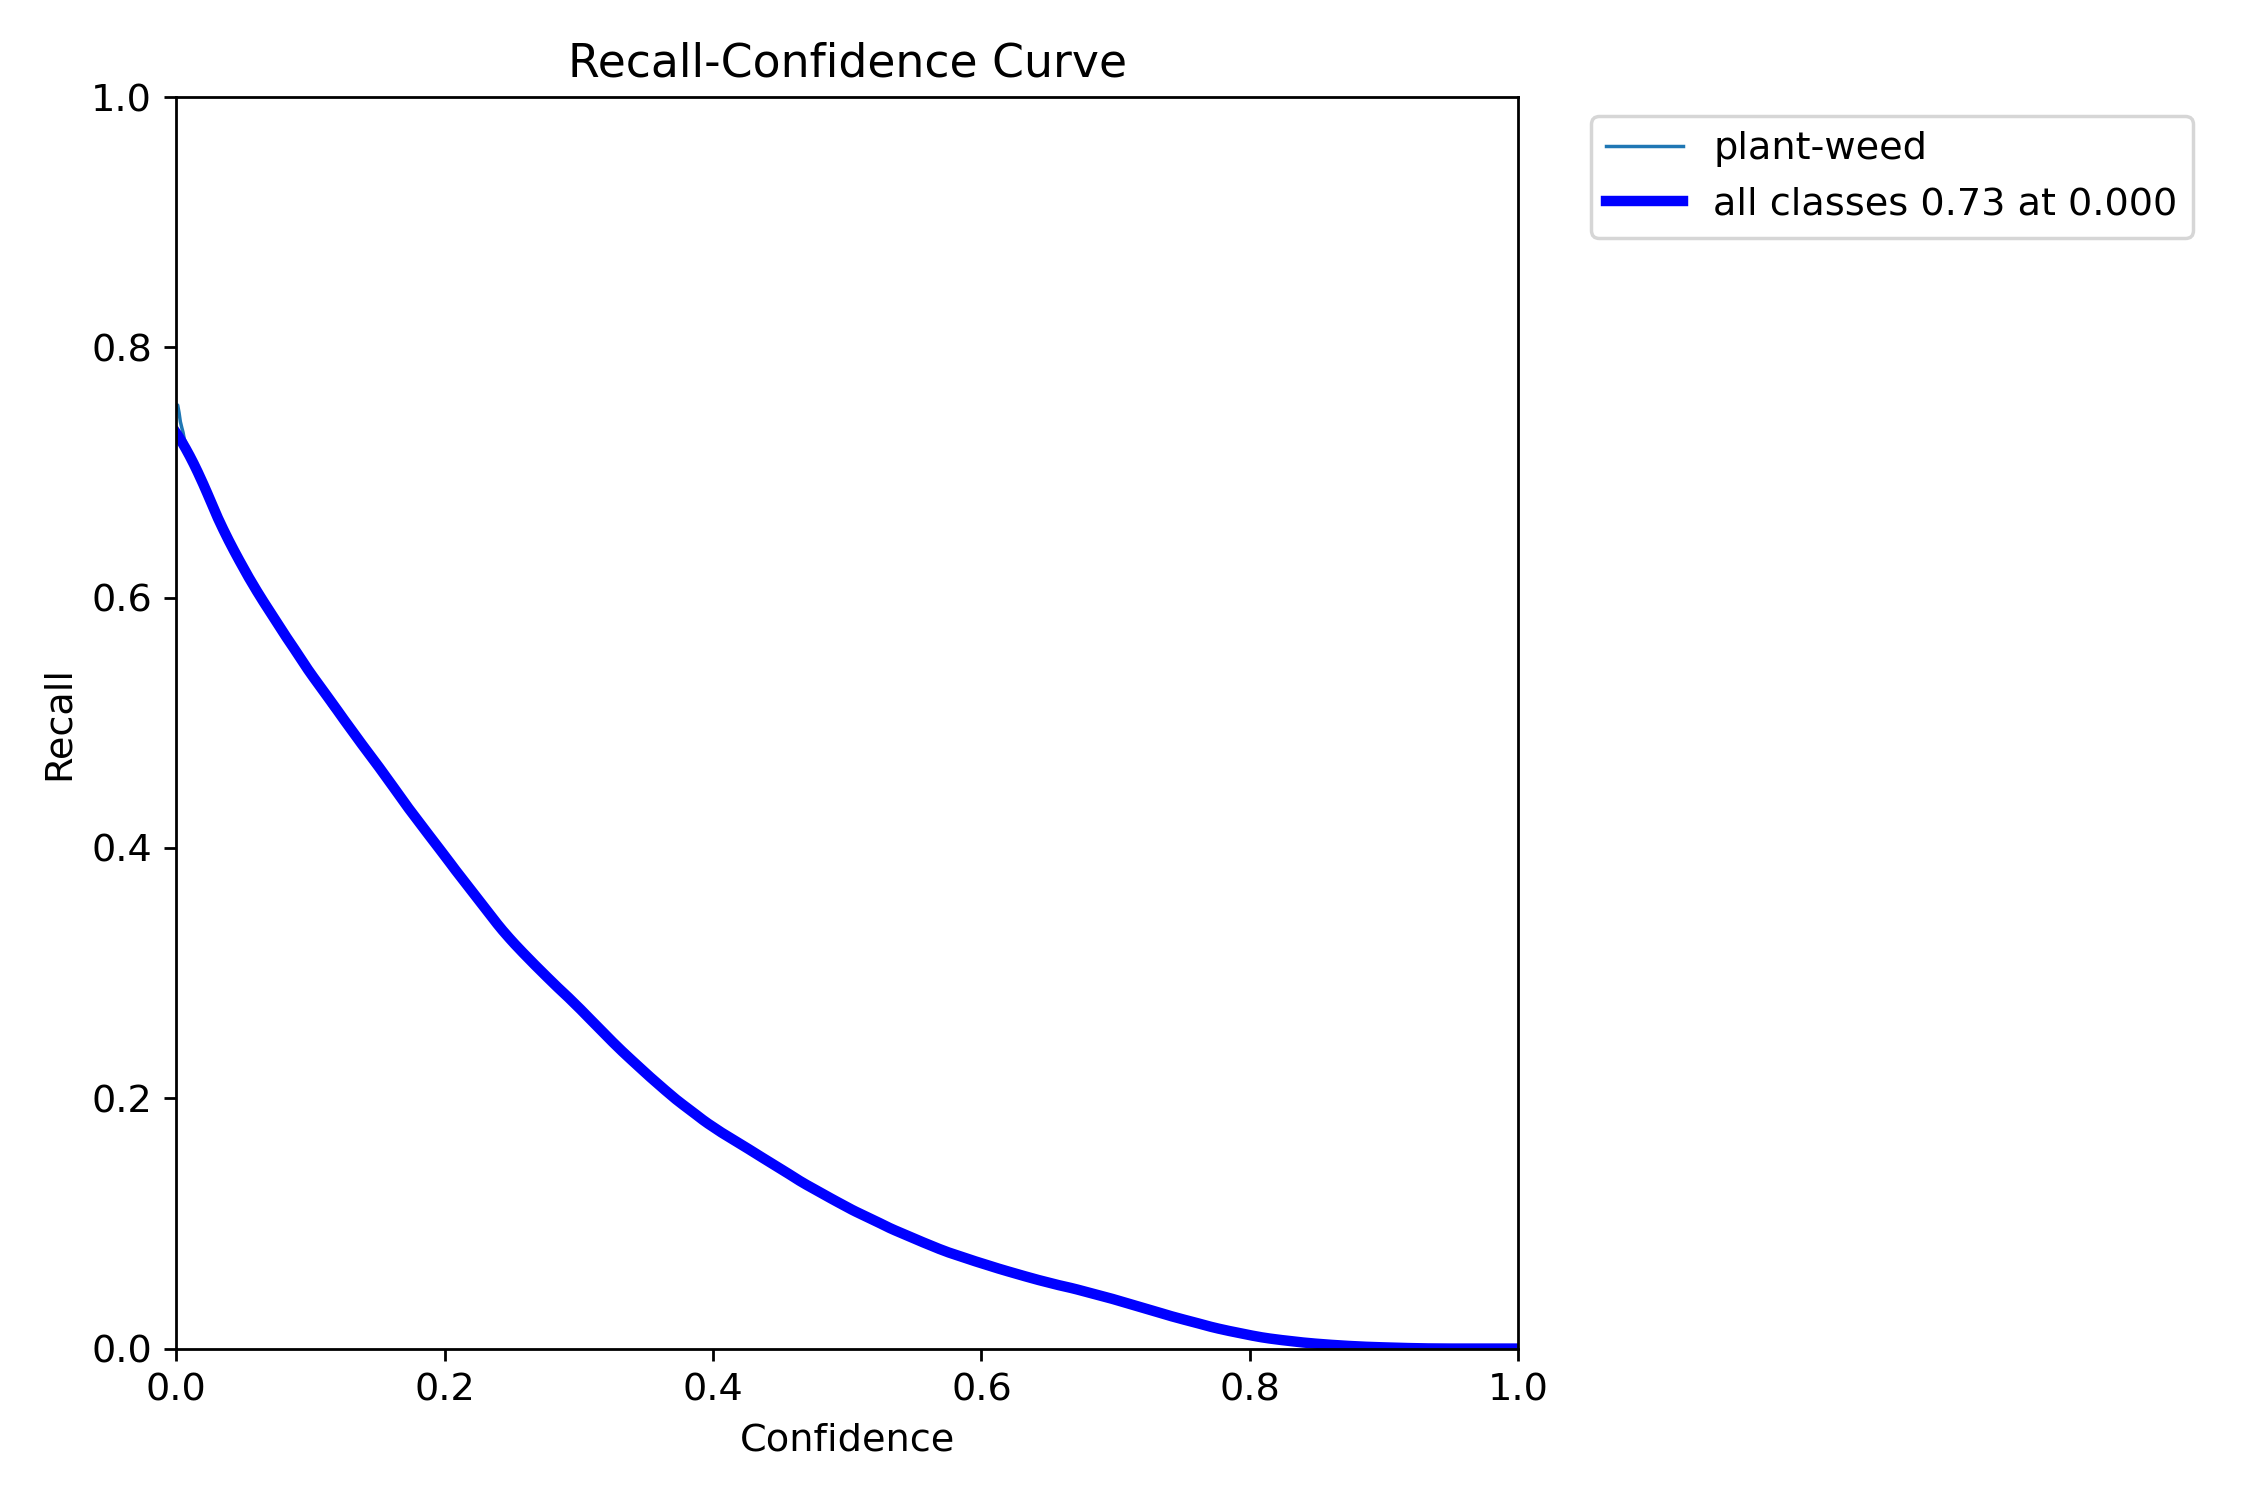

In [354]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

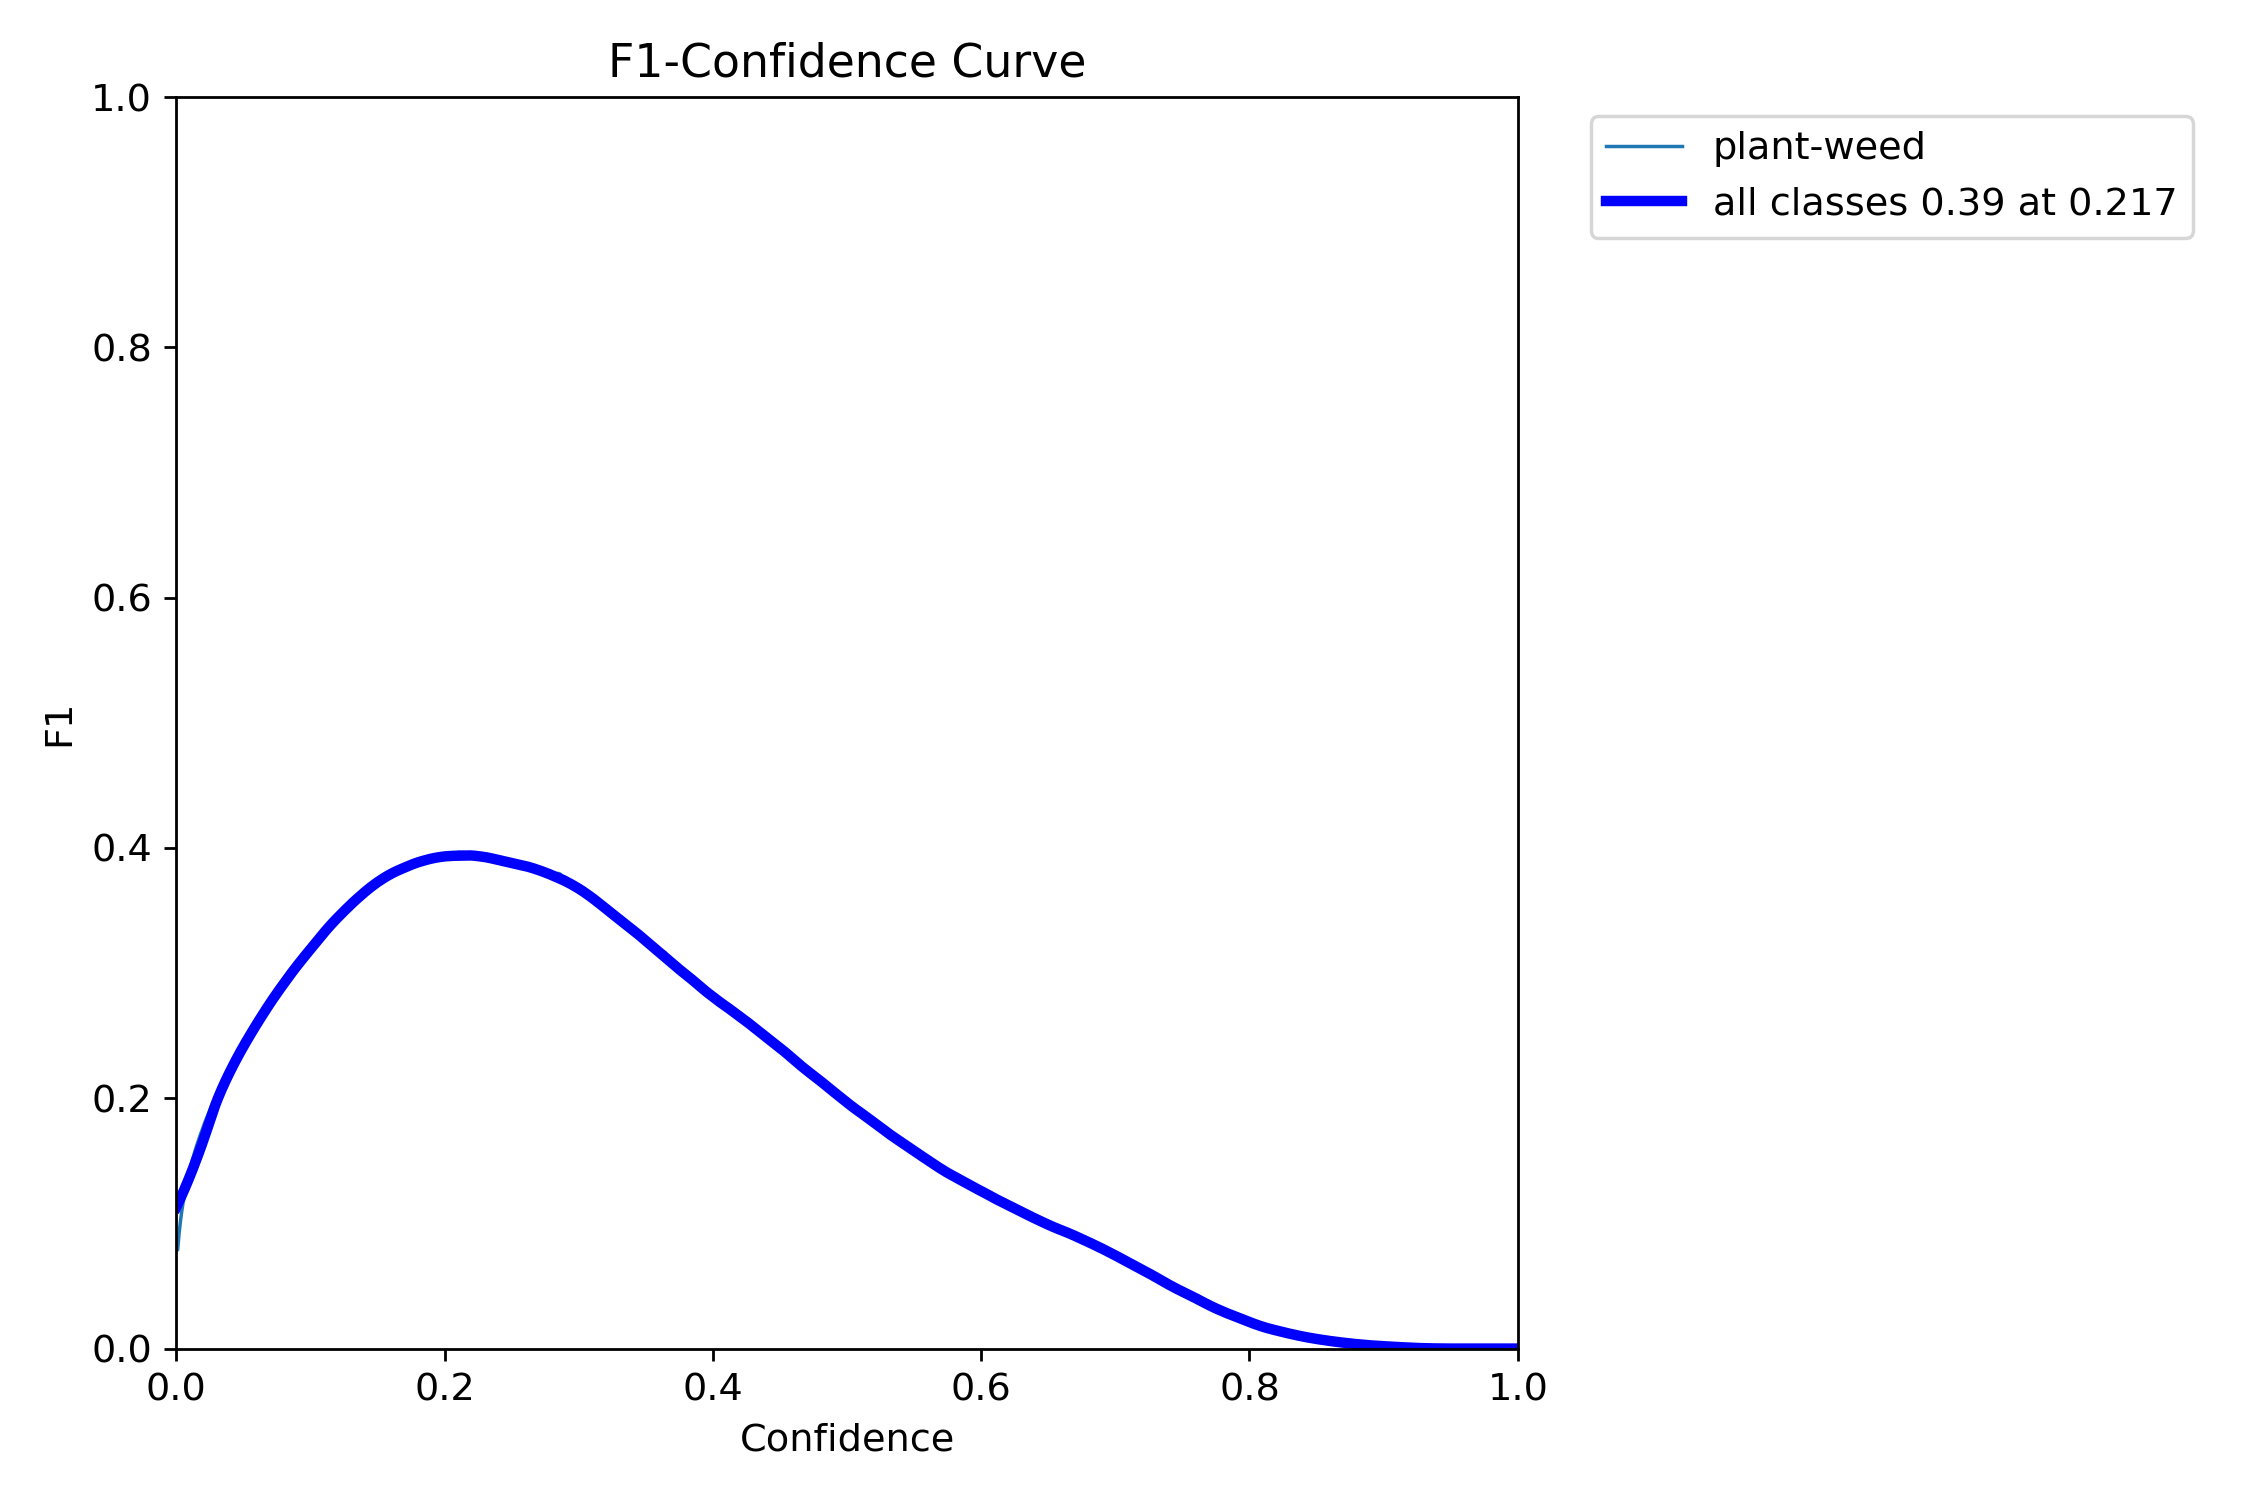

In [355]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

From the F1 curve, the confidence value that optimizes precision and recall is 0.231. In many cases a higher confidence value is desirable.

### Conclusiones

1. **Pérdidas de entrenamiento y validación  (Losses)**

- Las pérdidas de entrenamiento muestran una tendencia general descendente.
- Las pérdidas de validación se mantienen relativamente estables.
- La diferencia entre las pérdidas de entrenamiento y validación sugiere cierto grado de sobreajuste.

2. **Métricas de validación (Precisión, Recall, mAP)**

- No se observa una mejora significativa de Precisión ni Recall durante el entrenamiento.
- mAP50 y mAP50-95 mejoran levemente hacia las últimas epochs.
- Estas métricas sugieren un rendimiento moderado del modelo, con espacio para mejora.

3. **Evolución de la Tasa de Aprendizaje (Learning Rate, LR)** 

- Comienza en 0.0001 y se incremente progresivamente hasta la epoch 17.
- Luego decrece gradualmente hasta 3.98e-05.
- Este patrón sugiere que se utilizó un scheduler de learning rate cíclico o con warm-up inicial.

#### Observaciones generales 

- El modelo muestra signos de sobreajuste, dado el gap entre pérdidas de training y validación.
- El rendimiento en métricas de validación es moderado.
- El tiempo de inferencia (9.15ms) es razonable para aplicaciones en tiempo real.
- Las métricas de la matriz de confusión indican un alto número de falsos negativos (48.9%), sugiriendo que el modelo tiende a ser conservador en sus predicciones.

----

# Métricas generales

In [356]:
best_models.index = ['1º TRAIN','2º TRAIN','3º TRAIN']

In [357]:
best_models.sort_values(by='metrics/mAP50(B)', ascending=True)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
2º TRAIN,68,256.9400,1.92384,1.35116,1.34173,0.37980,0.33399,0.26369,0.07458,2.66382,1.97159,1.51733,0.000673,0.000673,0.000673,6.235783
1º TRAIN,86,605.9210,1.97979,1.40062,1.37308,0.41873,0.35573,0.31889,0.10399,2.54386,1.74818,1.61663,0.000317,0.000317,0.000317,11.701633
3º TRAIN,3,15.2867,1.94095,1.38623,1.37063,0.42149,0.37612,0.33795,0.11457,2.40982,1.53300,1.69937,0.000333,0.000333,0.000333,6.330533


## Graphs

In [358]:
def plot_metric(metric, ylabel, title, max_epoch=None):
    """
    Plots a metric from multiple DataFrames with an optional limit on the x-axis.

    Args:
        metric (str): The column name representing the metric to plot.
        ylabel (str): The label for the y-axis.
        title (str): The title of the plot.
        max_epoch (int, optional): The maximum epoch to display on the x-axis. Defaults to None (no limit).
    """
    plt.figure(figsize=(15, 5))
    plt.plot(df1["epoch"], df1[metric], label=best_models.index[0], linestyle="--", marker="o", markersize=4)
    plt.plot(df2["epoch"], df2[metric], label=best_models.index[1], linestyle="--", marker="s", markersize=4)
    plt.plot(df3["epoch"], df3[metric], label=best_models.index[2], linestyle="--", marker="d", markersize=4)
    #plt.plot(df4["epoch"], df4[metric], label=best_models.index[3], linestyle="--", marker="*", markersize=4)
    plt.xlabel("Epochs")
    plt.ylabel(ylabel)
    plt.title(title)
    if max_epoch is not None:
        plt.xlim(0, max_epoch)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Training and Validation Losses

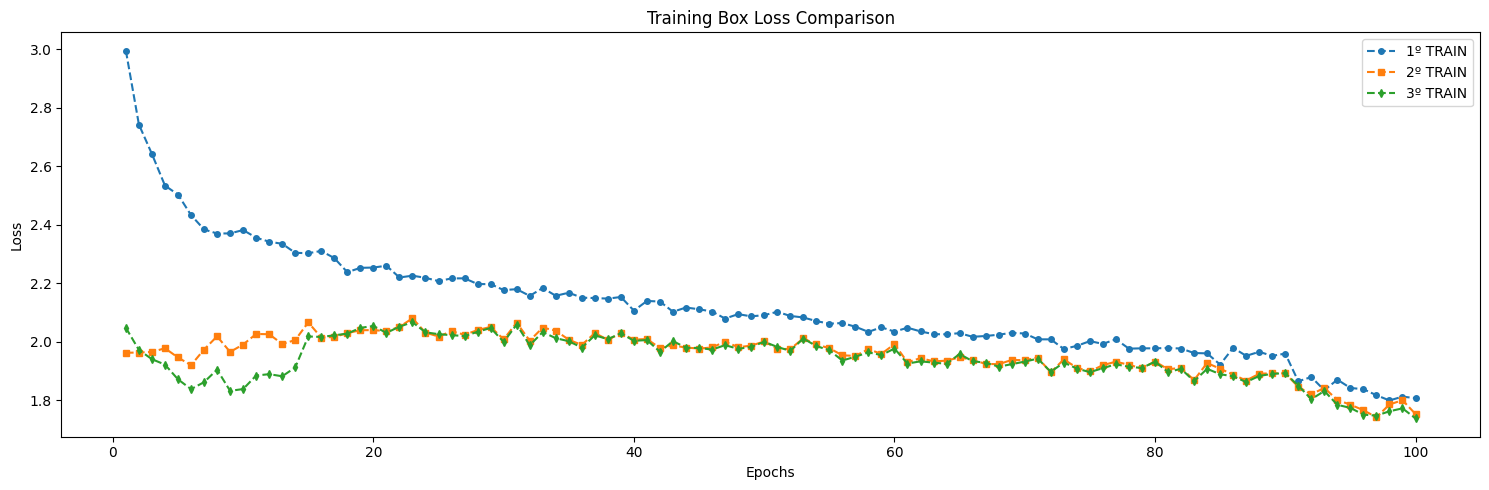

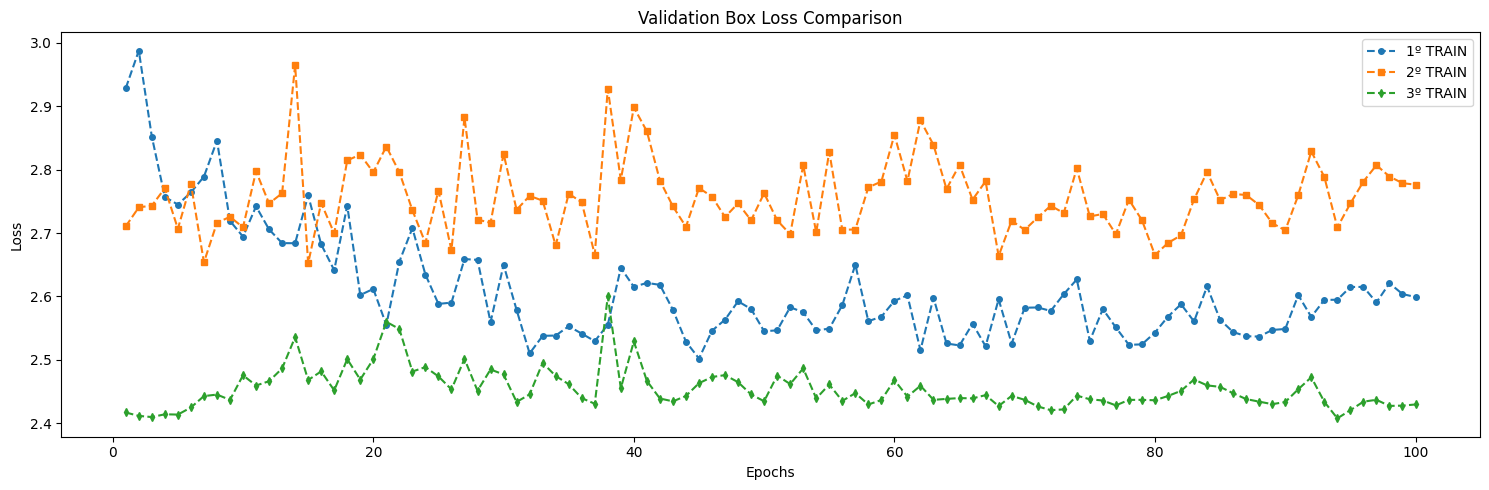

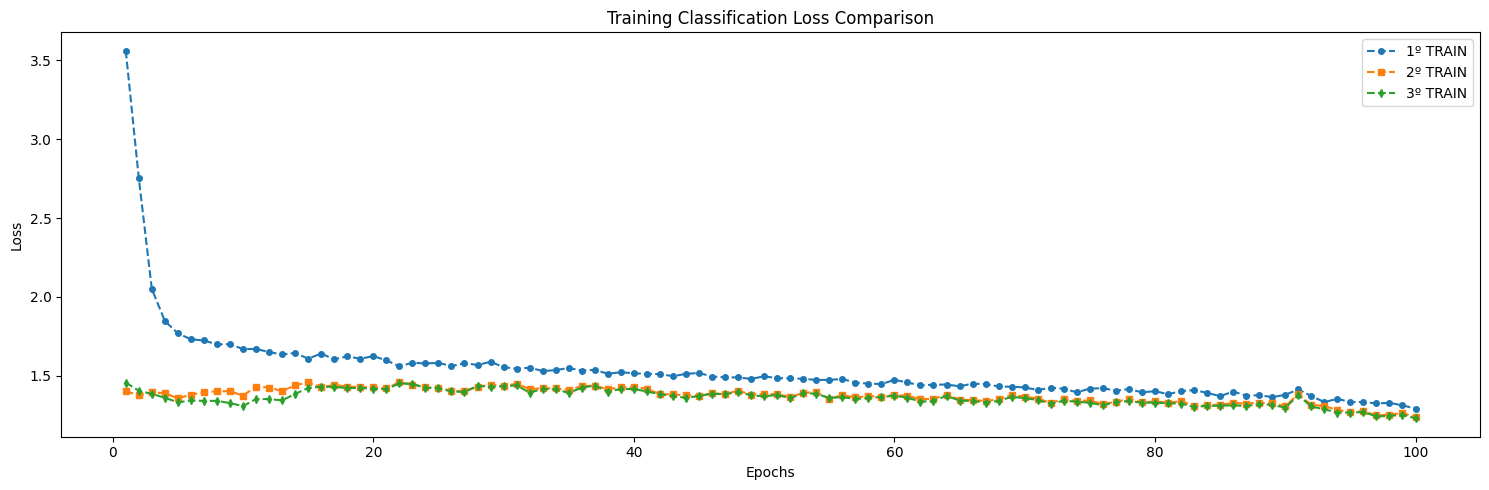

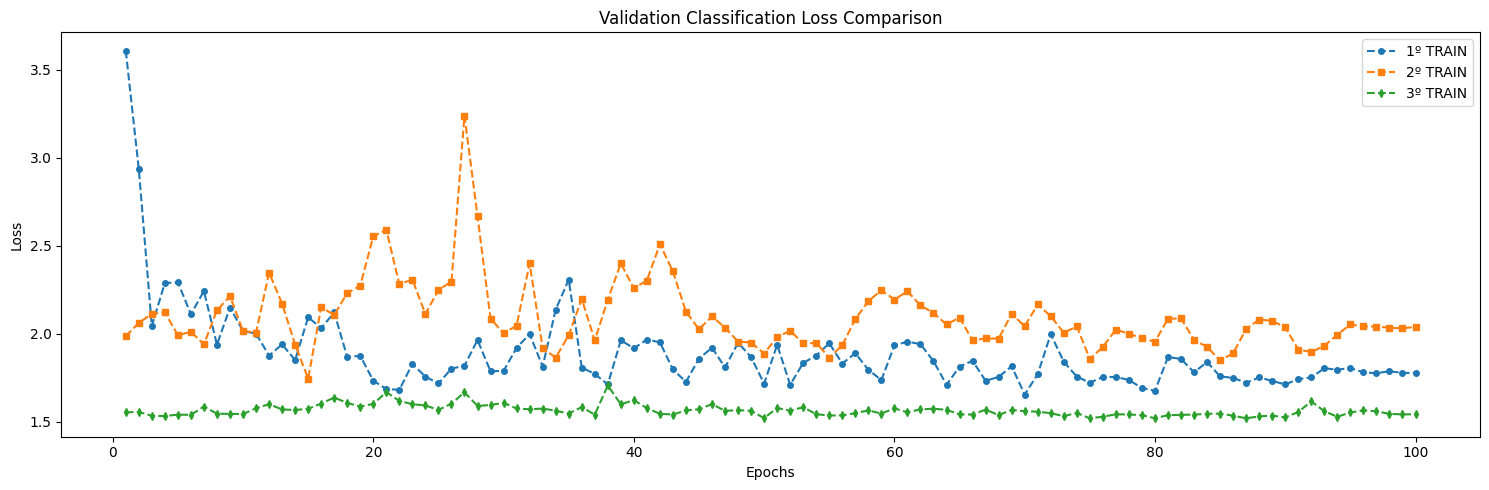

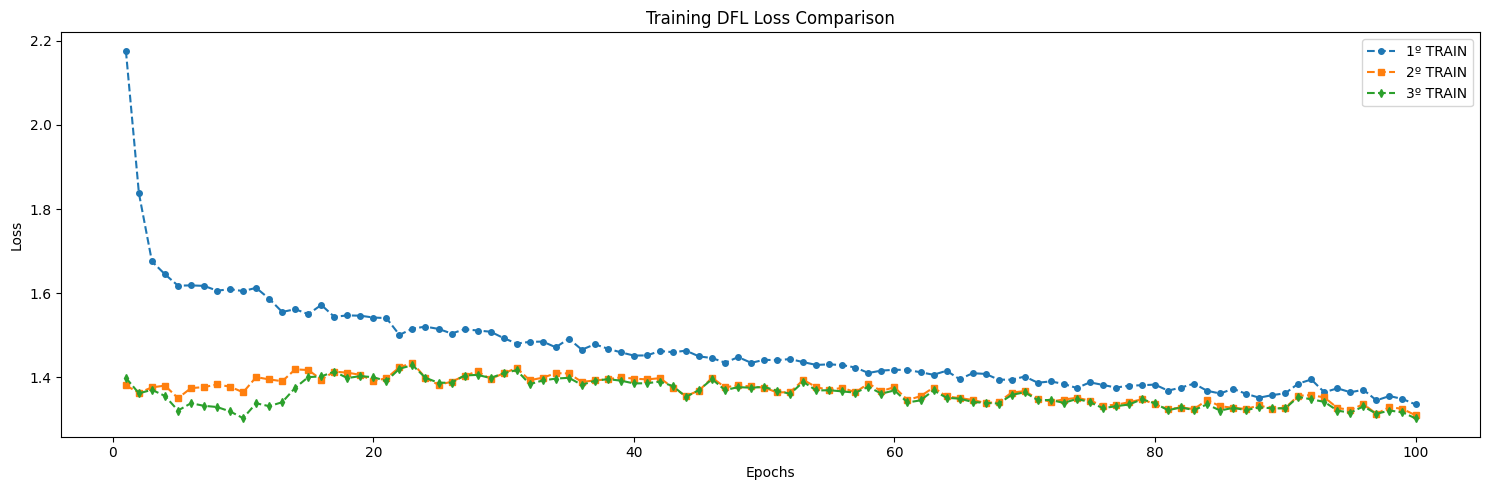

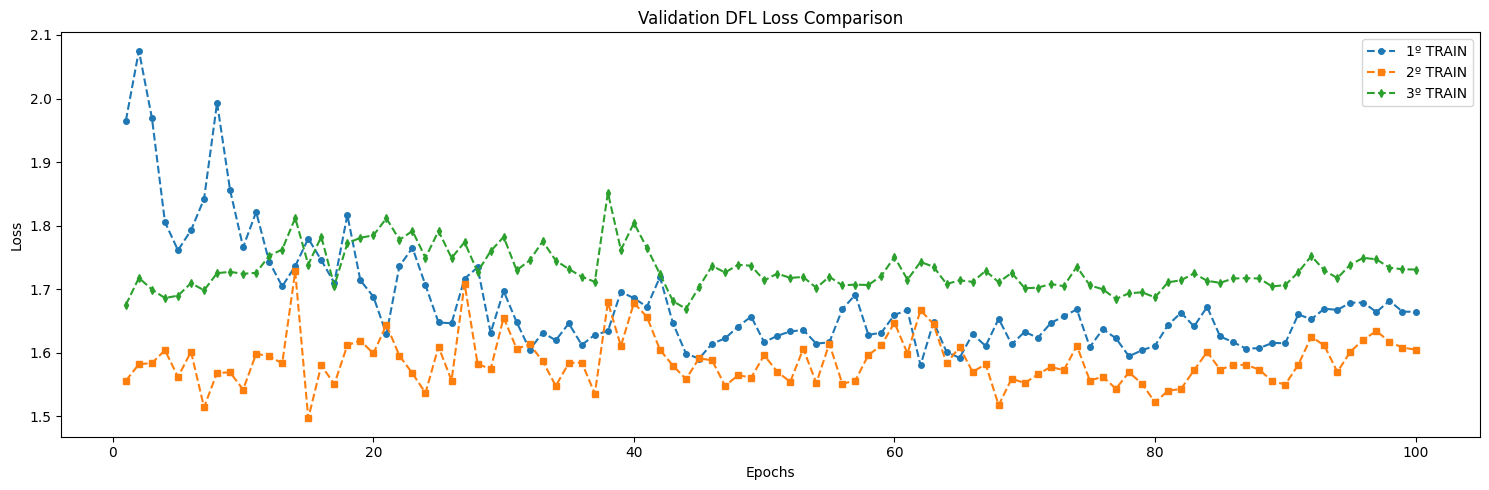

In [359]:
# Plot Training and Validation Losses
plot_metric("train/box_loss", "Loss", "Training Box Loss Comparison")
plot_metric("val/box_loss", "Loss", "Validation Box Loss Comparison")

plot_metric("train/cls_loss", "Loss", "Training Classification Loss Comparison")
plot_metric("val/cls_loss", "Loss", "Validation Classification Loss Comparison")

plot_metric("train/dfl_loss", "Loss", "Training DFL Loss Comparison")
plot_metric("val/dfl_loss", "Loss", "Validation DFL Loss Comparison")

### Performance Metrics

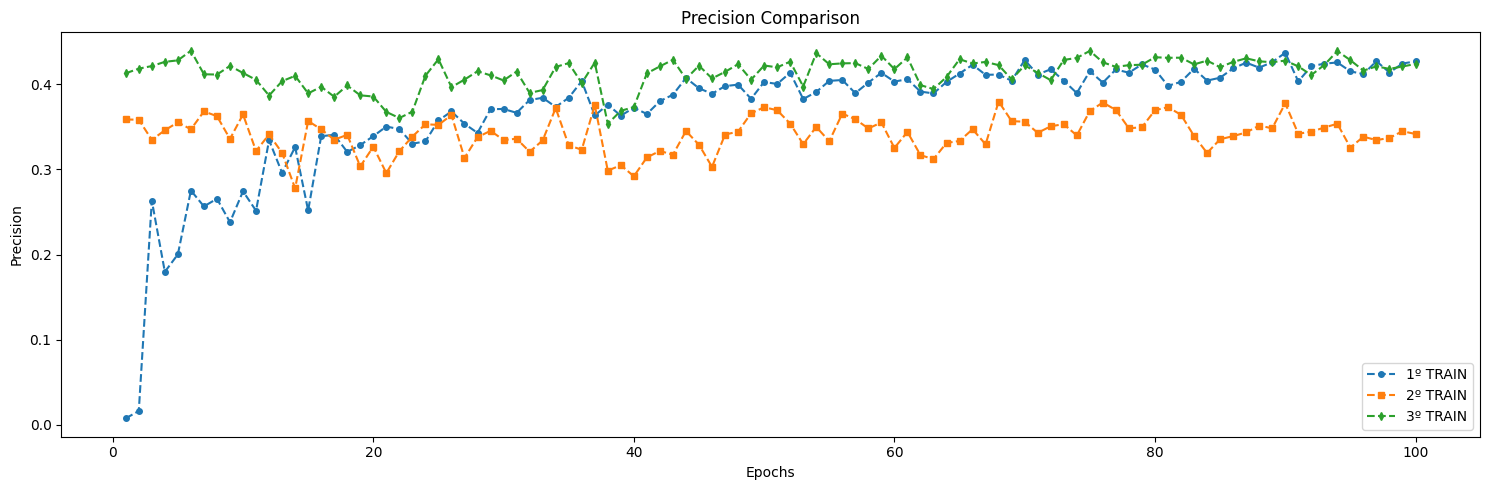

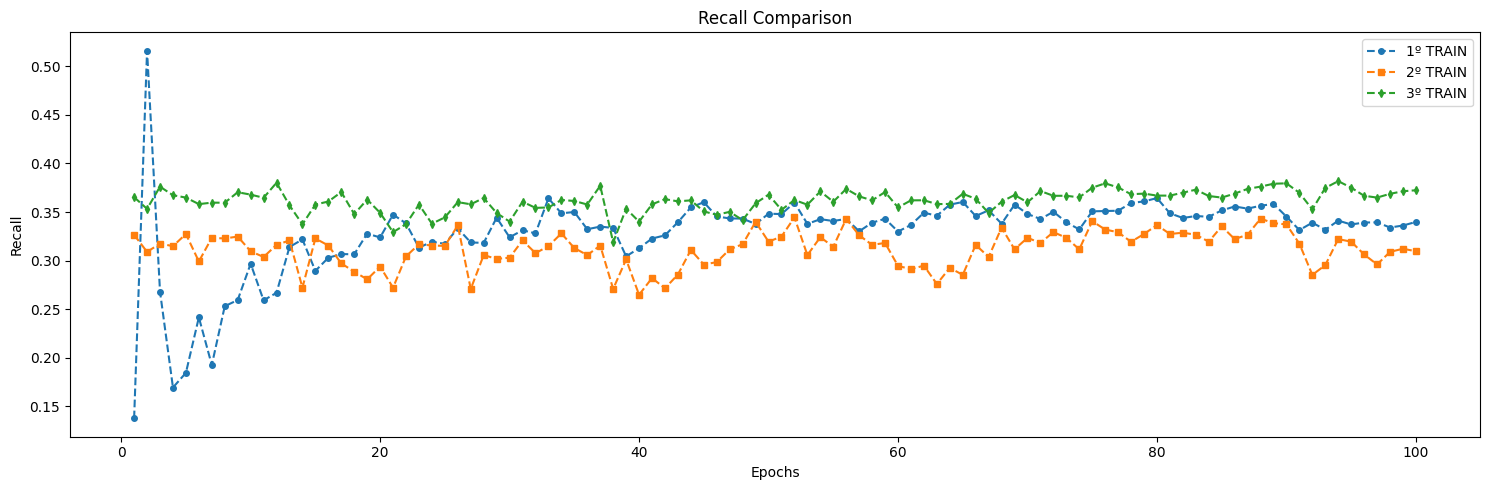

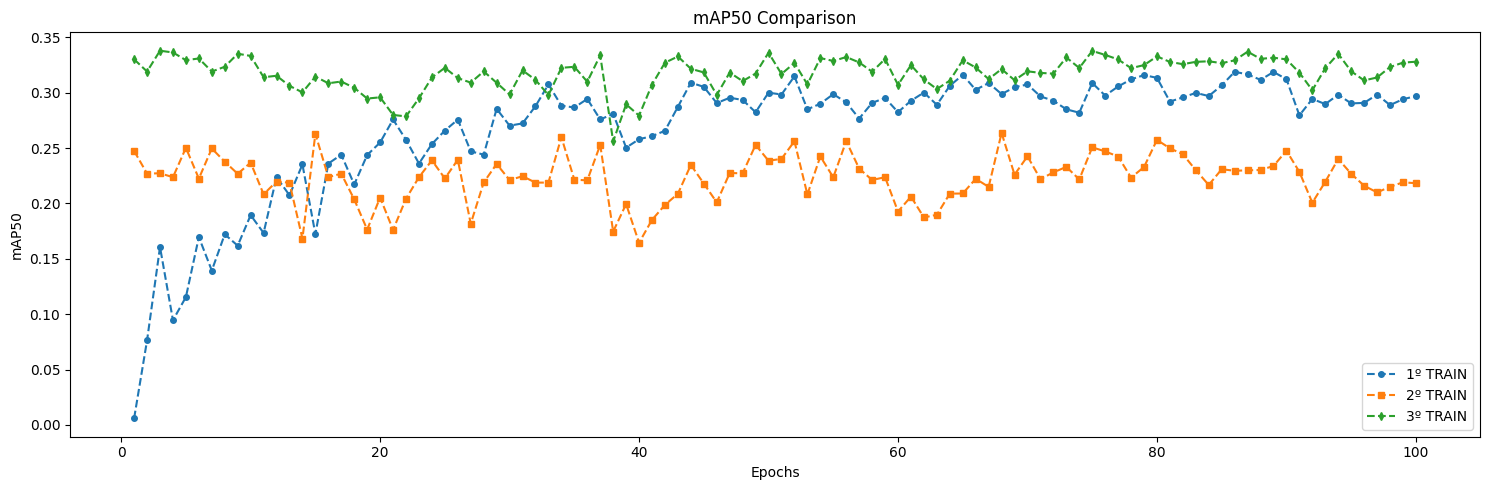

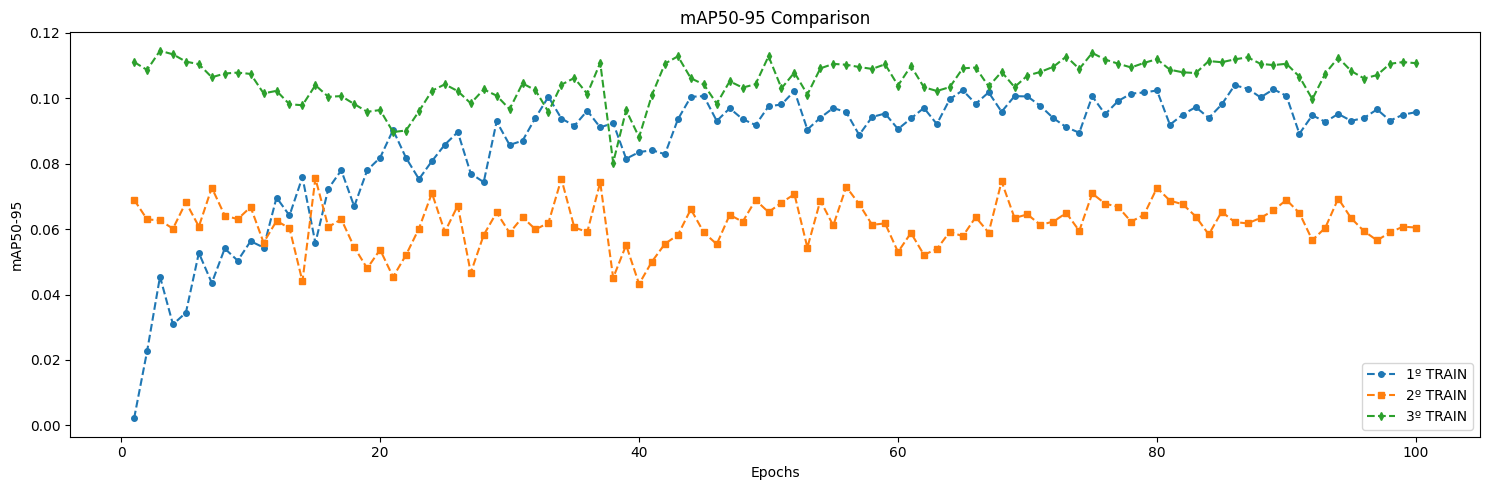

In [360]:
# Plot Performance Metrics
plot_metric("metrics/precision(B)", "Precision", "Precision Comparison")
plot_metric("metrics/recall(B)", "Recall", "Recall Comparison")
plot_metric("metrics/mAP50(B)", "mAP50", "mAP50 Comparison")
plot_metric("metrics/mAP50-95(B)", "mAP50-95", "mAP50-95 Comparison")

### Learning Rate

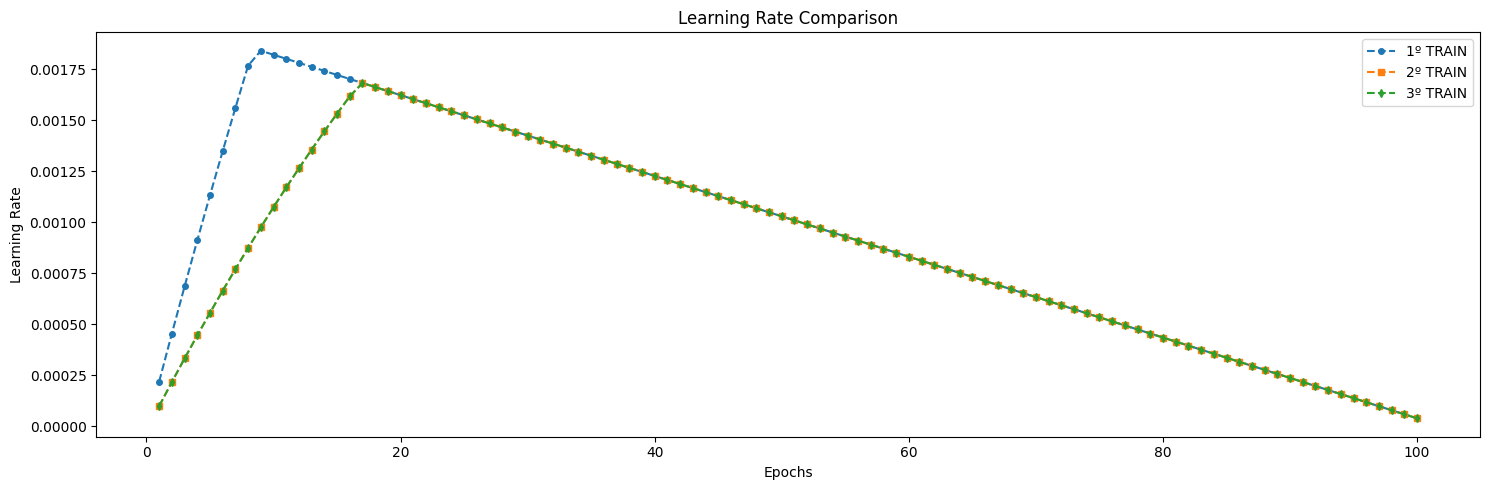

In [361]:
# Plot Learning Rate
plot_metric("lr/pg0", "Learning Rate", "Learning Rate Comparison")

## Resumen de los Experimentos

| Experiment | Dataset (Size) | Images | Tiles | Tags | Train/Valid (%) | Train Time (min) | Inf Time (ms) | Total detections | True Positives | False Positives | False Negatives | mAP@0.5 |
|------------|------|------|--------------|---------|------|------|----------------|---------------|---------------|---------------|---------------|--------|
| **1º TRAIN** | Small & Mid | 4 | 1472 | 8975 | 50% / 50% | *11,70* | ***1,39*** | 8557 | 27.4% | 24.9% | **47.7%** | ***0.297*** |
| **2º TRAIN** | Small | 2 | 736 | 3425 | 50% / 50% | *6,24* | ***1,43*** | 2633 | 24.2% | 27.0% | **48.8%** | ***0.218*** |
| **3º TRAIN** | Mid | 2 | 736 | 5550 | 50% / 50% | *6,33* | ***2,29*** | 5926 | 26.9% | 24.2% | **48.9%** | ***0.328*** |



## Comparación de los Entrenamientos

### Análisis del Dataset
- **Cantidad de imágenes y etiquetas**:
  - Entrenamiento 1: 1472 tiles, 8975 etiquetas (plant-weed).
  - Entrenamiento 2: 736 tiles, 3425 etiquetas (plant-weed).
  - Entrenamiento 3: 736 tiles, 5550 etiquetas (plant-weed).

- **Distribución de Train/Valid**:  
  - En los tres entrenamientos, la distribución fue de 50% para entrenamiento y 50% para validación.

- **Tamaño de imágenes (small vs mid)**:
  - Entrenamiento 1: Se utilizaron imágenes de tamaño small y mid.
  - Entrenamiento 2: Se utilizaron imágenes de tamaño small.
  - Entrenamiento 3: Se utilizaron imágenes de tamaño mid.

### Análisis de los Hiperparámetros
- **Modelo (yolov8n)**: Se mantuvo constante en todos los entrenamientos, lo que permite una comparación justa.  
- **Epochs (100)**: En los tres experimentos, el modelo parece alcanzar su rendimiento máximo antes de completar todas las épocas, lo que podría indicar que no se necesita entrenar tantas iteraciones.  
- **Batch Size (64)**: Se mantiene igual en todos los experimentos.  
- **Freeze (10)**: Congelar los primeros 10 capas del modelo en los tres entrenamientos podría estar limitando la capacidad de ajuste en las primeras etapas.  

### Análisis de Resultados
#### Métricas Generales
- **Precisión (Precision) y Recall**:
  - Los tres entrenamientos mostraron fluctuaciones significativas en precisión y recall. En general, el recall tendió a ser más alto que la precisión, lo que indica que el modelo detecta muchos objetos, pero con una alta tasa de falsos positivos.
  - El entrenamiento 3 tuvo el mayor mAP@0.5, pero con una diferencia muy leve con respecto al entrenamiento 1.

- **mAP50**:  
  - El mAP@0.5 varió entre los entrenamientos, con mejoras marginales en el entrenamiento 3 (0.338).
  - El entrenamiento 2 fue el mas variable.
  
- **Confusión entre clases (False Positives y False Negatives)**:  
  - Todos los entrenamientos mostraron un alto número de falsos negativos, lo que sugiere que el modelo tiene dificultades para detectar todos los objetos presentes en las imágenes.
  - La cantidad de Falsos positivos se mantiene muy alta en los 3 entrenamientos.
  
### Conclusiones Generales

1. Rendimiento Limitado del Modelo: A pesar de las variaciones en el dataset y los hiperparámetros, el modelo yolov8n (Nano) mostró un rendimiento limitado en todos los entrenamientos. La alta tasa de falsos negativos y la baja precisión indican que el modelo tiene dificultades para detectar y clasificar con precisión los objetos.

2. Necesidad de Ajuste de Hiperparámetros: La estabilidad del batch size y el número de epochs podría estar limitando el rendimiento del modelo. Se recomienda experimentar con diferentes valores y estrategias de ajuste.

3. Importancia de la Calidad del Dataset: La variación en el rendimiento entre los entrenamientos sugiere que la calidad y diversidad del dataset juegan un papel crucial. Se recomienda mejorar la diversidad del dataset y realizar un análisis detallado de los errores para identificar áreas de mejora.

4. Posible Overfitting: El entrenamiento 2 y 3 muestran signos de overfitting. Es recomendable implementar early stopping y otras técnicas de regularización.

5. El ratio tag/tile, parece tener influencia en el resultado final.

# Conclusión Final


## Estrategias para Próximos Entrenamientos
1. **Dataset**
- Diversificación: Ampliar variedad de imágenes (ángulos, luz, tamaños).
- Aumento de datos: Rotaciones, escalados, volteos, ajustes de color.
- Etiquetado: Detallado y consistente, revisión exhaustiva.
- Alta resolución: Mejorar detección de objetos pequeños.
- Ratio tag/tile: Analizar influencia y optimizar.

2. **Hiperparámetros**
- Batch size y epochs: Probar valores óptimos, early stopping, menos epochs.
- Regularización: Dropout, weight decay, batch normalization.
- Congelamiento de capas: Probar diferentes configuraciones.

3. **Optimización del Modelo**
- Selección de modelo: Explorar modelos más grandes o arquitecturas alternativas.
- Ajuste fino (fine-tuning): Usar modelos pre-entrenados.
- TTA (Test Time Augmentation): Mejorar precisión en inferencia.

4. **Evaluación y Métricas**
- Análisis de errores: Falsos positivos y negativos, patrones y mejoras.
- Validación cruzada: Estimación robusta del rendimiento.
- Métricas adicionales: F1-score, IoU, precisión por clase.
- Herramientas de visualización: TensorBoard para métricas en tiempo real.